# 📘 Cas d'usage — Certification "Concevoir et implémenter une solution d'IA"


Nom Prénom : EL OUARDI Mina <br>
Formation : Concevoir une solution IA <br> 
Date : 18/09/2026


## Introduction


**Nom du projet : TravelMind** - solution IA destinée à aider une agence de voyages haut de gamme à anticiper la satisfaction client avant le départ et à mieux cibler les séjours nécessitant une revue humaine.

Ce notebook centralise les étapes stabilisées du projet TravelMind :

1. **Partie 1 - Cadrage, besoins métier, cas d'usage et dataset** : problème métier, KPI, contraintes, pertinence de l'IA, datasheet, versioning et alternatives dataset.
2. **Partie 2 - Risques éthiques, sociétaux et registre RGPD** : risques, biais, AI Act, RGPD, contrôle humain et acteurs à informer.
3. **Partie 3 - Préparation des données, intégrité et pertinence** : construction du dataset enrichi, chargement, contrôles métier, nettoyage, valeurs manquantes, outliers, valeurs négatives et gouvernance des données.
4. **Partie 4 - Modélisation, choix, entraînement et validation** : feature engineering, segmentation client, comparaison 5 classes puis classification binaire, validation croisée, diagnostics, ROC AUC et matrice de confusion.
5. **Partie 5 - Choix du modèle IA** : justification du modèle retenu `LogisticRegression`, contraintes opérationnelles, éco-conception et alternatives techniques.
6. **Partie 6 - Entraînement supervisé du modèle IA** : hyperparamètres, pipeline, optimisation, résultats, limites et contrôle du surapprentissage.
7. **Partie 7 - Implémentation et intégration technique** : artefacts, API, interface web, Docker, monitoring, tests et CI/CD.
8. **Partie 8 - Évaluation de l'architecture cible** : architecture retenue, scénarios étudiés, contraintes et points de validation avant généralisation.
9. **Partie 9 - Mesure de performance et impacts de la solution IA** : Model Card, CodeCarbon, performances par sous-groupes, impacts et seuils.
10. **Partie 10 - Amélioration continue de la solution IA** : suivi, alertes, réentraînement contrôlé et amélioration du service.
11. **Partie 11 - Synthèse finale** : conclusion opérationnelle sur le modèle industrialisé, ses apports et ses limites.
12. **Partie 12 - Bonnes pratiques adoptées** : synthèse des pratiques projet appliquées.
13. **Partie 13 - Synthèse des ambitions métier** : niveau de couverture des ambitions initiales de l'agence.


## 0. Journal de bord du projet TravelMind

Ce journal de bord synthétise les principales décisions prises pendant le projet. Il permet de suivre l'avancement, la raison de chaque action, les preuves associées et la décision retenue pour le livrable final.

| Étape | Action réalisée | Objectif | Résultat obtenu | Preuve / suite |
| --- | --- | --- | --- | --- |
| Initialisation | Création de l'environnement Python `.venv`, du dépôt Git/GitHub et de la base Docker | Rendre le projet reproductible, versionné et portable | Structure projet en place avec dépendances, dépôt Git et conteneurisation | `requirements.txt`, `.gitignore`, `Dockerfile`, `docker-compose.yml` |
| Cadrage métier | Définition du besoin TravelMind, du cas d'usage principal et des limites d'usage | Clarifier le problème métier et vérifier que l'IA apporte une valeur | Objectif final : prédire une satisfaction binaire avant le départ pour aider le conseiller | KPI métier, cible binaire, supervision humaine |
| Dataset | Identification du fichier `Examen_travel_planning_dataset.csv` et vérification des droits d'usage | Vérifier la pertinence, la disponibilité et la cohérence du jeu de données | Dataset synthétique, anonymisé et utilisable dans le cadre de ce projet | `data/Examen_travel_planning_dataset.csv` |
| Datasheet et gouvernance | Documentation de la motivation, composition, usages, limites, distribution et maintenance du dataset | Répondre aux exigences de documentation du jeu de données | Datasheet structurée ajoutée au notebook | Section datasheet |
| Éthique, RGPD et AI Act | Analyse des risques, registre RGPD, rôles AI Act et obligation d'alphabétisation IA | Encadrer l'usage responsable de TravelMind | Risques, mesures, contrôle humain et acteurs à informer documentés | Section éthique et RGPD |
| Analyse métier du dataset brut | Contrôle de l'unicité, satisfaction, budget, prix vol, activités, imprévus et réorganisation | Identifier les cas incohérents ou explicables avant préparation | Incohérences critiques distinguées des observations métier conservables | Tableaux de contrôles |
| Préparation des données | Nettoyage, valeurs manquantes, outliers, valeurs négatives, doublons et formats | Renforcer l'intégrité des données avant modélisation | Traitements documentés et appliqués dans des pipelines | `ColumnTransformer`, `Pipeline`, `IQRMedianOutlierReplacer` |
| Enrichissement du dataset | Construction du dataset final à 3000 lignes avec variables métier additionnelles | Tester l'hypothèse qu'un dataset plus informatif améliore l'apprentissage | `dataset_final.csv` utilisé comme base unique du notebook final | `scripts/build_signal_enrichment_dataset.py`, `data/versions/v2_2_signal_enrichment/` |
| Versioning des données | Mise en place des versions `v1.0` à `v2.2-final` | Tracer les transformations du dataset et garantir la reproductibilité | Versions documentées, manifeste mis à jour et empreintes SHA-256 calculées | `data/versions/manifest.json`, `docs/data_versioning.md` |
| Modélisation | Comparaison entre cible 5 classes et classification binaire avec baseline | Choisir une formulation exploitable et mesurable | La classification binaire est retenue car plus lisible métier et plus performante | Sections modélisation et résultats |
| Modèle retenu | Sélection de `LogisticRegression` | Obtenir un modèle simple, explicable et industrialisable | `accuracy = 0.7167`, `balanced_accuracy = 0.7040`, `macro_f1 = 0.6893`, `ROC AUC = 0.7303` | Résultats de validation |
| NLP exploratoire | Analyse de `retour_client` avec tokenisation, lemmatisation, POS, NER et sentiment | Explorer l'apport qualitatif des avis clients après séjour | NLP utile pour l'amélioration continue, mais exclu du modèle servi par l'API | Section NLP exploratoire |
| Évaluation et transparence | Ajout matrice de confusion, recall, ROC AUC, validation croisée, Model Card, métriques éthiques et CodeCarbon | Documenter la performance, les limites et les impacts | Lecture métier des scores, biais potentiels et empreinte carbone documentés | Model Card, CodeCarbon |
| Industrialisation | Création de `train.py`, `app/`, API TravelMind, monitoring, logs et dashboard | Servir le modèle retenu hors notebook | API locale fonctionnelle avec `/health`, `/predict`, `/monitoring/*` et interface web | `train.py`, `app/main.py`, `app_web.py` |
| Monitoring et réentraînement | Journalisation JSONL, drift, alertes, dashboard KPI et stratégie de réentraînement | Suivre l'exploitation et déclencher des actions si le contexte change | Monitoring initial et seuils d'alerte disponibles | `app/monitoring.py`, `docs/strategie_reentrainement.md` |
| CI/CD et qualité gates | Ajout des tests automatisés et de GitHub Actions | Automatiser les contrôles avant livraison | Tests API/ML/monitoring, validation du notebook, quality gate et build Docker intégrés | `.github/workflows/ci-cd.yml`, `tests/`, `configs/model_quality_gate.json` |
| Architecture cible | Architecture retenue : notebook, pipeline, API locale, dashboard, Docker optionnel et CI/CD | Choisir une architecture proportionnée au prototype | Architecture cohérente pour démonstration et rattrapage, sans déploiement serveur automatique | Section architecture cible |


## Partie 1 - Cadrage, besoins métier, cas d'usage et dataset

Cette partie fixe le cadre du projet TravelMind avant toute préparation de données ou modélisation. Elle précise le problème métier, l'objectif IA retenu, les KPI, les contraintes et le rôle du dataset final.

### 1.1 Définition du problème métier

L'agence de voyages haut de gamme souhaite mieux personnaliser ses propositions de séjour et anticiper le niveau de satisfaction client. Le problème concret est d'identifier, avant le départ, les séjours présentant un risque de non-satisfaction afin d'aider le conseiller à ajuster la proposition : budget, destination, durée, hébergement, météo prévue ou activité principale.

Le projet distingue deux usages :

| Usage | Moment d'utilisation | Rôle dans le projet |
| --- | --- | --- |
| Prédiction avant départ | Avant le départ | Objectif principal industrialisé : prédire une satisfaction binaire à partir des informations disponibles avant le séjour. |
| Analyse qualité après séjour | Après le séjour | Usage exploratoire : comprendre l'apport des imprévus, du respect du budget, de la réorganisation et des retours clients, sans les utiliser dans le modèle déployé. |

### 1.2 Cas d'usage retenus

- **Aide à la décision avant départ** : signaler au conseiller les voyages potentiellement à risque avant validation finale.
- **Revue humaine ciblée** : prioriser les dossiers pour lesquels la probabilité de satisfaction est faible ou incertaine.
- **Analyse qualité après séjour** : exploiter les variables après séjour et les retours clients uniquement pour comprendre les causes et améliorer le service.
- **Amélioration continue** : suivre les prédictions, les dérives, les retours clients et les nouvelles données pour décider d'un éventuel réentraînement.

Les variables après séjour (`imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client`) sont exclues du modèle retenu afin d'éviter une fuite de données.

### 1.3 Indicateurs de succès du projet

| Type de KPI | Indicateur | Valeur / seuil dans le projet | Utilité |
| --- | --- | --- | --- |
| Métier | Taux de satisfaction client | `31.40 %` de séjours avec `satisfaction_client >= 4` dans `dataset_final` | Mesurer la part des séjours satisfaisants et suivre l'amélioration future du service. |
| Métier | Taux de non-satisfaction client | `68.60 %` de séjours avec `satisfaction_client <= 3` dans `dataset_final` | Identifier la proportion de séjours à surveiller et prioriser la revue humaine. |
| Technique | `macro_f1` | `0.6893` pour le modèle retenu | Mesurer la performance moyenne sur les deux classes sans favoriser la classe majoritaire. |
| Technique | `balanced_accuracy` | `0.7040` pour le modèle retenu | Vérifier que le modèle reste pertinent malgré un déséquilibre de classes. |
| Technique | `recall_satisfait` | `0.6702` pour le modèle retenu | Mesurer la capacité à détecter les séjours réellement satisfaisants. |
| Technique | `precision_satisfait` | `0.5385` pour le modèle retenu | Évaluer la fiabilité des prédictions positives `satisfait_4_5`. |
| Technique | `ROC AUC` | `0.7303` pour le modèle retenu | Évaluer la séparation probabiliste entre `non_satisfait_1_2_3` et `satisfait_4_5`. |
| Technique | Matrice de confusion | Binaire | Comprendre les erreurs entre `non_satisfait_1_2_3` et `satisfait_4_5`. |
| Technique | Validation croisée | Présente dans la partie modélisation | Vérifier la stabilité du modèle sur plusieurs découpages de données. |

### 1.4 Contraintes du projet

- **Données** : le dataset initial est synthétique, anonymisé et de taille modérée. Le notebook utilise ensuite `dataset_final`, une version enrichie et documentée à `3000` lignes et `24` colonnes.
- **Représentativité** : les données enrichies restent synthétiques ; elles permettent de démontrer la démarche mais ne remplacent pas une validation sur données réelles d'agence.
- **Signal disponible** : le dataset initial contenait peu de signal exploitable ; l'enrichissement métier vise à rendre la relation entre caractéristiques du voyage et satisfaction plus cohérente.
- **Fuite de données** : les variables connues après le séjour sont exclues du modèle retenu, même si elles restent utiles pour l'analyse qualité.
- **Éthique et conformité** : le modèle doit rester un outil d'aide à la décision, avec supervision humaine et sans décision automatique défavorable pour le client.
- **Industrialisation** : le prototype doit être reproductible avec Git, scripts d'entraînement, API, interface web, tests, monitoring local, Docker et CI/CD.
- **Déploiement** : le déploiement distant automatique n'est pas activé dans cette version ; il reste une étape future après validation métier, DSI, sécurité et conformité.

### 1.5 Pertinence de l'IA

Une solution simple de règles métier ou de dashboard suffit pour expliquer certaines situations évidentes, par exemple un budget très tendu ou un vol trop coûteux. L'IA devient pertinente pour tester si la combinaison de plusieurs variables permet d'anticiper la satisfaction client. Les résultats du dataset final montrent une performance exploitable pour un prototype encadré, mais pas suffisante pour automatiser une décision : le score doit rester un indicateur d'aide à l'analyse pour le conseiller.


### 1.6 Datasheet structurée du jeu de données

Cette sous-section formalise la datasheet du dataset utilisé dans le notebook final. Le fichier source fourni reste `data/Examen_travel_planning_dataset.csv`, puis le projet construit une version enrichie et versionnée : `data/versions/v2_2_signal_enrichment/dataset_final.csv`.

#### Motivation et contexte de collecte

Le dataset sert à simuler des séjours passés pour une agence de voyages haut de gamme. L'objectif est de disposer d'une base permettant d'étudier les facteurs associés à la satisfaction client et de tester un modèle d'aide à la décision avant départ. Les données sont synthétiques et anonymisées ; elles ne proviennent pas d'une collecte client réelle, mais représentent des situations plausibles de voyages avec budgets, destinations, contraintes, météo, activité principale, imprévus et retours clients.

#### Composition et statistiques descriptives

Le dataset final contient `3000` lignes et `24` colonnes. Chaque ligne représente un séjour. Les variables couvrent le profil client, le budget, la destination, la saison, la durée, l'hébergement, le prix du vol, la météo prévue, l'activité principale, la satisfaction client, des informations après séjour conservées pour analyse, ainsi que des variables enrichies construites pour renforcer le signal métier. Les statistiques descriptives sont vérifiées dans le notebook : valeurs manquantes, distribution de la cible, types de variables, valeurs uniques, doublons, incohérences métier, valeurs négatives et valeurs atypiques.

#### Variables principales

| Colonne | Type métier | Utilité pour le projet |
| --- | --- | --- |
| `trip_id` | Identifiant technique | Suivi de la ligne ; exclu des entrées du modèle car il ne porte pas de signal métier. |
| `client_type` | Catégorie client | Adapter l'analyse au profil voyageur : famille, couple, solo, business ou senior. |
| `budget_total` | Numérique | Représenter la contrainte budgétaire globale du séjour. |
| `destination` | Catégorie | Comparer les destinations et analyser leur lien avec la satisfaction. |
| `saison` | Catégorie | Tenir compte de la période du voyage et de son effet potentiel sur l'expérience. |
| `duree_jours` | Numérique | Mesurer l'impact de la durée du séjour sur le budget, la logistique et la satisfaction. |
| `type_hebergement` | Catégorie | Évaluer le rôle du type de logement dans l'expérience client. |
| `prix_vol` | Numérique | Mesurer le poids du transport dans le budget total du séjour. |
| `meteo_prevue` | Catégorie | Anticiper les risques liés à la météo avant le départ. |
| `activite_principale` | Catégorie | Relier le séjour aux centres d'intérêt ou au motif principal du client. |
| `satisfaction_client` | Numérique / cible | Variable cible, utilisée en 5 classes pour analyse puis regroupée en binaire : `non_satisfait_1_2_3` et `satisfait_4_5`. |
| `imprevus` | Catégorie après séjour | Variable d'analyse qualité après séjour ; exclue du modèle retenu pour éviter la fuite de données. |
| `reorganisation_necessaire` | Binaire après séjour | Indique si le séjour a nécessité une réorganisation ; utilisée en analyse après séjour, exclue du modèle retenu. |
| `respect_budget` | Binaire après séjour | Indique si le budget prévu a été respecté ; utile pour l'analyse après séjour, exclu du modèle retenu. |
| `retour_client` | Texte libre | Exploitable pour l'analyse NLP exploratoire ; non retenu dans le modèle principal car trop proche du ressenti final. |
| Variables enrichies | Numériques / catégorielles | Exemples : `reste_budget_apres_vol`, `budget_apres_vol_par_jour`, scores de cohérence et `niveau_risque_satisfaction`, ajoutés pour tester un dataset plus informatif. |

#### Usages recommandés

Le dataset est adapté à l'exploration de données, à l'analyse de cohérence métier, à la comparaison entre la cible 5 classes et la cible binaire, ainsi qu'à la construction d'un prototype de modèle IA avant départ. Pour le modèle retenu, seules les variables disponibles ou estimables avant le séjour doivent être utilisées. Les variables après séjour peuvent servir à l'analyse qualité, au NLP exploratoire et à l'amélioration continue, mais pas à la prédiction servie par l'API.

#### Limitations

Le dataset final reste synthétique : il démontre une démarche de préparation, d'enrichissement, de modélisation et d'industrialisation, mais il ne garantit pas une performance équivalente sur des données réelles. L'enrichissement améliore le signal métier, mais il doit être validé par le commanditaire avant toute généralisation. Les variables après séjour ne doivent pas être utilisées dans le modèle d'aide à la décision avant départ. Le modèle produit une probabilité indicative ; il ne doit pas remplacer le jugement du conseiller.


#### Distribution

La distribution des données est organisée autour de deux fichiers principaux :

| Fichier | Rôle | Statut de distribution |
| --- | --- | --- |
| `data/Examen_travel_planning_dataset.csv` | Dataset brut fourni dans l'énoncé | Conservé comme référence initiale du projet. |
| `data/versions/v2_2_signal_enrichment/dataset_final.csv` | Dataset final utilisé dans le notebook et la modélisation | Version retenue pour la livraison du projet. |

Le dataset final contient `3000` lignes et `24` colonnes. Il est synthétique, anonymisé et dérivé du dataset fourni. Il peut donc être versionné dans GitHub avec le code, les notebooks et la documentation dans le cadre de ce projet.

La distribution est limitée au périmètre projet :

- stockage local dans le dossier `data/` ;
- versioning dans `data/versions/` ;
- traçabilité dans `data/versions/manifest.json` avec empreintes SHA-256 ;
- documentation dans `docs/data_versioning.md` et dans cette datasheet ;
- régénération possible via les scripts `scripts/version_data.py`, `scripts/enrich_dataset.py` et `scripts/build_signal_enrichment_dataset.py`.

Le projet met en place le cycle de versions suivant :

| Version | Emplacement | Contenu | Usage |
| --- | --- | --- | --- |
| `v1.0` | `data/versions/v1_0_raw/` | Dataset brut fourni | Référence initiale, sans transformation |
| `v1.1` | `data/versions/v1_1_cleaning/` | Nettoyage des colonnes, espaces et formats | Base propre pour les contrôles qualité |
| `v1.2` | `data/versions/v1_2_incoherences/` | Suppression des incohérences critiques | Base cohérente avant modélisation |
| `v2.0` | `data/versions/v2_0_feature_engineering/` | Ajout de variables dérivées | Base enrichie pour expérimentation |
| `v2.1` | `data/versions/v2_1_enrichment/` | Enrichissement externe optionnel | Données météo, tarifaires ou contextuelles documentées |
| `v2.2` | `data/versions/v2_2_signal_enrichment/` | Enrichissement signal métier et augmentation synthétique contrôlée | Dataset expérimental plus informatif |
| `v2.2-final` | `data/versions/v2_2_signal_enrichment/dataset_final.csv` | Dataset final retenu | Base utilisée par le notebook final et le modèle retenu |

Cette distribution ne correspond pas à une mise à disposition publique de données clients. Si des données réelles étaient ajoutées ultérieurement, elles ne devraient pas être publiées dans GitHub sans validation préalable : analyse RGPD, anonymisation ou pseudonymisation, politique d'accès, durée de conservation, validation DPO/juridique et accord du commanditaire.

#### Maintenance

Toute modification du dataset doit être documentée : ajout de colonnes, correction d'incohérences, enrichissement externe, suppression de lignes ou changement de cible. Les traitements appliqués doivent rester reproductibles dans le notebook ou dans les scripts associés. En cas d'évolution du jeu de données, il faudra mettre à jour les statistiques descriptives, les contrôles de cohérence, la liste des variables autorisées, les résultats de modélisation, le manifeste et la Model Card.

### 1.7 Solutions alternatives en cas d'indisponibilité des données

Si le fichier `data/Examen_travel_planning_dataset.csv` ou `dataset_final.csv` devenait indisponible, incomplet ou inexploitable, les alternatives suivantes seraient à envisager avant de relancer la modélisation :

- utiliser une copie versionnée du dataset dans `data/versions/` si elle est disponible ;
- demander au commanditaire une nouvelle extraction synthétique ou anonymisée ;
- constituer un dataset minimal à partir de séjours historiques réels après validation RGPD, anonymisation et accord métier ;
- enrichir progressivement le dataset avec des sources externes validées : météo, distances, catégories de destinations ou données tarifaires ;
- limiter temporairement le projet à une analyse descriptive si les données nécessaires au modèle ne sont pas disponibles.


## Partie 2 - Risques éthiques, sociétaux et registre RGPD

Dans ce notebook, le traitement porte sur le dataset enrichi `dataset_final`, dérivé du fichier brut `data/Examen_travel_planning_dataset.csv`. Ce fichier est un dataset synthétique et anonymisé. Il ne contient pas de nom, prénom, email, téléphone, adresse, numéro de passeport ou identifiant client réel. Le registre ci-dessous documente donc le traitement réalisé dans ce projet, et non un traitement opérationnel de données clients réelles.

#### Finalités du traitement

| Finalité | Description |
| --- | --- |
| Documentation du dataset | Décrire le jeu de données utilisé pour répondre au besoin métier de planification de voyages. |
| Analyse de cohérence métier | Vérifier la qualité du fichier : valeurs manquantes, incohérences, doublons, valeurs atypiques. |
| Modélisation du modèle retenu | Tester la capacité des variables disponibles avant le séjour à expliquer la satisfaction client. |

#### Catégories de données collectées

| Catégorie | Colonnes concernées | Statut dans ce projet |
| --- | --- | --- |
| Identifiant technique | `trip_id` | Identifiant synthétique de ligne, non rattaché à une personne réelle. |
| Profil voyageur simulé | `client_type` | Catégorie générique : famille, couple, solo, business, senior. |
| Caractéristiques du séjour | `destination`, `saison`, `duree_jours`, `type_hebergement`, `activite_principale`, `meteo_prevue` | Variables descriptives du voyage fictif. |
| Données budgétaires simulées | `budget_total`, `prix_vol` | Montants fictifs utilisés pour l'analyse et la modélisation. |
| Événements après séjour simulés | `imprevus`, `reorganisation_necessaire`, `respect_budget` | Variables opérationnelles fictives connues après ou pendant le séjour. |
| Satisfaction et avis fictifs | `satisfaction_client`, `retour_client` | Score et commentaire synthétiques, sans auteur identifiable. |

Aucune donnée personnelle directement identifiable n'est traitée dans le périmètre actuel du notebook.

#### Durée de conservation

| Élément conservé | Durée retenue pour ce projet |
| --- | --- |
| Dataset brut synthétique | Conservé dans `data/` pendant la durée du projet. |
| Notebooks d'analyse | Conservés dans `notebooks/` pour assurer la traçabilité des choix et des résultats. |
| Documentation projet | Conservée dans `docs/` et dans le notebook pour justifier la démarche. |

Comme le dataset est synthétique, il n'y a pas de durée de conservation liée à des personnes concernées identifiables dans ce projet.


### 2.1 Analyse des risques éthiques et sociétaux

Cette section synthétise les risques éthiques, sociétaux, juridiques et environnementaux propres à TravelMind. Le détail de conformité AI Act est traité une seule fois dans la section 2.2.

#### Positionnement éthique du projet

| Point de cadrage | Position retenue |
| --- | --- |
| Nature de la solution | Outil d'aide à l'analyse et à la recommandation, pas une décision automatique |
| Domaine | Planification de voyages haut de gamme et anticipation de la satisfaction client |
| Données | Dataset synthétique et anonymisé, sans données personnelles réelles |
| Sortie du modèle | Prédiction probabiliste binaire : `non_satisfait_1_2_3` ou `satisfait_4_5` |
| Usage autorisé | Aide à la personnalisation, priorisation des contrôles humains, analyse qualité |

#### Risques identifiés et mesures retenues

| Risque | Conséquence possible | Mesure appliquée dans le projet |
| --- | --- | --- |
| Surinterprétation du score | Le client ou le conseiller peut croire que la prédiction est certaine | Affichage des probabilités, du niveau de confiance, des limites du modèle et maintien d'une supervision humaine |
| Performance insuffisante pour décision automatique | Le modèle peut être utilisé au-delà de sa fiabilité réelle | Positionnement explicite comme prototype d'aide à la revue humaine ; pas de mise en production autonome en l'état |
| Faux positifs sur la classe `satisfait` | Un séjour peut être annoncé satisfaisant alors qu'il ne l'est pas réellement | Lecture de la matrice de confusion, suivi de `precision_satisfait = 0.5385`, revue humaine obligatoire |
| Faux négatifs sur la classe `satisfait` | Un séjour satisfaisant peut ne pas être identifié comme tel | Suivi de `recall_satisfait = 0.6702`, analyse des erreurs et maintien d'une décision finale par le conseiller |
| Fuite de données | Utiliser des informations après séjour pour prédire avant départ fausserait les performances | Séparation stricte avant départ / après séjour et exclusion de `imprevus`, `respect_budget`, `reorganisation_necessaire` et `retour_client` du modèle retenu |
| Automatisation excessive | Le score pourrait déclencher une décision commerciale sans validation humaine | Usage interdit pour refus automatique, tarification individualisée injustifiée ou remplacement du conseiller |
| Dataset synthétique enrichi | Les résultats peuvent être meilleurs que sur des données réelles et ne pas refléter le comportement client réel | Documentation du caractère synthétique, validation métier requise, réévaluation sur données réelles avant généralisation |
| Biais par profil, budget ou destination | Certains segments peuvent être moins bien servis ou moins bien prédits | Analyse par sous-groupes, suivi des écarts, interdiction d'utiliser le score pour défavoriser automatiquement un client |
| Données personnelles futures | L'ajout de données clients réelles pourrait créer des risques RGPD | Registre de traitement, minimisation, anonymisation/pseudonymisation, politique d'accès et validation DPO/juridique avant diffusion |
| Manque d'alphabétisation IA | Les utilisateurs internes peuvent mal interpréter les sorties du modèle | Formation courte, guide utilisateur, consignes d'usage, sensibilisation aux biais et procédure de revue humaine |
| Dérive des données en exploitation | Les profils de voyages saisis peuvent s'éloigner du dataset d'entraînement | Monitoring `/monitoring/drift`, alertes, journalisation JSONL et stratégie de réentraînement |
| Impact environnemental | Entraînements lourds, NLP avancé ou optimisations massives peuvent augmenter l'empreinte carbone | Modèles tabulaires sobres, CodeCarbon, NLP non retenu dans le modèle industrialisé et expériences lourdes isolées |

#### Biais potentiels à surveiller

| Axe de biais | Pourquoi le surveiller | Contrôle prévu dans TravelMind |
| --- | --- | --- |
| Budget, prix du vol et hébergement | Ces variables peuvent agir comme proxys socio-économiques et influencer la priorisation des dossiers | Analyse des erreurs par tranches de budget, contrôle des performances par sous-groupe, interdiction d'utiliser le score pour exclure ou défavoriser un client |
| Profil client (`client_type`) | Certains profils peuvent être mieux représentés ou mieux prédits que d'autres | Mesure des performances par `client_type`, suivi des segments faibles et revue humaine obligatoire |
| Destination, saison, météo et activité | Certaines destinations ou périodes peuvent dominer le dataset et réduire la qualité sur les cas rares | Contrôle de distribution, suivi de dérive via `/monitoring/drift`, comparaison des performances par destination, saison et activité si le volume est suffisant |
| Déséquilibre de la cible | La classe `non_satisfait_1_2_3` représente environ `68.6 %` du dataset final, ce qui peut favoriser la classe majoritaire | Split stratifié, baseline `DummyClassifier`, `balanced_accuracy`, `macro_f1`, matrice de confusion, `precision_satisfait` et `recall_satisfait` |
| Faux positifs sur `satisfait` | Une prédiction positive peu fiable peut conduire à sous-estimer un risque d'insatisfaction | Suivi de `precision_satisfait = 0.5385`, affichage des probabilités, seuil de faible confiance et revue humaine |
| Données synthétiques enrichies | Le dataset final peut ne pas représenter toute la diversité de clients réels d'une agence haut de gamme | Documentation des limites, validation métier avant production, test sur données réelles anonymisées si disponibles |
| Texte libre `retour_client` | Le sentiment exprimé est connu après le séjour et peut créer une fuite de signal | NLP conservé comme exploration qualitative après séjour, non retenu dans le modèle industrialisé |
| Dérive en exploitation | Les voyages saisis dans l'API peuvent évoluer par rapport au jeu d'entraînement | Logs JSONL, dashboard KPI, alertes de dérive, seuils de monitoring et stratégie de réentraînement |

#### Acteurs à informer

| Acteur | Information à transmettre | Action attendue |
| --- | --- | --- |
| Commanditaire / direction métier | Objectif du modèle, performance modérée du modèle retenu, limites du dataset synthétique et usage non automatique | Valider le positionnement comme aide à la décision, pas comme outil de décision automatique |
| Conseillers voyage | Interprétation des probabilités, niveau de confiance, limites du modèle, cas nécessitant une revue humaine | Utiliser TravelMind comme support de conseil et garder la responsabilité de la recommandation finale |
| Clients finaux | Information claire qu'une IA peut assister la personnalisation du séjour et que la proposition peut être revue par un conseiller | Garantir transparence, compréhension et possibilité d'explication humaine |
| Référent juridique / RGPD / DPO | Nature synthétique du dataset actuel, conditions d'ajout de données réelles, registre de traitement, durée de conservation et droits des personnes | Valider le cadre légal avant toute utilisation de données clients réelles ou diffusion externe |
| Équipe data / technique | Variables autorisées, variables exclues, pipeline sans fuite, monitoring, dérive, quality gate et réentraînement | Maintenir le modèle, contrôler les performances et documenter chaque évolution |
| DSI / sécurité | Architecture locale, API, logs, Docker, accès aux données et conditions d'exposition éventuelle hors poste local | Définir les règles d'hébergement, d'accès, de sauvegarde et de sécurité avant production |


### 2.2 Conformité à la loi européenne sur l'IA (AI Act)

Cette section documente les réponses au questionnaire AI Act pour TravelMind, en tenant compté d'un usage destiné aux clients finaux de l'agence de voyage. 

#### Références réglementaires utilisées

Sources officielles : https://artificialintelligenceact.eu/fr/evaluation/verificateur-de-conformite-a-l-acte-de-l-ai-de-l-ue/

#### Positionnement AI Act retenu

Le tableau ci-dessous reprend les 9 questions du questionnaire AI Act applicables au positionnement de TravelMind. Les réponses sont documentées pour le cas du projet : solution de recommandation et d'anticipation de satisfaction pour une agence de voyages, destinée à des utilisateurs finaux, sans décision automatique.

| Elément du questionnaire | Réponse | Justification pour TravelMind |
| --- | --- | --- |
| Type d'entité | Fournisseur/ déployeur | Le projet développe le modèle, l'API et le dashboard. |
| Modification par un acteur aval | Aucune de ces réponses | Aucun déployeur, distributeur ou importateur aval n'a changé la marque, la finalité ou le fonctionnement substantiel du système. |
| Catégories haut risque produits | Aucune | TravelMind n'est pas un composant de sûreté pour aviation civile, véhicules, systèmes ferroviaires, équipements marins ou véhicules agricoles. |
| Systèmes interdits | Aucune | TravelMind ne manipule pas les personnes, n'exploite pas leurs vulnérabilités, ne fait pas de biométrie, notation sociale, police prédictive, reconnaissance faciale ou reconnaissance des émotions. |
| Systèmes transparents | Aucune dans le cadre actuel | TravelMind ne génère pas de contenu synthétique audio, image, vidéo ou texte publié pour informer le public ; ne fait pas de reconnaissance des émotions, de catégorisation biométrique ou de deepfake. |
| Classement haut risque global | non haut risque dans le cadre actuel | Le cas d'usage concerne la personnalisation de voyages et l'aide à l'anticipation de satisfaction. Il ne conditionne pas l'accès à un service essentiel, à l'emploi, au crédit, à l'éducation, à la justice ou à un service public. À réévaluer si la finalité change. |
| Champ d'application | Je suis établi ou situé dans l'UE ; les résultats de mon système d'IA sont utilisés dans l'UE | Le projet est conçu pour une agence de voyage opérant dans l'UE et les recommandations TravelMind sont destinées à des clients ou conseillers situés dans l'UE. |
| Systèmes exclus | Aucune | TravelMind n'est pas développé exclusivement à des fins militaires, n'est pas utilisé par des autorités de pays tiers pour l'application de la loi, n'est pas une simple activité de R&D isolée, n'est pas un composant libre indépendant et n'est pas un usage personnel non professionnel. |

#### Résultat : Obligation d'alphabétisation IA

Voici la démarche d'alphabétisation IA prévue pour TravelMind :

| Mesure | Application pour TravelMind |
| --- | --- |
| Formation courte | Sensibilisation pour conseillers, métier, technique et monitoring |
| Guide utilisateur | Explication des entrées, sorties, classes, probabilités, niveau de confiance et limites |
| Règles d'usage | Interdiction d'utilisér TravelMind seul pour refuser une offre ou remplacer le conseiller |
| Supervision humaine | Le conseiller peut valider, corriger ou ignorer la recommandation |
| Gestion des alertes | Faible confiance, derive ou résultat incoherent = revue humaine obligatoire |
| Mise à jour périodique | Nouvelle sensibilisation après changement majeur du modèle, des données ou du cas d'usage |

#### Conclusion

TravelMind peut être utilisé comme support d'analyse et de personnalisation à condition de conserver une supervision humaine, de présenter les prédictions comme probabilistes, de surveiller les biais, d'informer les acteurs concernés et de ne pas utiliser le score pour prendre une décision automatique individuelle.


## Partie 3 - Préparation des données, intégrité et pertinence

**Finalité** : transformer le dataset brut en `dataset_final`, une base exploitable, cohérente avec le besoin métier et prête pour la modélisation.

### 3.1 Stratégie de préparation de données

Cette partie suit une démarche volontairement simple : identifier les problèmes de données, appliquer uniquement les traitements utiles au cas d'usage, puis documenter leur raison métier.


| Besoin ou problème identifié | Traitement retenu | Justification métier |
| --- | --- | --- |
| Dataset brut synthétique peu informatif | Construction de `dataset_final` enrichi | Disposer d'une base plus riche pour tester la prédiction de satisfaction |
| Libellés et formats hétérogènes | Harmonisation des textes, accents, casse et catégories | Éviter qu'une même valeur soit interprétée comme plusieurs modalités |
| Données incohérentes ou bloquantes | Contrôles qualité, valeurs négatives, doublons, cible invalide, incohérences budgétaires | Ne pas entraîner le modèle sur des séjours impossibles ou contradictoires |
| Variables trop brutes pour le besoin métier | Feature engineering budget, vol, météo, contexte et potentiel de satisfaction | Traduire les données en signaux plus proches du raisonnement d'une agence de voyage |
| Données à tracer dans le temps | Stockage versionné et `manifest.json` | Garantir la reproductibilité et faciliter la revue par les parties prenantes |

Les traitements qui apprennent des paramètres sur les données, comme l'imputation, l'encodage ou la standardisation, sont volontairement réalisés plus loin dans le pipeline de modélisation afin d'éviter toute fuite d'information entre train et test.

### 3.2 Imports et configuration



In [2]:
import os
import json
import sys
import math
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import mlflow
import mlflow.sklearn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from xgboost import XGBClassifier

# Imports optionnels : ils restent centralisés ici pour garder le notebook lisible.
# Les cellules concernées gèrent l'indisponibilité éventuelle de ces dépendances.
try:
    import spacy
except ImportError:
    spacy = None

try:
    from transformers import pipeline as transformers_pipeline
except ImportError:
    transformers_pipeline = None

try:
    from codecarbon import OfflineEmissionsTracker
except ImportError:
    OfflineEmissionsTracker = None

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
MLFLOW_TRACKING_URI = f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("travelmind_satisfaction")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

RANDOM_STATE = 42
TARGET_COLUMN = "satisfaction_client"

# Dataset de reference utilise dans tout ce notebook final.
V22_DIR = PROJECT_ROOT / "data" / "versions" / "v2_2_signal_enrichment"
DATASET_FINAL_PATH = V22_DIR / "dataset_final.csv"
DATA_PATH = DATASET_FINAL_PATH

c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI: sqlite:///c:/Users/khadi/Downloads/Examen_IA/mlflow.db


### 3.3 Construction et chargement du dataset final `dataset_final`

Cette partie construit puis charge le fichier `dataset_final.csv`, utilisé comme dataset unique pour la suite du notebook.



#### 3.3.1 Enrichissement et génération du dataset final

Le dataset initial était exploitable pour un prototype, mais il contenait peu de signal métier directement utilisable pour prédire la satisfaction avant le voyage. Les premières expérimentations montraient que les variables brutes (`budget_total`, `prix_vol`, `duree_jours`, `destination`, `saison`, etc.) expliquaient faiblement la satisfaction finale. L'enrichissement sert donc à construire un dataset plus cohérent avec le besoin métier : anticiper la satisfaction ou le risque d'insatisfaction avant le départ.

L'enrichissement appliqué dans le notebook repose sur quatre opérations principales :

- **Correction et normalisation** : correction des problèmes d'encodage, harmonisation des textes et contrôle des formats.
- **Augmentation contrôlée du volume** : passage à `3000` lignes par duplication contrôlée de séjours existants, avec de petites perturbations réalistes sur le budget, le prix du vol et la durée.
- **Ajout de variables métier explicatives** : création de scores liés au budget disponible après vol, à la cohérence du prix du vol, à l'adéquation activité/profil, à la météo prévue et au contexte destination.
- **Construction d'un signal avant départ** : calcul d'un `score_potentiel_satisfaction`, puis d'un `niveau_risque_satisfaction`, afin de rendre la cible plus cohérente avec les informations disponibles avant le séjour.

La génération reste déterministe grâce à `RANDOM_STATE`, ce qui permet de reproduire exactement le dataset final.

In [3]:
from datetime import datetime, timezone
from typing import Any

SOURCE_DATASET = PROJECT_ROOT / "data" / "versions" / "v2_1_enrichment" / "travel_planning_dataset_v2_1.csv"
FALLBACK_DATASET = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "versions" / "v2_2_signal_enrichment"
OUTPUT_DATASET_FINAL = DATASET_FINAL_PATH
OUTPUT_REPORT = OUTPUT_DIR / "signal_enrichment_report.json"
TARGET_ROWS_V22 = 3000
BROKEN_ACCENT = chr(65533)

DESTINATION_REFERENCE = {
    "paris": {"budget": 4200, "vol": 350, "complexite": 0.20},
    "rome": {"budget": 3900, "vol": 450, "complexite": 0.25},
    "lisbonne": {"budget": 3400, "vol": 380, "complexite": 0.20},
    "bali": {"budget": 6200, "vol": 1150, "complexite": 0.75},
    "new york": {"budget": 6500, "vol": 850, "complexite": 0.55},
    "tokyo": {"budget": 7200, "vol": 1050, "complexite": 0.80},
    "sydney": {"budget": 8000, "vol": 1300, "complexite": 0.95},
    "dubaï": {"budget": 6100, "vol": 700, "complexite": 0.45},
}

ACTIVITIES_BY_CLIENT = {
    "famille": {"plage", "culture", "gastronomie"},
    "couple": {"culture", "gastronomie", "plage"},
    "solo": {"randonnée", "culture"},
    "business": {"business"},
    "senior": {"culture", "gastronomie"},
}

HEBERGEMENTS_BY_CLIENT = {
    "famille": {"resort", "appartement", "villa"},
    "couple": {"hôtel", "resort", "villa"},
    "solo": {"appartement", "hôtel"},
    "business": {"hôtel"},
    "senior": {"hôtel", "appartement"},
}

METEO_SCORE = {
    "ensoleillé": 1.00,
    "nuageux": 0.70,
    "variable": 0.45,
    "pluie": 0.25,
}

DATASET_FINAL_COLUMNS = [
    "trip_id", "client_type", "budget_total", "destination", "saison", "duree_jours",
    "type_hebergement", "prix_vol", "meteo_prevue", "activite_principale",
    "satisfaction_client", "imprevus", "reorganisation_necessaire", "respect_budget",
    "retour_client", "reste_budget_apres_vol", "budget_apres_vol_par_jour",
    "score_budget_destination", "score_prix_vol_coherent", "score_adequation_activite_profil",
    "score_meteo_prevue", "score_contexte_destination", "score_potentiel_satisfaction",
    "niveau_risque_satisfaction",
]


def relative_to_project(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def numeric_series(df: pd.DataFrame, column: str, default: float = np.nan) -> pd.Series:
    if column in df.columns:
        return pd.to_numeric(df[column], errors="coerce")
    return pd.Series(default, index=df.index, dtype="float64")


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    ratio = pd.to_numeric(numerator, errors="coerce") / pd.to_numeric(denominator, errors="coerce")
    return ratio.replace([np.inf, -np.inf], np.nan)


def normalize_0_1(values: pd.Series, lower: float, upper: float, inverse: bool = False) -> pd.Series:
    normalized = ((pd.to_numeric(values, errors="coerce") - lower) / (upper - lower)).clip(0, 1)
    if inverse:
        normalized = 1 - normalized
    return normalized.fillna(0.5)


ENCODING_CORRECTIONS = {
    "Duba" + BROKEN_ACCENT: "Dubaï",
    "duba" + BROKEN_ACCENT: "dubaï",
    "h" + BROKEN_ACCENT + "tel": "hôtel",
    "H" + BROKEN_ACCENT + "tel": "Hôtel",
    "ensoleill" + BROKEN_ACCENT: "ensoleillé",
    "randonn" + BROKEN_ACCENT + "e": "randonnée",
    "m" + BROKEN_ACCENT + "t" + BROKEN_ACCENT + "o": "météo",
    "s" + BROKEN_ACCENT + "jour": "séjour",
    "S" + BROKEN_ACCENT + "jour": "Séjour",
    "s" + BROKEN_ACCENT + "jour d" + BROKEN_ACCENT + "cevant": "séjour décevant",
    "tr" + BROKEN_ACCENT + "s": "très",
    "exp" + BROKEN_ACCENT + "rience": "expérience",
    "qualit" + BROKEN_ACCENT: "qualité",
    "D" + BROKEN_ACCENT + BROKEN_ACCENT + "u": "Déçu",
    "probl" + BROKEN_ACCENT + "mes": "problèmes",
    "impr" + BROKEN_ACCENT + "vus": "imprévus",
    BROKEN_ACCENT + " " + BROKEN_ACCENT + "viter": "à éviter",
}


def corriger_encodage_texte(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()
    text_columns = df.select_dtypes(include=["object", "string"]).columns
    for column in text_columns:
        serie = df[column].astype("string")
        for valeur_erronee, valeur_corrigee in ENCODING_CORRECTIONS.items():
            serie = serie.str.replace(valeur_erronee, valeur_corrigee, regex=False)
        df[column] = serie
    return df


def augment_dataset_to_target_rows(df_source: pd.DataFrame, target_rows: int = TARGET_ROWS_V22) -> tuple[pd.DataFrame, pd.Series, dict[str, Any]]:
    if len(df_source) >= target_rows:
        synthetic_mask = pd.Series(False, index=df_source.index)
        return df_source.copy(), synthetic_mask, {"synthetic_rows_added": 0, "target_rows": target_rows}

    rng = np.random.default_rng(RANDOM_STATE)
    rows_to_add = target_rows - len(df_source)
    synthetic_rows = df_source.sample(n=rows_to_add, replace=True, random_state=RANDOM_STATE).copy().reset_index(drop=True)

    max_trip_id = pd.to_numeric(df_source.get("trip_id", pd.Series(dtype="float64")), errors="coerce").max()
    if pd.isna(max_trip_id):
        max_trip_id = len(df_source)
    synthetic_rows["trip_id"] = np.arange(int(max_trip_id) + 1, int(max_trip_id) + rows_to_add + 1)

    synthetic_rows["budget_total"] = (
        pd.to_numeric(synthetic_rows["budget_total"], errors="coerce") * rng.normal(1.0, 0.16, rows_to_add)
    ).clip(500, 50000).round(2)
    synthetic_rows["prix_vol"] = (
        pd.to_numeric(synthetic_rows["prix_vol"], errors="coerce") * rng.normal(1.0, 0.18, rows_to_add)
    ).clip(0, 15000).round(2)
    synthetic_rows["prix_vol"] = np.minimum(synthetic_rows["prix_vol"], (synthetic_rows["budget_total"] * 0.90).round(2))
    synthetic_rows["duree_jours"] = (
        pd.to_numeric(synthetic_rows["duree_jours"], errors="coerce").fillna(7).astype(int)
        + rng.integers(-3, 4, rows_to_add)
    ).clip(1, 90)

    replacements = {
        "type_hebergement": ["hôtel", "resort", "appartement", "villa"],
        "meteo_prevue": ["ensoleillé", "nuageux", "pluie", "variable"],
        "activite_principale": ["plage", "randonnée", "gastronomie", "culture", "business"],
    }
    for column, values in replacements.items():
        if column in synthetic_rows.columns:
            replace_mask = rng.random(rows_to_add) < 0.18
            synthetic_rows.loc[replace_mask, column] = rng.choice(values, replace_mask.sum())

    df_augmented = pd.concat([df_source, synthetic_rows], ignore_index=True)
    synthetic_mask = pd.Series(False, index=df_augmented.index)
    synthetic_mask.iloc[len(df_source):] = True
    return df_augmented, synthetic_mask, {"synthetic_rows_added": int(rows_to_add), "target_rows": target_rows}


def add_signal_features(df_source: pd.DataFrame) -> pd.DataFrame:
    """Construit directement le dataset final à 24 colonnes.

    Les variables intermédiaires nécessaires au calcul des scores sont gardées
    en mémoire sous forme de Series, mais elles ne sont pas ajoutées au dataset
    exporté. Le fichier final ne contient donc que DATASET_FINAL_COLUMNS.
    """
    df = df_source.copy()

    for column in ["client_type", "destination", "saison", "type_hebergement", "meteo_prevue", "activite_principale"]:
        if column in df.columns:
            df[column] = df[column].astype("string").str.strip().str.lower()

    df["budget_total"] = numeric_series(df, "budget_total")
    df["prix_vol"] = numeric_series(df, "prix_vol")
    df["duree_jours"] = numeric_series(df, "duree_jours", default=7).fillna(7).clip(lower=1)

    budget_reference = df["destination"].map(
        lambda value: DESTINATION_REFERENCE.get(str(value), {}).get("budget", np.nan)
    )
    vol_reference = df["destination"].map(
        lambda value: DESTINATION_REFERENCE.get(str(value), {}).get("vol", np.nan)
    )

    reste_budget_apres_vol = df["budget_total"] - df["prix_vol"]
    budget_apres_vol_par_jour = safe_ratio(
        reste_budget_apres_vol,
        df["duree_jours"].replace(0, np.nan),
    )
    ratio_budget_reference_destination = safe_ratio(df["budget_total"], budget_reference)
    ratio_prix_vol_reference_destination = safe_ratio(df["prix_vol"], vol_reference)

    score_budget_destination = normalize_0_1(
        ratio_budget_reference_destination,
        lower=0.55,
        upper=1.35,
    )
    score_prix_vol_coherent = normalize_0_1(
        ratio_prix_vol_reference_destination,
        lower=0.70,
        upper=1.60,
        inverse=True,
    )
    score_adequation_activite_profil = pd.Series(
        [
            int(activity in ACTIVITIES_BY_CLIENT.get(client_type, set()))
            for client_type, activity in zip(df["client_type"], df["activite_principale"])
        ],
        index=df.index,
    )
    score_adequation_hebergement_profil = pd.Series(
        [
            int(hebergement in HEBERGEMENTS_BY_CLIENT.get(client_type, set()))
            for client_type, hebergement in zip(df["client_type"], df["type_hebergement"])
        ],
        index=df.index,
    )
    score_meteo_prevue = df["meteo_prevue"].map(METEO_SCORE).fillna(0.5)

    temperature = numeric_series(df, "temperature_moyenne_saison", default=23)
    score_confort_temperature = (1 - (temperature.sub(23).abs() / 18)).clip(0, 1).fillna(0.5)
    score_risque_pluie_reel = normalize_0_1(
        numeric_series(df, "jours_pluie_moyen"),
        lower=0.0,
        upper=0.55,
        inverse=True,
    )
    score_qualite_air = normalize_0_1(
        numeric_series(df, "european_aqi_moyen"),
        lower=20,
        upper=80,
        inverse=True,
    )
    score_contexte_destination = (
        0.35 * score_confort_temperature
        + 0.35 * score_risque_pluie_reel
        + 0.30 * score_qualite_air
    ).fillna(0.5)

    score_potentiel_satisfaction = (
        0.28 * score_budget_destination
        + 0.18 * score_prix_vol_coherent
        + 0.18 * score_adequation_activite_profil
        + 0.12 * score_adequation_hebergement_profil
        + 0.12 * score_meteo_prevue
        + 0.12 * score_contexte_destination
    ).round(4)

    niveau_risque_satisfaction = pd.cut(
        score_potentiel_satisfaction,
        bins=[-np.inf, 0.40, 0.60, np.inf],
        labels=["risque_eleve", "risque_moyen", "risque_faible"],
    ).astype(str)

    base_columns = [
        column
        for column in DATASET_FINAL_COLUMNS
        if column in df.columns
        and column not in {
            "reste_budget_apres_vol",
            "budget_apres_vol_par_jour",
            "score_budget_destination",
            "score_prix_vol_coherent",
            "score_adequation_activite_profil",
            "score_meteo_prevue",
            "score_contexte_destination",
            "score_potentiel_satisfaction",
            "niveau_risque_satisfaction",
        }
    ]
    df_final = df[base_columns].copy()

    df_final["reste_budget_apres_vol"] = reste_budget_apres_vol
    df_final["budget_apres_vol_par_jour"] = budget_apres_vol_par_jour
    df_final["score_budget_destination"] = score_budget_destination
    df_final["score_prix_vol_coherent"] = score_prix_vol_coherent
    df_final["score_adequation_activite_profil"] = score_adequation_activite_profil
    df_final["score_meteo_prevue"] = score_meteo_prevue
    df_final["score_contexte_destination"] = score_contexte_destination
    df_final["score_potentiel_satisfaction"] = score_potentiel_satisfaction
    df_final["niveau_risque_satisfaction"] = niveau_risque_satisfaction

    missing_columns = [column for column in DATASET_FINAL_COLUMNS if column not in df_final.columns]
    if missing_columns:
        raise ValueError(f"Colonnes attendues absentes du dataset final : {missing_columns}")

    return df_final[DATASET_FINAL_COLUMNS]


def assign_synthetic_targets(df_source: pd.DataFrame, synthetic_mask: pd.Series) -> pd.DataFrame:
    df = df_source.copy()
    if not synthetic_mask.any():
        return df

    rng = np.random.default_rng(RANDOM_STATE)
    score = pd.to_numeric(df.loc[synthetic_mask, "score_potentiel_satisfaction"], errors="coerce").fillna(0.5)
    noisy_score = (score + rng.normal(0, 0.08, synthetic_mask.sum())).clip(0, 1)
    df.loc[synthetic_mask, TARGET_COLUMN] = pd.cut(
        noisy_score,
        bins=[-np.inf, 0.28, 0.45, 0.62, 0.80, np.inf],
        labels=[1, 2, 3, 4, 5],
    ).astype(int)

    feedback = {
        1: "tres mauvaise experience.",
        2: "sejour decevant.",
        3: "sejour correct mais perfectible.",
        4: "tres bon sejour.",
        5: "excellent sejour.",
    }
    df.loc[synthetic_mask, "retour_client"] = df.loc[synthetic_mask, TARGET_COLUMN].astype(int).map(feedback)
    return df


def dataset_contient_encodage_casse(path: Path) -> bool:
    if not path.exists():
        return True
    try:
        sample = pd.read_csv(path, dtype=str, nrows=500)
    except Exception:
        return True
    text_columns = sample.select_dtypes(include=["object", "string"]).columns
    if len(text_columns) == 0:
        return False
    return sample[text_columns].astype("string").apply(
        lambda column: column.str.contains(BROKEN_ACCENT, regex=False, na=False).any()
    ).any()


def build_v2_2_dataset(force_rebuild: bool = False) -> dict[str, Any]:
    input_path = SOURCE_DATASET if SOURCE_DATASET.exists() else FALLBACK_DATASET
    if not input_path.exists():
        raise FileNotFoundError("Aucun dataset source trouve dans data/.")

    encodage_casse = dataset_contient_encodage_casse(OUTPUT_DATASET_FINAL)
    if OUTPUT_DATASET_FINAL.exists() and OUTPUT_REPORT.exists() and not force_rebuild and not encodage_casse:
        with OUTPUT_REPORT.open("r", encoding="utf-8") as fichier:
            report = json.load(fichier)
        if (
            report.get("direct_dataset_final_only") is True
            and report.get("dataset_final_rows") == TARGET_ROWS_V22
            and report.get("dataset_final_columns") == len(DATASET_FINAL_COLUMNS)
        ):
            return report

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    df_source = pd.read_csv(input_path)
    df_source = corriger_encodage_texte(df_source)

    df_augmented, synthetic_mask, augmentation_summary = augment_dataset_to_target_rows(df_source)
    df_dataset_final = add_signal_features(df_augmented)
    df_dataset_final = assign_synthetic_targets(df_dataset_final, synthetic_mask)
    df_dataset_final = df_dataset_final[DATASET_FINAL_COLUMNS].copy()

    df_dataset_final.to_csv(OUTPUT_DATASET_FINAL, index=False, encoding="utf-8")

    added_columns = [
        column
        for column in DATASET_FINAL_COLUMNS
        if column not in df_source.columns
    ]
    report = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "source_dataset": relative_to_project(input_path),
        "output_dataset_final": relative_to_project(OUTPUT_DATASET_FINAL),
        "direct_dataset_final_only": True,
        "rows": int(len(df_dataset_final)),
        "dataset_final_rows": int(len(df_dataset_final)),
        "original_rows": int(len(df_source)),
        "synthetic_rows_added": int(augmentation_summary["synthetic_rows_added"]),
        "columns_before": int(df_source.shape[1]),
        "columns_after": int(df_dataset_final.shape[1]),
        "dataset_final_columns": int(df_dataset_final.shape[1]),
        "added_columns": added_columns,
        "target_distribution": {
            str(key): int(value)
            for key, value in df_dataset_final[TARGET_COLUMN].value_counts(dropna=False).sort_index().items()
        },
        "note": "Generation directe du dataset final a 24 colonnes depuis le notebook, sans export intermediaire a 55 colonnes.",
    }

    OUTPUT_REPORT.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    return report


FORCE_REBUILD_DATASET_V22 = False
rapport_v22 = build_v2_2_dataset(force_rebuild=FORCE_REBUILD_DATASET_V22)
DATA_PATH = OUTPUT_DATASET_FINAL

resume_datasets_v22 = pd.DataFrame([
    {
        "version": "dataset_final",
        "lignes": rapport_v22["dataset_final_rows"],
        "colonnes": rapport_v22["dataset_final_columns"],
        "lignes_source": rapport_v22["original_rows"],
        "lignes_synthetiques": rapport_v22["synthetic_rows_added"],
        "generation": "directe_24_colonnes",
    },
])

print(f"Dataset retenu pour la suite : {DATA_PATH.relative_to(PROJECT_ROOT)}")
display(resume_datasets_v22)


Dataset retenu pour la suite : data\versions\v2_2_signal_enrichment\dataset_final.csv


,version,lignes,colonnes,lignes_source,lignes_synthetiques,generation
0,dataset_final,3000,24,1378,1622,directe_24_colonnes


In [4]:
# Chargement du dataset de référence utilisé dans tout le notebook.
DATA_PATH = DATASET_FINAL_PATH
df_raw = pd.read_csv(DATA_PATH)
df_brut = df_raw.copy()

print(f"Fichier chargé : {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())


Fichier chargé : data\versions\v2_2_signal_enrichment\dataset_final.csv
Dimensions : 3000 lignes x 24 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client,reste_budget_apres_vol,budget_apres_vol_par_jour,score_budget_destination,score_prix_vol_coherent,score_adequation_activite_profil,score_meteo_prevue,score_contexte_destination,score_potentiel_satisfaction,niveau_risque_satisfaction
0,1,solo,5548.90,dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3,annulation,1,0,séjour mitigé.,4228.13,1409.376667,0.449570,0.000000,0,1.00,0.670328,0.4463,risque_moyen
1,2,business,3288.27,rome,printemps,12,hôtel,1524.09,variable,randonnée,4,aucun,0,1,excellent séjour.,1764.18,147.015000,0.366433,0.000000,0,0.45,0.411372,0.3260,risque_eleve
2,3,senior,13347.18,bali,printemps,16,villa,881.94,ensoleillé,plage,5,météo,1,1,excellent séjour.,12465.24,779.077500,1.000000,0.925662,0,1.00,0.514017,0.6283,risque_faible
3,4,couple,7049.42,sydney,automne,17,appartement,844.39,nuageux,randonnée,3,météo,1,1,séjour mitigé.,6205.03,365.001765,0.413972,1.000000,0,0.70,0.503278,0.4403,risque_moyen
4,5,solo,7612.92,paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2,retard_vol,1,1,séjour mitigé.,6531.68,933.097143,1.000000,0.000000,0,0.25,0.174950,0.4510,risque_moyen


### 3.4 Contrôle de qualité

L'objectif de cette partie est la préparation des données : doublons, cible, formats, valeurs incohérentes, valeurs négatives, valeurs manquantes et risque de fuite de données.




In [5]:
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

# 1. Controle du dataset initial brut fourni, avant construction de dataset_final.
df_initial_controle = pd.read_csv(FALLBACK_DATASET)


def normaliser_texte_controle(serie: pd.Series) -> pd.Series:
    return serie.astype("string").str.strip().str.lower()


budget_initial = pd.to_numeric(df_initial_controle["budget_total"], errors="coerce")
prix_vol_initial = pd.to_numeric(df_initial_controle["prix_vol"], errors="coerce")
satisfaction_initial = pd.to_numeric(df_initial_controle[TARGET_COLUMN], errors="coerce")
imprevus_initial = normaliser_texte_controle(df_initial_controle["imprevus"])
reorganisation_initial = pd.to_numeric(
    df_initial_controle["reorganisation_necessaire"],
    errors="coerce",
)

controle_qualite_initial = pd.DataFrame([
    {
        "controle": "volume dataset initial",
        "nb_cas_dataset_initial": len(df_initial_controle),
        "interpretation": "nombre de lignes dans le fichier source",
    },
    {
        "controle": "cible manquante ou hors echelle 1-5",
        "nb_cas_dataset_initial": int(
            (satisfaction_initial.isna() | ~satisfaction_initial.between(1, 5)).sum()
        ),
        "interpretation": "cible inutilisable pour l'apprentissage supervise",
    },
    {
        "controle": "valeurs manquantes totales",
        "nb_cas_dataset_initial": int(df_initial_controle.isna().sum().sum()),
        "interpretation": "valeurs a imputer ou traiter avant modelisation",
    },
    {
        "controle": "incoherence budgetaire forte : prix_vol > budget_total",
        "nb_cas_dataset_initial": int((prix_vol_initial > budget_initial).sum()),
        "interpretation": "le vol depasse deja le budget total du sejour",
    },
    {
        "controle": "contradiction metier forte : aucun imprevu mais reorganisation necessaire",
        "nb_cas_dataset_initial": int(
            ((imprevus_initial == "aucun") & (reorganisation_initial == 1)).sum()
        ),
        "interpretation": "reorganisation indiquee sans cause metier declaree",
    },
])

print("Controles sur le dataset initial brut")
display(controle_qualite_initial)

valeurs_manquantes_initial = (
    df_initial_controle.isna()
    .sum()
    .sort_values(ascending=False)
    .rename_axis("colonne")
    .reset_index(name="nb_valeurs_manquantes")
)
valeurs_manquantes_initial = valeurs_manquantes_initial[
    valeurs_manquantes_initial["nb_valeurs_manquantes"] > 0
]

print("Detail des valeurs manquantes du dataset initial")
display(valeurs_manquantes_initial)

# 2. Controle du dataset final utilise par la suite du notebook.
df_brut = df_raw.copy()

colonnes_numeriques_controle = [
    "budget_total",
    "duree_jours",
    "prix_vol",
    TARGET_COLUMN,
]

texte_imprevus = (
    df_brut["imprevus"]
    .astype("string")
    .str.strip()
    .str.lower()
)

budget_total_num = pd.to_numeric(df_brut["budget_total"], errors="coerce")
prix_vol_num = pd.to_numeric(df_brut["prix_vol"], errors="coerce")
satisfaction_num = pd.to_numeric(df_brut[TARGET_COLUMN], errors="coerce")

nb_doublons_trip_id = int(df_brut["trip_id"].duplicated().sum())
nb_lignes_dupliquees = int(df_brut.duplicated().sum())
nb_cible_invalide = int((satisfaction_num.isna() | ~satisfaction_num.between(1, 5)).sum())
nb_prix_vol_superieur_budget = int((prix_vol_num > budget_total_num).sum())
nb_valeurs_negatives = int(
    sum(
        (pd.to_numeric(df_brut[col], errors="coerce") < 0).sum()
        for col in ["budget_total", "duree_jours", "prix_vol"]
    )
)
nb_valeurs_manquantes = int(df_brut.isna().sum().sum())
nb_aucun_imprevu_reorganisation = int(
    ((texte_imprevus == "aucun") & (df_brut["reorganisation_necessaire"] == 1)).sum()
)
nb_imprevu_sans_reorganisation = int(
    (
        (texte_imprevus.notna())
        & (texte_imprevus != "")
        & (texte_imprevus != "aucun")
        & (df_brut["reorganisation_necessaire"] == 0)
    ).sum()
)

controle_qualite = pd.DataFrame([
    {
        "controle": "volume dataset_final",
        "nb_cas_avant_nettoyage": df_brut.shape[0],
        "action": "information",
        "statut": "base de depart modelisation",
    },
    {
        "controle": "doublons trip_id",
        "nb_cas_avant_nettoyage": nb_doublons_trip_id,
        "action": "supprimer si presents",
        "statut": "critique si > 0",
    },
    {
        "controle": "lignes strictement dupliquees",
        "nb_cas_avant_nettoyage": nb_lignes_dupliquees,
        "action": "supprimer si presentes",
        "statut": "critique si > 0",
    },
    {
        "controle": "satisfaction manquante ou hors echelle 1-5",
        "nb_cas_avant_nettoyage": nb_cible_invalide,
        "action": "supprimer",
        "statut": "cible inutilisable",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_cas_avant_nettoyage": nb_prix_vol_superieur_budget,
        "action": "supprimer",
        "statut": "incoherence budgetaire forte",
    },
    {
        "controle": "valeurs negatives numeriques",
        "nb_cas_avant_nettoyage": nb_valeurs_negatives,
        "action": "supprimer ou corriger",
        "statut": "incoherence de format",
    },
    {
        "controle": "valeurs manquantes totales",
        "nb_cas_avant_nettoyage": nb_valeurs_manquantes,
        "action": "imputer dans le pipeline",
        "statut": "traitement apres split train/test",
    },
    {
        "controle": "aucun imprevu mais reorganisation necessaire",
        "nb_cas_avant_nettoyage": nb_aucun_imprevu_reorganisation,
        "action": "supprimer",
        "statut": "contradiction metier forte",
    },
    {
        "controle": "imprevu declare sans reorganisation",
        "nb_cas_avant_nettoyage": nb_imprevu_sans_reorganisation,
        "action": "conserver",
        "statut": "cas metier plausible",
    },
])

print("Controles sur dataset_final utilise pour la modelisation")
display(controle_qualite)


,controle,nb_cas_avant_nettoyage,action,statut
0,volume initial,3000,information,base de départ
1,doublons trip_id,0,supprimer si présents,critique si > 0
2,lignes strictement dupliquées,0,supprimer si présentes,critique si > 0
3,satisfaction manquante ou hors échelle 1-5,0,supprimer,cible inutilisable
4,prix_vol > budget_total,0,supprimer,incohérence budgétaire forte
5,valeurs négatives numériques,0,supprimer ou corriger,incohérence de format
6,valeurs manquantes totales,815,imputer dans le pipeline,traitement après split train/test
7,aucun imprévu mais réorganisation nécessaire,0,supprimer,contradiction métier forte
8,imprévu déclaré sans réorganisation,707,conserver,cas métier plausible


#### Lecture des contrôles sur le dataset initial

Avant construction de `dataset_final`, le fichier source contient `1500` lignes et présente les points suivants :

- `30` cibles inutilisables (`satisfaction_client` manquante ou hors échelle `1-5`) ;
- `319` valeurs manquantes au total ;
- `52` incohérences budgétaires fortes (`prix_vol > budget_total`) ;
- `19` contradictions métier fortes (`imprevus = aucun` avec `reorganisation_necessaire = 1`).

Ces contrôles expliquent pourquoi le notebook distingue le fichier brut et `dataset_final` : le premier sert à documenter les problèmes initiaux, tandis que le second est la base nettoyée et enrichie utilisée pour la modélisation.


### 3.5 Nettoyage des données

Le nettoyage est volontairement limité aux anomalies qui rendent une ligne inutilisable ou incohérente. Les traitements statistiques qui apprennent des paramètres, comme l'imputation, l'encodage, la standardisation ou le traitement IQR, restent dans les pipelines après le split train/test.



In [6]:
def nettoyer_dataset(df_source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = df_source.copy()
    nb_initial = len(df)

    # 1. Harmonisation légère des textes.
    for column in df.select_dtypes(include=["object", "string"]).columns:
        cleaned = (
            df[column]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({"": np.nan, "nan": np.nan})
        )
        df[column] = cleaned.astype(object).where(~cleaned.isna(), np.nan)

    # 2. Conversion des colonnes numériques utiles.
    for column in [
        "budget_total",
        "duree_jours",
        "prix_vol",
        TARGET_COLUMN,
        "reorganisation_necessaire",
        "respect_budget",
    ]:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

    # 3. Suppressions strictes et justifiées.
    df = df.drop_duplicates().copy()
    if "trip_id" in df.columns:
        df = df.drop_duplicates(subset=["trip_id"], keep="first").copy()

    df = df[df[TARGET_COLUMN].between(1, 5)].copy()
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    colonnes_non_negatives = ["budget_total", "duree_jours", "prix_vol"]
    masque_non_negatif = pd.Series(True, index=df.index)
    for column in colonnes_non_negatives:
        masque_non_negatif &= df[column].isna() | (df[column] >= 0)
    df = df[masque_non_negatif].copy()

    masque_budget_coherent = (
        df["prix_vol"].isna()
        | df["budget_total"].isna()
        | (df["prix_vol"] <= df["budget_total"])
    )
    df = df[masque_budget_coherent].copy()

    imprevus_norm = df["imprevus"].fillna("").astype("string").str.strip().str.lower()
    masque_reorganisation_sans_cause = (
        (imprevus_norm == "aucun")
        & (df["reorganisation_necessaire"] == 1)
    )
    df = df[~masque_reorganisation_sans_cause].copy()

    # 4. Règles métier sans apprentissage statistique.
    df["imprevus"] = df["imprevus"].fillna("aucun").replace({"nan": "aucun"})
    df["retour_client"] = df["retour_client"].fillna("").replace({"nan": ""})

    rapport_nettoyage = pd.DataFrame([
        {"etape": "lignes initiales", "nb_lignes": nb_initial},
        {"etape": "lignes après nettoyage", "nb_lignes": len(df)},
        {"etape": "lignes supprimées", "nb_lignes": nb_initial - len(df)},
        {"etape": "valeurs manquantes restantes avant pipeline", "nb_lignes": int(df.isna().sum().sum())},
    ])

    return df, rapport_nettoyage


df_model, rapport_nettoyage = nettoyer_dataset(df_raw)

display(rapport_nettoyage)
print(f"Volume final après nettoyage métier : {len(df_model)} lignes")


,etape,nb_lignes
0,lignes initiales,3000
1,lignes après nettoyage,3000
2,lignes supprimées,0
3,valeurs manquantes restantes avant pipeline,794


Volume final après nettoyage métier : 3000 lignes


### 3.6 Équilibre de la cible après nettoyage

Ce contrôle vérifie la distribution de `satisfaction_client` après nettoyage. Il sert surtout à justifier le split stratifié et les métriques adaptées aux classes déséquilibrées.




In [7]:
def regrouper_satisfaction_binaire(value: int) -> int:
    return int(value >= 4)


libelles_satisfaction_binaire = {
    0: "non_satisfait_1_2_3",
    1: "satisfait_4_5",
}

libelles_satisfaction_5 = {
    1: "note_1_tres_insatisfait",
    2: "note_2_insatisfait",
    3: "note_3_neutre",
    4: "note_4_satisfait",
    5: "note_5_tres_satisfait",
}


def distribution_classes(y: pd.Series, libelles: dict[int, str], nom_cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = nom_cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]


distribution_satisfaction_5 = distribution_classes(
    df_model[TARGET_COLUMN].astype(int),
    libelles_satisfaction_5,
    "satisfaction_client_5_classes",
)

distribution_satisfaction_binaire = distribution_classes(
    df_model[TARGET_COLUMN].astype(int).apply(regrouper_satisfaction_binaire),
    libelles_satisfaction_binaire,
    "satisfaction_client_binaire",
)

display(pd.concat(
    [distribution_satisfaction_5, distribution_satisfaction_binaire],
    ignore_index=True,
))


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_5_classes,1,note_1_tres_insatisfait,440,14.67
1,satisfaction_client_5_classes,2,note_2_insatisfait,826,27.53
2,satisfaction_client_5_classes,3,note_3_neutre,792,26.40
3,satisfaction_client_5_classes,4,note_4_satisfait,675,22.50
4,satisfaction_client_5_classes,5,note_5_tres_satisfait,267,8.90
5,satisfaction_client_binaire,0,non_satisfait_1_2_3,2058,68.60
6,satisfaction_client_binaire,1,satisfait_4_5,942,31.40


Après nettoyage, la cible reste déséquilibrée : les séjours `non_satisfait_1_2_3` sont majoritaires par rapport aux séjours `satisfait_4_5`. Ce déséquilibre est cohérent avec l'objectif métier du projet : identifier les séjours qui nécessitent une revue avant validation.

Conséquences pour la modélisation :

- le split train/test doit être stratifié pour conserver les mêmes proportions de classes ;
- l'`accuracy` seule n'est pas suffisante, car elle peut favoriser la classe majoritaire ;
- les métriques `balanced_accuracy`, `macro_f1`, `recall_satisfait` et `ROC AUC` sont donc suivies ;
- `class_weight="balanced"` est utilisé dans `LogisticRegression` pour limiter l'effet du déséquilibre.

### 3.7 Feature engineering



#### Pertinence métier des variables préparées

Le feature engineering sert à transformer les colonnes brutes en signaux plus utiles pour le modèle et plus compréhensibles pour le métier.

| Famille de variables | Rôle | Variables concernées |
| --- | --- | --- |
| Variables brutes avant départ | Décrire le séjour prévu | `client_type`, `budget_total`, `destination`, `saison`, `duree_jours`, `type_hebergement`, `prix_vol`, `meteo_prevue`, `activite_principale` |
| Variables dérivées simples | Résumer budget, durée, météo ou profil | `budget_par_jour`, `part_vol_budget`, `sejour_long`, `meteo_risque`, `client_business`, `hebergement_luxe` |
| Variables tarifaires et budget enrichies | Mesurer la cohérence entre budget, vol et destination | `reste_budget_apres_vol`, `budget_apres_vol_par_jour`, `score_budget_destination`, `score_prix_vol_coherent` |
| Variables météo et contexte destination | Transformer la météo et le contexte destination en indicateurs utilisables | `score_meteo_prevue`, `score_contexte_destination` |
| Variables d'adéquation profil | Mesurer la cohérence entre profil client, activité et hébergement | `score_adequation_activite_profil` |
| Score composite avant départ | Synthétiser les signaux enrichis pour rendre le dataset plus informatif | `score_potentiel_satisfaction`, `niveau_risque_satisfaction` |
| Variables après séjour | Réservées à l'analyse qualité, exclues du modèle retenu | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |

La plus-value est de fournir au modèle des indicateurs plus structurés que les seules données brutes, tout en respectant le moment d'utilisation : seules les informations disponibles avant départ ou estimables au moment de la proposition sont autorisées pour la prédiction.


In [8]:
def ajouter_features_base(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()

    safe_duree = df["duree_jours"].replace(0, np.nan)
    safe_budget = df["budget_total"].replace(0, np.nan)

    def indicateur(condition: pd.Series, missing_mask: pd.Series) -> pd.Series:
        return pd.Series(
            np.where(missing_mask, np.nan, condition.astype(int)),
            index=df.index,
        )

    # Variables avant départ retenues pour la modélisation.
    df["budget_par_jour"] = df["budget_total"] / safe_duree
    df["part_vol_budget"] = df["prix_vol"] / safe_budget
    df["sejour_long"] = indicateur(df["duree_jours"] >= 14, df["duree_jours"].isna())
    df["meteo_risque"] = indicateur(
        df["meteo_prevue"].isin(["pluie", "variable"]),
        df["meteo_prevue"].isna(),
    )
    df["client_business"] = indicateur(
        df["client_type"] == "business",
        df["client_type"].isna(),
    )
    df["hebergement_luxe"] = indicateur(
        df["type_hebergement"].isin(["resort", "villa"]),
        df["type_hebergement"].isna(),
    )

    for column in ["budget_par_jour", "part_vol_budget"]:
        df[column] = df[column].replace([np.inf, -np.inf], np.nan)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = df[column].mask(df[column].isna(), np.nan).astype(object)

    return df


df_model = ajouter_features_base(df_model)

features_base = [
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]

resume_feature_engineering = pd.DataFrame({
    "famille": ["features dérivées simples", "dataset final après feature engineering"],
    "resultat": [features_base, f"{df_model.shape[0]} lignes / {df_model.shape[1]} colonnes"],
})

display(resume_feature_engineering)
print(f"Valeurs manquantes avant pipeline : {int(df_model.isna().sum().sum())}")


,famille,resultat
0,features dérivées simples,"[budget_par_jour, part_vol_budget, sejour_long..."
1,dataset final après feature engineering,3000 lignes / 30 colonnes


Valeurs manquantes avant pipeline : 1183


#### 3.7.1 Variables préparées - synthèse

- les variables techniques comme `trip_id` sont exclues ;
- la cible `satisfaction_client` n'est jamais utilisée en entrée ;
- les variables après séjour sont exclues du modèle retenu ;
- les variables numériques et catégorielles sont traitées automatiquement par le pipeline ;
- les variables enrichies sont conservées lorsqu'elles sont disponibles avant le départ ou estimables au moment de la proposition.


### 3.8 Stockage, cycle de vie et gouvernance du dataset

Le choix de stockage est volontairement simple : des fichiers CSV versionnés dans le projet. Ce choix est adapté au prototype car le dataset est tabulaire, synthétique, anonymisé et de taille limitée.

| Élément | Choix retenu | Justification |
| --- | --- | --- |
| Stockage prototype | `data/` et `data/versions/` | Suffisant pour des CSV tabulaires et reproductibles |
| Versioning | `manifest.json` + versions `v1.0` à `v2.2-final` | Tracer les transformations et comparer les versions |
| Reproductibilité | Scripts et notebook | Régénérer le dataset final depuis les données sources |
| Production future | Base de données ou object storage | À envisager seulement avec données réelles, volumétrie plus forte et gestion d'accès |

Cycle de vie retenu :

`v1.0 brut` → `v1.1 nettoyage formats` → `v1.2 incohérences critiques` → `v2.0 feature engineering` → `v2.1 enrichissement` → `v2.2-final dataset final`.

Avant toute mise en production, ce cycle de vie devra être soumis au commanditaire, au DPO/RGPD et à la DSI pour valider le stockage, les accès, la durée de conservation, la sécurité et les conditions de réutilisation.




### 3.9 Synthèse de la préparation des données


| Elément | Où c'est traité | Preuve / résultat |
| --- | --- | --- |
| Données correctement nommées | Construction et feature engineering | Noms explicites : `budget_par_jour`, `part_vol_budget`, `score_meteo_destination`, `potentiel_satisfaction` |
| Format adapté à l'usage | Contrôle qualité et nettoyage | Textes, accents, casse, types numériques et catégoriels harmonisés |
| Données altérées ou incohérentes traitées | Nettoyage des données | Espaces/blancs, doublons, valeurs négatives, incohérences budgétaires et cible invalide contrôlés |
| Traitements documentés | Sections 3.1 à 3.8 | Chaque traitement est relié à une raison métier ou technique |
| Stockage adapté | Stockage et gouvernance | CSV versionnés adaptés au prototype tabulaire synthétique : `data/versions/`, `dataset_final.csv`, `manifest.json` |
| Cycle de vie documenté | Versionning du dataset | Passage du brut au dataset final traçable et reproductible |

### Analyse exploratoire - segmentation client

Le clustering est conservé comme analyse complémentaire. Il sert à regrouper des séjours similaires à partir des informations connues avant le départ, sans utiliser la cible `satisfaction_client`.

#### Lien avec l'ambition métier

Cette partie répond principalement à l'axe de recommandations personnalisées : mieux comprendre les profils de voyageurs pour adapter les destinations, hébergements et activités proposés.


Nombre de clusters retenu : 2
Scores de silhouette testés :


,k,silhouette
0,2,0.1447
1,3,0.1395
2,4,0.1243
3,5,0.1210
4,6,0.1258


Profil synthétique des segments clients :


,segment_client,libelle_segment_metier,nb_sejours,part_lignes_pct,client_type_majoritaire,destination_majoritaire,saison_majoritaire,hebergement_majoritaire,activite_majoritaire,budget_moyen,duree_moyenne,prix_vol_moyen,part_vol_budget_moyenne
0,0,profil_sejour_long,867,28.9,senior,new york,printemps,appartement,plage,9366.105,17.035,1103.180,0.156
1,1,profil_business,2133,71.1,business,new york,été,villa,culture,6655.487,7.963,1105.259,0.239


Exemples de séjours par segment :


,segment_client,trip_id,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,activite_principale
0,0,878,famille,bali,printemps,14,hôtel,500.00,50.00,plage
1,0,895,solo,bali,automne,15,hôtel,500.00,NaN,business
2,0,2551,solo,bali,automne,14,appartement,500.00,NaN,business
3,1,884,couple,bali,été,13,villa,500.00,35.00,plage
4,1,1454,senior,tokyo,automne,4,hôtel,500.00,NaN,culture
5,1,1857,famille,bali,printemps,13,hôtel,518.75,64.18,gastronomie


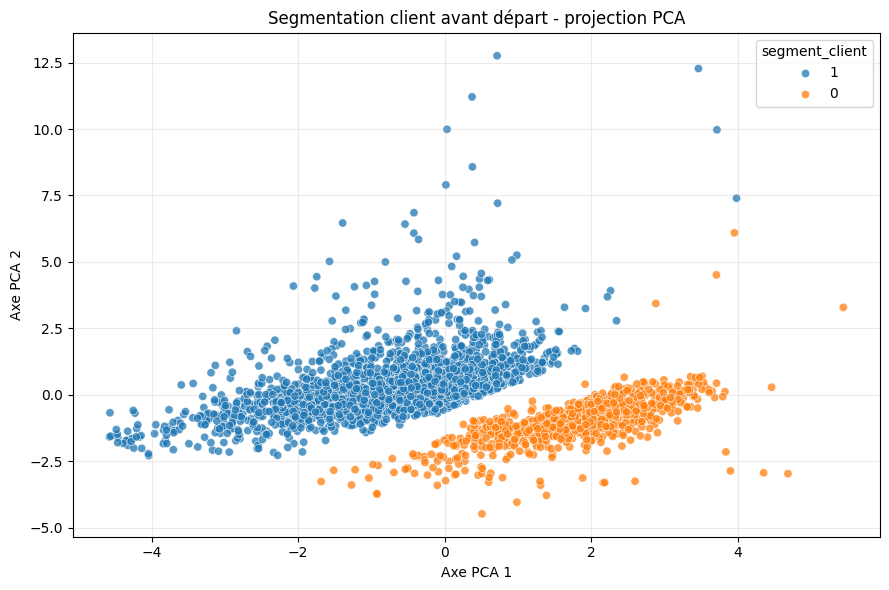

In [9]:
# Variables avant départ uniquement : connues avant la réalisation du séjour.
features_clustering = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]
features_clustering = [
    col for col in features_clustering if col in df_model.columns
]

X_clustering = df_model[features_clustering].copy()

colonnes_numeriques_clustering = X_clustering.select_dtypes(include=[np.number]).columns.tolist()
colonnes_categorielles_clustering = [
    col for col in X_clustering.columns if col not in colonnes_numeriques_clustering
]

preprocesseur_clustering = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            colonnes_numeriques_clustering,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            colonnes_categorielles_clustering,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

X_clustering_prepare = preprocesseur_clustering.fit_transform(X_clustering)
X_clustering_prepare = np.asarray(X_clustering_prepare, dtype=float)

# Choix exploratoire du nombre de clusters avec le score de silhouette.
scores_silhouette = []
for k in range(2, 7):
    modele_kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = modele_kmeans.fit_predict(X_clustering_prepare)
    scores_silhouette.append({
        "k": k,
        "silhouette": silhouette_score(X_clustering_prepare, labels),
    })

silhouette_clustering = pd.DataFrame(scores_silhouette)
k_retenu = int(
    silhouette_clustering.sort_values("silhouette", ascending=False).iloc[0]["k"]
)

modele_segmentation_client = KMeans(
    n_clusters=k_retenu,
    random_state=RANDOM_STATE,
    n_init=10,
)
segments_client = modele_segmentation_client.fit_predict(X_clustering_prepare)

df_segments = df_model.copy()
df_segments["segment_client"] = segments_client.astype(int)

count_column = "trip_id" if "trip_id" in df_segments.columns else "budget_total"
aggregations_segments = {
    "nb_sejours": (count_column, "count"),
    "budget_moyen": ("budget_total", "mean"),
    "duree_moyenne": ("duree_jours", "mean"),
    "prix_vol_moyen": ("prix_vol", "mean"),
    "part_vol_budget_moyenne": ("part_vol_budget", "mean"),
}

# Variables après séjour utilisées uniquement pour lire les segments aprés création.
if TARGET_COLUMN in df_segments.columns:
    aggregations_segments["satisfaction_moyenne"] = (TARGET_COLUMN, "mean")
if "respect_budget" in df_segments.columns:
    aggregations_segments["taux_budget_respecte"] = ("respect_budget", "mean")
if "reorganisation_necessaire" in df_segments.columns:
    aggregations_segments["taux_reorganisation"] = ("reorganisation_necessaire", "mean")

profil_segments = (
    df_segments
    .groupby("segment_client")
    .agg(**aggregations_segments)
    .reset_index()
)
profil_segments["part_lignes_pct"] = (
    profil_segments["nb_sejours"] / len(df_segments) * 100
).round(2)

def mode_safe(series: pd.Series):
    values = series.dropna()
    if values.empty:
        return "non_disponible"
    return values.mode().iloc[0]

variables_categorielles_description = [
    "client_type",
    "destination",
    "saison",
    "type_hebergement",
    "activite_principale",
]
variables_categorielles_description = [
    col for col in variables_categorielles_description if col in df_segments.columns
]

profil_categoriel_segments = (
    df_segments
    .groupby("segment_client")[variables_categorielles_description]
    .agg(mode_safe)
    .reset_index()
)
profil_categoriel_segments = profil_categoriel_segments.rename(columns={
    "client_type": "client_type_majoritaire",
    "destination": "destination_majoritaire",
    "saison": "saison_majoritaire",
    "type_hebergement": "hebergement_majoritaire",
    "activite_principale": "activite_majoritaire",
})

profil_segments = profil_segments.merge(
    profil_categoriel_segments,
    on="segment_client",
    how="left",
)

def proposer_libelle_segment(row: pd.Series) -> str:
    if row.get("client_type_majoritaire") == "business":
        return "profil_business"
    if row.get("hebergement_majoritaire") in ["resort", "villa"]:
        return "profil_premium_loisir"
    if row.get("duree_moyenne", 0) >= df_segments["duree_jours"].median():
        return "profil_sejour_long"
    return "profil_standard"

profil_segments["libelle_segment_metier"] = profil_segments.apply(
    proposer_libelle_segment,
    axis=1,
)

print(f"Nombre de clusters retenu : {k_retenu}")
print("Scores de silhouette testés :")
display(silhouette_clustering.round(4))

colonnes_resume_segments = [
    "segment_client",
    "libelle_segment_metier",
    "nb_sejours",
    "part_lignes_pct",
    "client_type_majoritaire",
    "destination_majoritaire",
    "saison_majoritaire",
    "hebergement_majoritaire",
    "activite_majoritaire",
    "budget_moyen",
    "duree_moyenne",
    "prix_vol_moyen",
    "part_vol_budget_moyenne",
]
colonnes_resume_segments = [
    col for col in colonnes_resume_segments if col in profil_segments.columns
]

resume_segments_client = (
    profil_segments[colonnes_resume_segments]
    .sort_values("segment_client")
    .reset_index(drop=True)
)

print("Profil synthétique des segments clients :")
display(resume_segments_client.round(3))

colonnes_exemples_segments = [
    "segment_client",
    "trip_id",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "activite_principale",
]
colonnes_exemples_segments = [
    col for col in colonnes_exemples_segments if col in df_segments.columns
]

exemples_segments_client = (
    df_segments
    .sort_values(["segment_client", "budget_total"])
    .groupby("segment_client", group_keys=False)
    .head(3)[colonnes_exemples_segments]
    .reset_index(drop=True)
)

print("Exemples de séjours par segment :")
display(exemples_segments_client)

# Projection 2D pour visualiser les segments.
pca_segments = PCA(n_components=2, random_state=RANDOM_STATE)
projection_segments = pca_segments.fit_transform(X_clustering_prepare)
projection_segments = pd.DataFrame({
    "axe_1": projection_segments[:, 0],
    "axe_2": projection_segments[:, 1],
    "segment_client": df_segments["segment_client"].astype(str),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=projection_segments,
    x="axe_1",
    y="axe_2",
    hue="segment_client",
    palette="tab10",
    alpha=0.75,
)
plt.title("Segmentation client avant départ - projection PCA")
plt.xlabel("Axe PCA 1")
plt.ylabel("Axe PCA 2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#### Interprétation technique de la segmentation

La segmentation est une analyse exploratoire optionnelle, distincte du modèle industrialisé. Elle utilise uniquement des variables disponibles avant le départ : profil client, budget, destination, saison, durée, hébergement, prix du vol, météo prévue, activité principale et variables dérivées simples.

Le traitement appliqué est le suivant :

- variables numériques : imputation par la médiane puis standardisation avec `StandardScaler` ;
- variables catégorielles : imputation par le mode puis encodage avec `OneHotEncoder`, car les catégories n'ont pas d'ordre naturel ;
- algorithme : `KMeans` ;
- choix du nombre de segments : test de `k = 2` à `6`, puis sélection du meilleur score de silhouette.

Chaque segment est ensuite décrit par ses moyennes métier (`budget_moyen`, `duree_moyenne`, `prix_vol_moyen`, `part_vol_budget_moyenne`) et ses modalités dominantes (`client_type`, `destination`, `saison`, `type_hebergement`, `activite_principale`). La projection PCA sert uniquement à visualiser les groupes.

Les variables après séjour ne servent pas à créer les clusters ; elles peuvent seulement aider à interpréter les segments après coup.


#### Interprétation métier de la segmentation

La segmentation aide à mieux comprendre les profils de séjours et peut alimenter la personnalisation commerciale : adapter les recommandations de destinations, d'hébergements, d'activités ou le niveau d'accompagnement avant départ.

Les libellés comme `profil_business`, `profil_premium_loisir`, `profil_sejour_long` ou `profil_standard` sont des lectures métier simples des caractéristiques dominantes de chaque cluster. Ils ne constituent pas des règles automatiques : ils doivent être validés par l'agence avant tout usage opérationnel.

Dans ce projet, la segmentation reste un outil d'analyse et de reporting. Elle n'est pas utilisée comme entrée du modèle retenu ni industrialisée dans l'API. Sa valeur principale est d'expliquer les profils clients et d'ouvrir une piste future vers un moteur de recommandation plus personnalisé.

Limites : les segments dépendent du dataset synthétique, des variables retenues et du nombre de clusters choisi. Ils ne doivent jamais servir à exclure automatiquement un client d'une offre ou d'un service.


## Partie 4 - Modélisation : choix, entraînement et validation

**Objectif** : choisir un modèle supervisé capable d'estimer, avant le départ, si un séjour présente un potentiel de satisfaction suffisant.

- formuler le problème ML et les métriques de décision ;
- vérifier si la cible originale en `5` classes est pertinente ;
- comparer un nombre limité de modèles candidats ;
- retenir le modèle offrant le meilleur compromis entre performance, simplicité, explicabilité et industrialisation ;
- conserver les essais complémentaires, dont le NLP, uniquement comme éléments exploratoires.

### 4.0 Cadrage du problème et pipeline

Cette section fixe le cadre de décision avant de lancer les modèles. Elle reprend les éléments utiles : type de problème, cible, métriques, modèles comparés et garde-fous contre la fuite de données.

| Élément | Choix retenu | Justification |
| --- | --- | --- |
| Type de problème | Classification supervisée | La cible `satisfaction_client` est connue dans l'historique |
| Cible principale | Binaire : `non_satisfait_1_2_3` vs `satisfait_4_5` | Plus lisible pour décider si une proposition doit être revue par un conseiller |
| Expérience de contrôle | Modélisation en `5` classes | Vérifier si la granularité fine des notes est exploitable |
| Métrique principale | `macro_f1` | Donne le même poids aux deux classes malgré le déséquilibre |
| Métriques complémentaires | `balanced_accuracy`, `recall_satisfait`, `ROC AUC`, matrice de confusion | Mesurer la robustesse, le rappel de la classe satisfaite et les erreurs concrètes |
| Baseline | `DummyClassifier` | Vérifier que les modèles apprennent mieux qu'une règle naïve |
| Modèles candidats | `LogisticRegression`, `RandomForest` | Comparer un modèle simple et explicable à un modèle non linéaire plus complexe |

Le pipeline suivant est celui utilisé pour comparer puis retenir le modèle final. Les traitements qui apprennent des paramètres sont réalisés **après** le split train/test afin d'éviter la fuite de données.

```text
Dataset final nettoyé
-> définition des variables utilisables avant le départ
-> construction de la cible de satisfaction
-> split train/test stratifié
-> imputation apprise uniquement sur le train
-> traitement IQR des outliers appris uniquement sur le train
-> encodage OneHotEncoder appris uniquement sur le train
-> standardisation apprise uniquement sur le train
-> entraînement des modèles candidats
-> évaluation sur test non vu
```

Cette organisation permet de comparer les modèles dans les mêmes conditions et de garder un jeu de test réellement indépendant.

#### Fonctions techniques du pipeline sklearn

Cette partie définit les briques techniques utilisées ensuite pour entraîner et comparer les modèles dans des conditions identiques : traitement IQR des outliers, détection des variables binaires, construction du `ColumnTransformer`, entraînement des pipelines et calcul des métriques.

In [10]:
class IQRMedianOutlierReplacer(BaseEstimator, TransformerMixin):
    """Remplace les outliers IQR par la mediane apprise sur le train."""

    def __init__(self, factor: float = 1.5):
        # factor=1.5 correspond a la règle IQR classique : Q1 - 1.5*IQR / Q3 + 1.5*IQR.
        self.factor = factor

    def fit(self, X, y=None):
        # Les bornes IQR et la médiane sont apprises uniquement sur le jeu transmis au fit.
        # Dans un Pipeline sklearn, ce fit est appelé uniquement sur le train.
        X_array = np.asarray(X, dtype=float)
        self.q1_ = np.nanquantile(X_array, 0.25, axis=0)
        self.q3_ = np.nanquantile(X_array, 0.75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_bounds_ = self.q1_ - self.factor * self.iqr_
        self.upper_bounds_ = self.q3_ + self.factor * self.iqr_
        self.medians_ = np.nanmedian(X_array, axis=0)
        return self

    def transform(self, X):
        # Les valeurs hors bornes sont remplacées par la médiane apprise au fit.
        X_array = np.asarray(X, dtype=float).copy()
        outlier_mask = (
            (X_array < self.lower_bounds_)
            | (X_array > self.upper_bounds_)
        )
        return np.where(outlier_mask, self.medians_, X_array)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f"x{i}" for i in range(len(self.medians_))], dtype=object)
        return np.asarray(input_features, dtype=object)


# Certaines colonnes exploratoires peuvent contenir des listes ou dictionnaires.
# Ces valeurs ne sont pas compatibles avec les opérations d'encodage ou de groupby.
def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()


def detecter_variables_binaires(X: pd.DataFrame, numeric_features: list[str]) -> list[str]:
    # Les variables binaires 0/1 ne sont pas standardisees comme des variables continues.
    binary_features = []
    for column in numeric_features:
        if contient_valeur_non_hashable(X[column]):
            continue
        try:
            values = pd.Series(X[column].dropna().unique())
            unique_values = set(values.astype(float).tolist())
        except (TypeError, ValueError):
            continue
        if values.empty:
            continue
        if unique_values.issubset({0.0, 1.0}):
            binary_features.append(column)
    return binary_features


def construire_preprocesseur(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    # 1. Exclure les colonnes non compatibles avec sklearn si elles existent.
    non_hashable_features = [
        column for column in X.columns
        if contient_valeur_non_hashable(X[column])
    ]
    if non_hashable_features:
        print("Colonnes ignorees par le preprocesseur car elles contiennent des listes/dictionnaires :", non_hashable_features)

    X_compatible = X.drop(columns=non_hashable_features, errors="ignore")

    # 2. Séparer les variables numeriques et categorielles pour appliquer les bons traitements.
    numeric_features = X_compatible.select_dtypes(include="number").columns.tolist()
    categorical_features = X_compatible.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    # 3. Distinguer numériques continues et indicateurs binaires.
    binary_numeric_features = detecter_variables_binaires(X_compatible, numeric_features)
    continuous_numeric_features = [
        column for column in numeric_features
        if column not in binary_numeric_features
    ]

    # 4. Numériques continues : mediane -> IQR -> standardisation.
    continuous_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("outliers_iqr", IQRMedianOutlierReplacer()),
        ("scaler", StandardScaler()),
    ])

    # 5. Numériques binaires : imputation simple, pas de standardisation.
    binary_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    # 6. Catégorielles : modalité la plus frequente puis OneHotEncoder.
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformers = []
    if continuous_numeric_features:
        transformers.append(("num_cont", continuous_numeric_transformer, continuous_numeric_features))
    if binary_numeric_features:
        transformers.append(("num_bin", binary_numeric_transformer, binary_numeric_features))
    if categorical_features:
        transformers.append(("cat", categorical_transformer, categorical_features))

    preprocess = ColumnTransformer(transformers=transformers)

    return preprocess, numeric_features, categorical_features



def evaluer_classification(modeles: dict, X_train, X_test, y_train, y_test, preprocess) -> tuple[pd.DataFrame, dict]:
    # Cette fonction entraîné chaque modèle avec le même pipeline de préparation,
    # puis compare les performances sur le même jeu de test.
    # Pour une cible binaire 0/1, elle ajoute aussi precision, recall et ROC AUC.
    rows = []
    fitted = {}

    y_test_series = pd.Series(y_test)
    classes_test = sorted(y_test_series.dropna().unique().tolist())
    is_binary_target = set(classes_test).issubset({0, 1}) and len(classes_test) == 2

    for model_name, model in modeles.items():
        # clone() évite qu'un modele ou preprocesseur ajuste contamine l'expérience suivante.
        pipeline = Pipeline(steps=[
            ("preprocess", clone(preprocess)),
            ("model", clone(model)),
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        row = {
            "modele": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        }

        if is_binary_target:
            row.update({
                "precision_satisfait": precision_score(y_test, predictions, pos_label=1, zero_division=0),
                "recall_satisfait": recall_score(y_test, predictions, pos_label=1, zero_division=0),
                "f1_satisfait": f1_score(y_test, predictions, pos_label=1, zero_division=0),
            })
            if hasattr(pipeline, "predict_proba") and 1 in pipeline.classes_:
                positive_class_index = list(pipeline.classes_).index(1)
                probabilities = pipeline.predict_proba(X_test)[:, positive_class_index]
                row["roc_auc"] = roc_auc_score(y_test, probabilities)

        rows.append(row)
        fitted[model_name] = pipeline

    # Le macro_f1 est prioritaire car il donne le même poids à chaque classe.
    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, fitted

def afficher_distribution(y: pd.Series, label: str) -> None:
    # Contrôle rapide de l'équilibre des classes avant ou après split.
    print(label)
    display(
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
        .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
    )


### 4.1 Construction de la cible et split stratifié

Deux formulations de cible sont testées pour choisir le bon niveau de granularité :

- **5 classes** : prédire directement la note `1`, `2`, `3`, `4` ou `5` ;
- **binaire** : regroupe les notes en deux familles métier distinguées `non_satisfait_1_2_3` et `satisfait_4_5`.

La cible 5 classes conserve l'information la plus fine.
La cible binaire est retenue pour la modélisation principale car elle correspond mieux à l'usage métier : repérer avant le départ les séjours susceptibles d'être satisfaisants et ceux qui nécessitent une revue humaine.

Ce regroupement simplifie le problème et le rend plus directement exploitable pour un usage métier : identifiér si une proposition de séjour a de bonnes chances d'aboutir à un client satisfait. Comme la classe positive `satisfait_4_5` peut être minoritaire, l'Évaluation conserve `macro_f1`, `balanced_accuracy`, le `recall_satisfait`, la matrice de confusion et la ROC AUC.

In [11]:
# Colonnes connues uniquement pendant ou après le voyage.
# Elles sont exclues du modèle retenu pour éviter la fuite de données.
post_trip_columns = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "retour_client",
]

# Colonnes techniques sans signal métier direct.
technical_columns = ["trip_id"]

# Sélection des variables autorisées avant départ.
colonnes_exclues_modele = [TARGET_COLUMN, *technical_columns, *post_trip_columns]
feature_columns_pre = [
    column for column in df_model.columns
    if column not in colonnes_exclues_modele
]

colonnes_non_hashables_pre = [
    column for column in feature_columns_pre
    if contient_valeur_non_hashable(df_model[column])
]

if colonnes_non_hashables_pre:
    print("Colonnes exclues car non compatibles avec l'encodage :", colonnes_non_hashables_pre)

feature_columns_pre = [
    column for column in feature_columns_pre
    if column not in colonnes_non_hashables_pre
]

# X_pre contient uniquement les informations disponibles avant le départ.
X_pre = df_model[feature_columns_pre].copy().replace({pd.NA: np.nan})

# y_pre_5 conserve les notes originales 1 à 5.
y_pre_5 = df_model[TARGET_COLUMN].astype(int).copy()

# y_pre devient la cible binaire retenue pour la modélisation principale.
# 0 = notes 1, 2 ou 3 ; 1 = notes 4 ou 5.
y_pre = y_pre_5.apply(regrouper_satisfaction_binaire).astype(int).copy()

# Le préprocesseur est défini ici, mais ses paramètres seront appris lors du fit sur le train.
preprocess_pre, numeric_pre, categorical_pre = construire_preprocesseur(X_pre)

resume_pre = pd.DataFrame({
    "famille": ["numériques", "catégorielles", "total", "exclues"],
    "nombre": [len(numeric_pre), len(categorical_pre), X_pre.shape[1], len(colonnes_exclues_modele)],
    "colonnes": [numeric_pre, categorical_pre, feature_columns_pre, colonnes_exclues_modele],
})

# Résumé des colonnes utilisées et exclues pour vérifier le périmètre avant départ.
display(resume_pre)
afficher_distribution(y_pre_5, "Distribution cible avant départ à 5 classes")
afficher_distribution(y_pre, "Distribution cible avant départ binaire")


,famille,nombre,colonnes
0,numériques,17,"[budget_total, duree_jours, prix_vol, reste_bu..."
1,catégorielles,7,"[client_type, destination, saison, type_heberg..."
2,total,24,"[client_type, budget_total, destination, saiso..."
3,exclues,6,"[satisfaction_client, trip_id, imprevus, reorg..."


Distribution cible avant départ à 5 classes


,classe,nombre,pourcentage
0,1,440,14.67
1,2,826,27.53
2,3,792,26.40
3,4,675,22.50
4,5,267,8.90


Distribution cible avant départ binaire


,classe,nombre,pourcentage
0,0,2058,68.6
1,1,942,31.4


In [12]:
# Split stratifié : conserve la proportion des 2 classes dans train et test.
# Il est fait avant toute opération apprenant des paramètres.
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre,
)

labels_satisfaction_pre = libelles_satisfaction_binaire


def calculer_equilibre_classes(y: pd.Series, jeu: str) -> pd.DataFrame:
    # Retourne la distribution des classes pour vérifier le déséquilibre global/train/test.
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["jeu"] = jeu
    distribution["libelle"] = distribution["classe"].map(labels_satisfaction_pre)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    return distribution[["jeu", "classe", "libelle", "nombre", "pourcentage"]]


# Comparer global, train et test permet de vérifier que le split stratifié fonctionne.
equilibre_classes_pre = pd.concat(
    [
        calculer_equilibre_classes(y_pre, "global"),
        calculer_equilibre_classes(y_train_pre, "train"),
        calculer_equilibre_classes(y_test_pre, "test"),
    ],
    ignore_index=True,
)

display(equilibre_classes_pre)

classe_majoritaire_pre = equilibre_classes_pre[equilibre_classes_pre["jeu"] == "global"].sort_values(
    "pourcentage",
    ascending=False,
).iloc[0]

print(
    "Classe majoritaire globale : "
    f"{classe_majoritaire_pre['libelle']} "
    f"({classe_majoritaire_pre['pourcentage']} %)"
)


,jeu,classe,libelle,nombre,pourcentage
0,global,0,non_satisfait_1_2_3,2058,68.60
1,global,1,satisfait_4_5,942,31.40
2,train,0,non_satisfait_1_2_3,1646,68.58
3,train,1,satisfait_4_5,754,31.42
4,test,0,non_satisfait_1_2_3,412,68.67
5,test,1,satisfait_4_5,188,31.33


Classe majoritaire globale : non_satisfait_1_2_3 (68.6 %)


Les deux étapes précédentes transforment le besoin métier en problème d'apprentissage exploitable. La cible binaire `non_satisfait_1_2_3` / `satisfait_4_5` répond directement au cas d'usage : aider le conseiller à repérer, avant le départ, les séjours qui méritent une revue humaine.

Le split stratifié garantit que le jeu d'entraînement et le jeu de test gardent la même proportion de séjours satisfaits et non satisfaits. Cela permet d'évaluer le modèle dans des conditions proches de l'usage réel et d'éviter une conclusion trop optimiste liée à une mauvaise répartition des classes.

### 4.2 Corrélations des variables d’entrée

Cette cellule mesure le lien entre les variables numériques connues avant le départ et la cible `satisfaction_client` regroupée en binaire.

La corrélation de Spearman est utilisée car elle mesure une relation monotone sans supposer une relation linéaire parfaite. Elle est calculée uniquement sur le jeu d'entraînement.

L'objectif est de vérifier si les variables avant départ contiennent un signal exploitable avant la comparaison des modèles.

La heatmap ajoutée après le tableau permet de visualiser rapidement l'intensité et le sens des corrélations entre les variables numériques avant départ et la cible.


,correlation_spearman_satisfaction_binaire
score_potentiel_satisfaction,0.4201
part_vol_budget,-0.3230
reste_budget_apres_vol,0.3178
budget_total,0.3074
score_budget_destination,0.2697
budget_apres_vol_par_jour,0.2400
score_adequation_activite_profil,0.2083
budget_par_jour,0.1894
client_business,-0.1555
duree_jours,0.1071


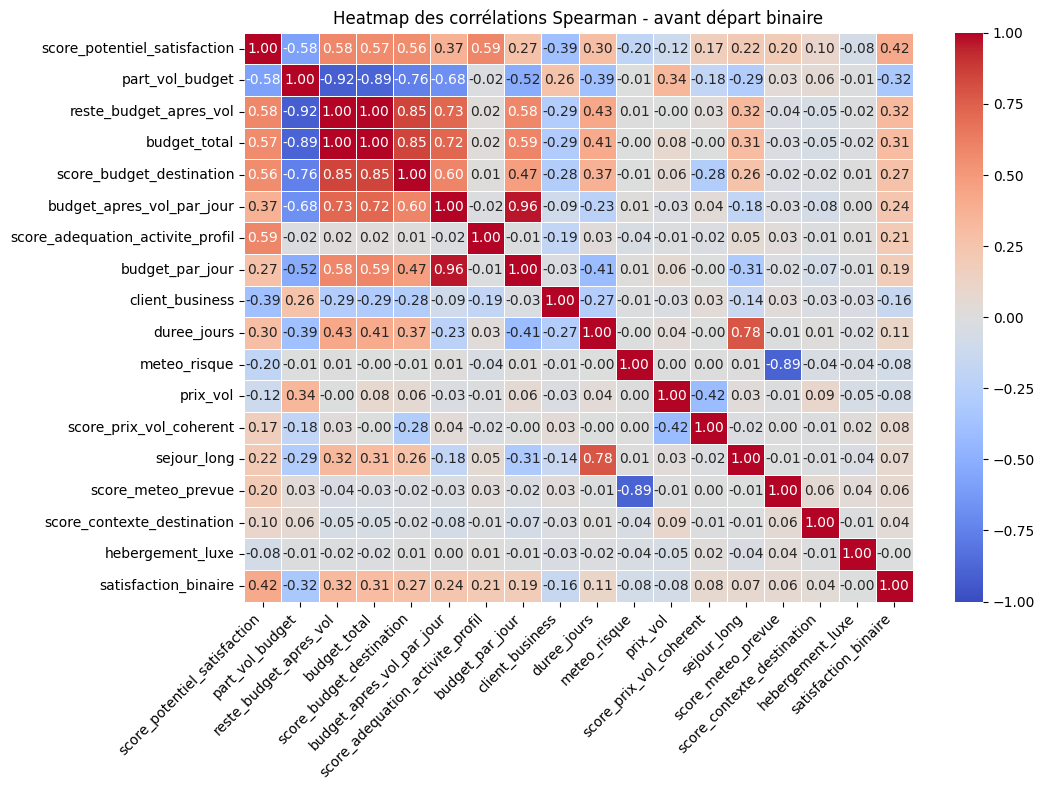

In [13]:
# Analyse simple du lien monotone entre variables numériques avant départ et cible binaire.
# Elle est calculée uniquement sur le train pour ne pas utiliser le test dans l'analyse.
correlation_df_pre = X_train_pre[numeric_pre].copy()
correlation_df_pre["satisfaction_binaire"] = y_train_pre.values

spearman_pre = (
    correlation_df_pre.corr(method="spearman")["satisfaction_binaire"]
    .drop("satisfaction_binaire")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(spearman_pre.to_frame("correlation_spearman_satisfaction_binaire").round(4).head(15))

# Visualisation : heatmap de la matrice de corrélation Spearman.
# Les variables sont ordonnées selon leur lien absolu avec la satisfaction binaire.
variables_heatmap_pre = [
    *spearman_pre.abs().sort_values(ascending=False).index.tolist(),
    "satisfaction_binaire",
]

correlation_heatmap_pre = correlation_df_pre[variables_heatmap_pre].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_heatmap_pre,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Heatmap des corrélations Spearman - avant départ binaire")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Les corrélations de Spearman mesurent ici le lien monotone entre les variables numériques avant départ et la cible binaire `non satisfait` / `satisfait`.

Une corrélation positive signifie que la variable augmente avec la probabilité d'appartenir à la classe `satisfait_4_5`. Une corrélation négative indique au contraire une association avec la classe `non_satisfait_1_2_3`.

Les résultats montrent que les variables enrichies apportent bien un signal plus lisible que les variables brutes seules. Les corrélations les plus fortes concernent notamment :

- `score_potentiel_satisfaction` : `+0.4201`, signal positif le plus important ;
- `part_vol_budget` : `-0.3230`, plus le vol pèse dans le budget, plus le risque d'insatisfaction augmente ;
- `reste_budget_apres_vol` : `+0.3178`, un budget restant plus confortable est associé à une meilleure satisfaction ;
- `score_budget_destination` : `+0.2697`, la cohérence entre budget et destination apporte un signal utile ;
- `score_adequation_activite_profil` : `+0.2083`, l'adéquation entre activité et profil client est aussi informative.

À l'inverse, certaines variables brutes seules restent moins explicatives, par exemple `prix_vol` (`-0.0776`), `duree_jours` (`+0.1071`) ou `meteo_risque` (`-0.0785`).

Conclusion : l'enrichissement a bien amélioré la lisibilité du signal métier. Les corrélations ne prouvent pas une causalité et restent descriptives, mais elles justifient l'intérêt des variables construites avant la comparaison des modèles.


### 4.3 Comparaison cadrée des modèles candidats

La comparaison est volontairement limitée à trois références pour rendre la décision lisible : une baseline, un modèle simple et un modèle plus complexe.

| Modèle | Rôle | Avantage principal | Limite | Critère de décision |
| --- | --- | --- | --- | --- |
| `DummyClassifier` | Baseline naïve | Donne un point de comparaison minimal | N'apprend aucun signal | Les autres modèles doivent le dépasser sur `macro_f1` et `ROC AUC` |
| `LogisticRegression` | Modèle simple et explicable | Rapide, stable, industrialisable | Capte surtout des relations simples | Retenue si ses performances sont compétitives |
| `RandomForest` | Modèle non linéaire challenger | Capte des interactions entre variables | Moins sobre et plus complexe | Retenu uniquement si le gain est robuste et significatif |

Le modèle final est choisi prioritairement sur `macro_f1`, puis vérifié avec `balanced_accuracy`, `recall_satisfait`, `ROC AUC` et la matrice de confusion.


#### 4.3.1 Expérience comparative avant regroupement : modélisation du modèle retenu en 5 classes

Avant de retenir la cible en binaire, une expérience est réalisée avec la satisfaction originale en 5 classes (`1`, `2`, `3`, `4`, `5`).

L'objectif est de tester si le modèle peut distinguer finement les cinq niveaux de satisfaction à partir des seules variables avant départ. Pour rendre la comparaison cohérente, les mêmes lignes train/test que la modélisation binaire sont utilisées ; seule la cible change.


In [14]:
# Modélisation du modèle retenu en 5 classes.
# On conserve les mêmes lignes train/test que pour la version binaire.
# Cela permet de comparer deux formulations de cible sur les mêmes observations.
y_train_pre_5 = y_pre_5.loc[X_train_pre.index].astype(int)
y_test_pre_5 = y_pre_5.loc[X_test_pre.index].astype(int)

# Contrôle de la distribution des 5 notes sur train et test.
distribution_pre_5 = pd.concat(
    [
        distribution_classes(y_pre_5, libelles_satisfaction_5, "global_5_classes"),
        distribution_classes(y_train_pre_5, libelles_satisfaction_5, "train_5_classes"),
        distribution_classes(y_test_pre_5, libelles_satisfaction_5, "test_5_classes"),
    ],
    ignore_index=True,
)
display(distribution_pre_5)

modeles_pre_5 = {
    "DummyClassifier_5_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_5_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_5_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_pre_5, fitted_pre_5 = evaluer_classification(
    modeles_pre_5,
    X_train_pre,
    X_test_pre,
    y_train_pre_5,
    y_test_pre_5,
    preprocess_pre,
)

display(results_pre_5.round(4))
best_pre_5_model_name = results_pre_5.iloc[0]["modele"]
print("Meilleur modèle 5 classes :", best_pre_5_model_name)


,cible,classe,libelle,nombre,pourcentage
0,global_5_classes,1,note_1_tres_insatisfait,440,14.67
1,global_5_classes,2,note_2_insatisfait,826,27.53
2,global_5_classes,3,note_3_neutre,792,26.40
3,global_5_classes,4,note_4_satisfait,675,22.50
4,global_5_classes,5,note_5_tres_satisfait,267,8.90
5,train_5_classes,1,note_1_tres_insatisfait,355,14.79
6,train_5_classes,2,note_2_insatisfait,661,27.54
7,train_5_classes,3,note_3_neutre,630,26.25
8,train_5_classes,4,note_4_satisfait,540,22.50
9,train_5_classes,5,note_5_tres_satisfait,214,8.92


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_5_classes,0.4217,0.3971,0.3990
1,LogisticRegression_5_classes,0.3467,0.3676,0.3388
2,DummyClassifier_5_classes,0.2750,0.2000,0.0863


Meilleur modèle 5 classes : RandomForest_5_classes


La formulation en 5 classes est conservée comme expérience de référence, car elle correspond directement à l'échelle originale de satisfaction `1` à `5`.

Les résultats confirment cependant que cette formulation est difficile à exploiter pour le cas d'usage :

- la classe `note_5_très_satisfait` est minoritaire avec seulement `8.90 %` du dataset global ;
- le meilleur modèle 5 classes est `RandomForest_5_classes` ;
- ses performances restent modestes : `accuracy = 0.4217`, `balanced_accuracy = 0.3971`, `macro_f1 = 0.3990` ;
- la baseline `DummyClassifier_5_classes` est bien dépassée (`macro_f1 = 0.0863`), donc le modèle apprend un signal, mais ce signal reste insuffisant pour prédire finement les cinq notes.

La difficulté vient du fait que le modèle doit distinguer des niveaux proches, par exemple `1` vs `2` ou `4` vs `5`, alors que deux voyages peuvent être très similaires avant le départ.

Conclusion : la cible 5 classes est utile pour documenter l'essai, mais elle est trop fine pour l'objectif opérationnel. Le projet doit donc tester et privilégier une cible plus lisible métier : `non_satisfait_1_2_3` vs `satisfait_4_5`.


#### 4.3.2 Modélisation en classes binaires


In [15]:
# Trois réfeéences sont comparées : baseline, modele lineaire et modele d'arbres.
# La baseline n'est pas un modele candidat final ; elle sert de point de comparaison minimal.
# class_weight="balanced" aide les modeles supervises a tenir compte du desequilibre des classes.
modeles_pre = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

# Entrainement et Évaluation des modeles sur le même split train/test.
results_pre, fitted_pre = evaluer_classification(
    modeles_pre,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

# Classement selon macro_f1, métrique principale du projet.
display(results_pre.round(4))
best_pre_model_name = results_pre.iloc[0]["modele"]
print("Modèle retenu `LogisticRegression` :", best_pre_model_name)


,modele,accuracy,balanced_accuracy,macro_f1,precision_satisfait,recall_satisfait,f1_satisfait,roc_auc
0,LogisticRegression,0.7167,0.7040,0.6893,0.5385,0.6702,0.5972,0.7303
1,RandomForest,0.7083,0.6719,0.6681,0.5320,0.5745,0.5524,0.7232
2,DummyClassifier,0.6867,0.5000,0.4071,0.0000,0.0000,0.0000,0.5000


Modèle retenu `LogisticRegression` : LogisticRegression


#### 4.3.3 Comparaison chiffrée : cible 5 classes vs cible binaire

Cette comparaison mesure l'effet du regroupement de la satisfaction. Les métriques sont comparées entre le meilleur modèle obtenu en 5 classes et le meilleur modèle obtenu en binaire.


In [16]:
# Comparaison des meilleures performances entre cible 5 classes et cible binaire.
best_pre_5 = results_pre_5.iloc[0]
best_pre_binary = results_pre.iloc[0]

comparison_pre_5_vs_binary = pd.DataFrame([
    {
        "formulation_cible": "5 classes : notes 1, 2, 3, 4, 5",
        "nb_classes": 5,
        "meilleur_modele": best_pre_5["modele"],
        "accuracy": best_pre_5["accuracy"],
        "balanced_accuracy": best_pre_5["balanced_accuracy"],
        "macro_f1": best_pre_5["macro_f1"],
        "recall_satisfait": np.nan,
        "roc_auc": np.nan,
    },
    {
        "formulation_cible": "binaire : non satisfait vs satisfait",
        "nb_classes": 2,
        "meilleur_modele": best_pre_binary["modele"],
        "accuracy": best_pre_binary["accuracy"],
        "balanced_accuracy": best_pre_binary["balanced_accuracy"],
        "macro_f1": best_pre_binary["macro_f1"],
        "recall_satisfait": best_pre_binary.get("recall_satisfait", np.nan),
        "roc_auc": best_pre_binary.get("roc_auc", np.nan),
    },
])

macro_f1_5 = comparison_pre_5_vs_binary.loc[comparison_pre_5_vs_binary["nb_classes"] == 5, "macro_f1"].iloc[0]
macro_f1_binary = comparison_pre_5_vs_binary.loc[comparison_pre_5_vs_binary["nb_classes"] == 2, "macro_f1"].iloc[0]
gain_macro_f1_binary_vs_5 = macro_f1_binary - macro_f1_5

comparison_pre_5_vs_binary["ecart_macro_f1_vs_5_classes"] = [
    0.0,
    gain_macro_f1_binary_vs_5,
]

display(comparison_pre_5_vs_binary.round(4))
print(f"Gain macro_f1 du regroupement binaire vs 5 classes : {gain_macro_f1_binary_vs_5:.4f}")


,formulation_cible,nb_classes,meilleur_modele,accuracy,balanced_accuracy,macro_f1,recall_satisfait,roc_auc,ecart_macro_f1_vs_5_classes
0,"5 classes : notes 1, 2, 3, 4, 5",5,RandomForest_5_classes,0.4217,0.3971,0.3990,NaN,NaN,0.0000
1,binaire : non satisfait vs satisfait,2,LogisticRegression,0.7167,0.7040,0.6893,0.6702,0.7303,0.2903


Gain macro_f1 du regroupement binaire vs 5 classes : 0.2903


La comparaison sert à arbitrer le niveau de granularité de la cible. Les résultats montrent un avantage net de la formulation binaire.

| Comparaison | 5 classes | Binaire | Gain binaire |
| --- | ---: | ---: | ---: |
| Meilleur modèle | `RandomForest_5_classes` | `LogisticRegression` | - |
| `accuracy` | `0.4217` | `0.7167` | `+0.2950` |
| `balanced_accuracy` | `0.3971` | `0.7040` | `+0.3069` |
| `macro_f1` | `0.3990` | `0.6893` | `+0.2903` |
| `recall_satisfait` | Non calculé | `0.6702` | Mesure exploitable en binaire |
| `ROC AUC` | Non calculé | `0.7303` | Supérieur au hasard (`0.5000`) |

Lecture : la cible 5 classes cherche à prédire une note fine de `1` à `5`, mais les performances restent modestes. La cible binaire simplifie le problème autour d'une question directement utile pour l'agence : le séjour a-t-il un potentiel satisfaisant (`4` ou `5`) ou doit-il être revu ?

Conclusion : le regroupement binaire est retenu car il améliore fortement les trois métriques principales et permet d'interpréter des indicateurs utiles au métier (`recall_satisfait`, `ROC AUC`). La cible 5 classes est conservée uniquement comme expérience comparative documentée.


#### 4.3.4 Apport du dataset final enrichi par rapport au dataset initial

Cette expérience répond à une question importante : le dataset initial brut explique-t-il suffisamment la satisfaction client ?

Pour le vérifier, on compare deux scénarios avec le même algorithme `LogisticRegression` et le même principe de split stratifié :

- **dataset initial brut** : uniquement les variables disponibles avant départ dans le fichier fourni ;
- **dataset final enrichi** : variables avant départ enrichies et documentées dans `dataset_final`.

L'objectif n'est pas d'ajouter une nouvelle piste de modélisation, mais de prouver que l'enrichissement apporte un signal plus exploitable.


In [17]:
# Comparaison dataset initial brut vs dataset final enrichi.
# Objectif : prouver que les variables brutes du dataset initial expliquent faiblement la satisfaction.

# 1. Preparation du dataset initial brut fourni.
df_initial_brut = pd.read_csv(FALLBACK_DATASET)
df_initial_model, rapport_initial_nettoyage = nettoyer_dataset(df_initial_brut)

features_initial_brutes = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
]
features_initial_brutes = [
    column for column in features_initial_brutes
    if column in df_initial_model.columns
]

X_initial_brut = (
    df_initial_model[features_initial_brutes]
    .copy()
    .replace({pd.NA: np.nan})
)
y_initial_brut = (
    df_initial_model[TARGET_COLUMN]
    .astype(int)
    .apply(regrouper_satisfaction_binaire)
    .astype(int)
)

# 2. Split et pipeline identiques dans l'esprit au modele final.
X_train_initial, X_test_initial, y_train_initial, y_test_initial = train_test_split(
    X_initial_brut,
    y_initial_brut,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_initial_brut,
)

preprocess_initial, numeric_initial, categorical_initial = construire_preprocesseur(X_initial_brut)

resultats_initial_brut, _ = evaluer_classification(
    {"LogisticRegression_initial_brut": LogisticRegression(max_iter=500, class_weight="balanced")},
    X_train_initial,
    X_test_initial,
    y_train_initial,
    y_test_initial,
    preprocess_initial,
)

# 3. Recuperation du resultat final deja calcule sur dataset_final.
resultat_initial = resultats_initial_brut.iloc[0]
resultat_final = results_pre[results_pre["modele"].eq("LogisticRegression")].iloc[0]

comparaison_signal_dataset = pd.DataFrame([
    {
        "scenario": "dataset initial - variables brutes",
        "lignes": len(df_initial_model),
        "variables_entree": len(features_initial_brutes),
        "accuracy": resultat_initial["accuracy"],
        "balanced_accuracy": resultat_initial["balanced_accuracy"],
        "macro_f1": resultat_initial["macro_f1"],
        "recall_satisfait": resultat_initial["recall_satisfait"],
        "roc_auc": resultat_initial["roc_auc"],
    },
    {
        "scenario": "dataset_final - variables enrichies",
        "lignes": len(df_model),
        "variables_entree": X_pre.shape[1],
        "accuracy": resultat_final["accuracy"],
        "balanced_accuracy": resultat_final["balanced_accuracy"],
        "macro_f1": resultat_final["macro_f1"],
        "recall_satisfait": resultat_final["recall_satisfait"],
        "roc_auc": resultat_final["roc_auc"],
    },
])

colonnes_scores_signal = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "recall_satisfait",
    "roc_auc",
]
comparaison_signal_dataset[colonnes_scores_signal] = comparaison_signal_dataset[colonnes_scores_signal].round(4)

gain_signal = {
    "gain_accuracy": round(
        comparaison_signal_dataset.loc[1, "accuracy"] - comparaison_signal_dataset.loc[0, "accuracy"],
        4,
    ),
    "gain_macro_f1": round(
        comparaison_signal_dataset.loc[1, "macro_f1"] - comparaison_signal_dataset.loc[0, "macro_f1"],
        4,
    ),
    "gain_roc_auc": round(
        comparaison_signal_dataset.loc[1, "roc_auc"] - comparaison_signal_dataset.loc[0, "roc_auc"],
        4,
    ),
}

display(comparaison_signal_dataset)
print("Gains dataset_final vs dataset initial :", gain_signal)


,scenario,lignes,variables_entree,accuracy,balanced_accuracy,macro_f1,recall_satisfait,roc_auc
0,dataset initial - variables brutes,1399,9,0.5250,0.5341,0.5045,0.5556,0.5163
1,dataset_final - variables enrichies,3000,24,0.7167,0.7040,0.6893,0.6702,0.7303


Gains dataset_final vs dataset initial : {'gain_accuracy': 0.1917, 'gain_macro_f1': 0.1848, 'gain_roc_auc': 0.214}


La comparaison confirme que le dataset initial brut explique faiblement la satisfaction : avec les variables d'origine seules, `LogisticRegression` obtient une `ROC AUC` proche du hasard (`0.5163`) et un `macro_f1` limité (`0.5045`).

Après construction de `dataset_final`, les métriques deviennent nettement plus exploitables : `ROC AUC = 0.7303`, `macro_f1 = 0.6893` et `accuracy = 0.7167`.

Le gain est donc tangible : environ `+0.2139` en `ROC AUC` et `+0.1848` en `macro_f1`. Cette preuve justifie la démarche d'enrichissement : le modèle final ne devient pas meilleur par simple optimisation algorithmique, mais parce que les variables préparées portent davantage de signal métier avant départ.

### 4.4 Interprétation métier des résultats du modèle retenu

#### Lecture des métriques

Le modèle retenu LogisticRegression est évalué sur la cible binaire `non_satisfait_1_2_3` vs `satisfait_4_5`.

| Métrique | Résultat `LogisticRegression` | Lecture métier |
| --- | ---: | --- |
| `accuracy` | `0.7167` | Environ 72 % des séjours du test sont correctement classés. |
| `balanced_accuracy` | `0.7040` | Le modèle reste utile malgré le déséquilibre entre les classes. |
| `macro_f1` | `0.6893` | Meilleur compromis global entre précision et rappel sur les deux classes. |
| `recall_satisfait` | `0.6702` | Environ 67 % des séjours réellement satisfaisants sont retrouvés. |
| `ROC AUC` | `0.7303` | La séparation probabiliste entre satisfait et non satisfait est correcte. |

#### Conclusion

`LogisticRegression` est retenu car il obtient le meilleur `macro_f1` (`0.6893`) devant `RandomForest` (`0.6681`) et la baseline `DummyClassifier` (`0.4071`). Le gain face à la baseline montre que le modèle apprend un signal réel, mais le score reste insuffisant pour automatiser une décision sans contrôle humain.

Le résultat doit donc être utilisé comme **aide à la priorisation** : un séjour prédit à risque peut être relu par un conseiller, mais la prédiction ne doit pas remplacer l'expertise métier.


#### 4.5 Validation croisée du modèle retenu

La validation croisée mesure la stabilité du modèle retenu sur plusieurs découpages du dataset. Elle complète le score obtenu sur un seul split train/test.

Le pipeline complet est validé : imputation, traitement IQR des outliers, encodage, standardisation et modèle. Les traitements sont donc réappris uniquement sur les folds d'entraînement, ce qui évite la fuite de données.


In [18]:
# Validation croisée du modèle `LogisticRegression`.
# cross_validate clone le pipeline : les prétraitements sont appris uniquement sur chaque fold train.
pipeline_cv_pre = fitted_pre[best_pre_model_name]

cv_results_pre = cross_validate(
    pipeline_cv_pre,
    X_pre,
    y_pre,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
        "precision_satisfait": "precision",
        "recall_satisfait": "recall",
        "roc_auc": "roc_auc",
    },
    n_jobs=1,
)

cv_summary_pre = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1", "precision_satisfait", "recall_satisfait", "roc_auc"],
    "moyenne": [
        cv_results_pre["test_accuracy"].mean(),
        cv_results_pre["test_balanced_accuracy"].mean(),
        cv_results_pre["test_macro_f1"].mean(),
        cv_results_pre["test_precision_satisfait"].mean(),
        cv_results_pre["test_recall_satisfait"].mean(),
        cv_results_pre["test_roc_auc"].mean(),
    ],
    "ecart_type": [
        cv_results_pre["test_accuracy"].std(),
        cv_results_pre["test_balanced_accuracy"].std(),
        cv_results_pre["test_macro_f1"].std(),
        cv_results_pre["test_precision_satisfait"].std(),
        cv_results_pre["test_recall_satisfait"].std(),
        cv_results_pre["test_roc_auc"].std(),
    ],
})

print("Modèle retenu `LogisticRegression` validé par validation croisée :", best_pre_model_name)
display(cv_summary_pre.round(4))


Modèle retenu `LogisticRegression` validé par validation croisée : LogisticRegression


,metrique,moyenne,ecart_type
0,accuracy,0.6833,0.1087
1,balanced_accuracy,0.6817,0.1407
2,macro_f1,0.6577,0.1251
3,precision_satisfait,0.4861,0.1356
4,recall_satisfait,0.6773,0.2282
5,roc_auc,0.7315,0.1627


La validation croisée vérifie que le score du modèle `LogisticRegression` ne dépend pas uniquement d'un split train/test favorable.

Les résultats moyens sur `3` folds sont les suivants :

| Métrique | Score test | Validation croisée moyenne | Écart-type | Lecture |
| --- | ---: | ---: | ---: | --- |
| `accuracy` | `0.7167` | `0.6833` | `0.1087` | Score moyen proche mais variable selon les folds |
| `balanced_accuracy` | `0.7040` | `0.6817` | `0.1407` | Cohérence globale, mais stabilité perfectible |
| `macro_f1` | `0.6893` | `0.6577` | `0.1251` | Le modèle reste au-dessus de la baseline, avec variabilité |
| `precision_satisfait` | `0.5385` | `0.4861` | `0.1356` | Les alertes positives restent modérément fiables |
| `recall_satisfait` | `0.6702` | `0.6773` | `0.2282` | Le rappel moyen est cohérent avec le test, mais très variable |
| `ROC AUC` | `0.7303` | `0.7315` | `0.1627` | Capacité de séparation confirmée en moyenne |

Conclusion : la validation croisée confirme que le modèle apprend un signal réel, car les scores moyens restent proches du test et la `ROC AUC` moyenne reste autour de `0.73`. En revanche, les écarts-types sont assez élevés, surtout pour `recall_satisfait` et `ROC AUC`. Le modèle est donc exploitable comme prototype d'aide à la revue, mais sa stabilité reste à surveiller avant toute mise en production.


#### 4.6 Matrice de confusion du modèle retenu

La matrice de confusion permet d'exploiter concrètement les erreurs du modèle retenu `LogisticRegression`.

Elle complète les métriques globales en indiquant combien de séjours sont correctement ou incorrectement classés dans chaque classe.


Matrice de confusion avant départ binaire : lignes = réel, colonnes = prédit


,predit_non_satisfait_1_2_3,predit_satisfait_4_5
reel_non_satisfait_1_2_3,304,108
reel_satisfait_4_5,62,126


,type_resultat,nombre,interpretation
0,vrai négatif,304,Séjours non satisfaits correctement détectés
1,faux positif,108,Séjours prédits satisfaits alors qu'ils ne le ...
2,faux négatif,62,Séjours satisfaits non détectés par le modèle
3,vrai positif,126,Séjours satisfaits correctement détectés


,classe,libelle,support,precision,recall,f1
0,0,non_satisfait_1_2_3,412,0.8306,0.7379,0.7815
1,1,satisfait_4_5,188,0.5385,0.6702,0.5972


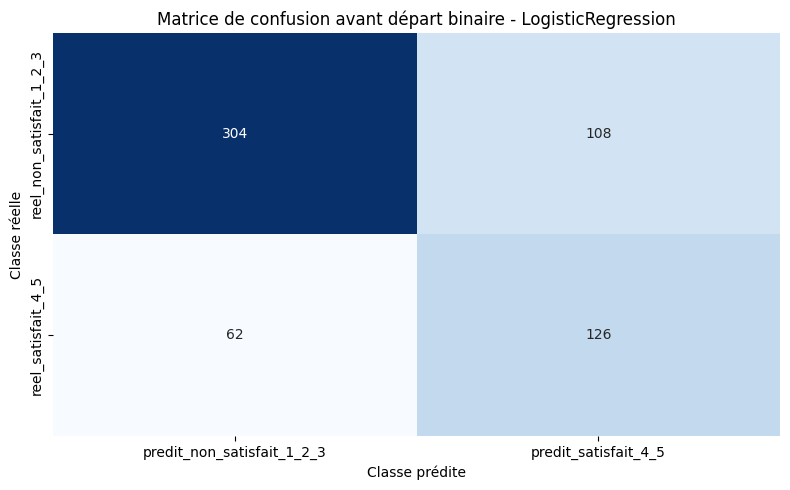

In [19]:
# Matrice de confusion du modèle `LogisticRegression`.
best_pre_pipeline = fitted_pre[best_pre_model_name]
y_pred_pre = best_pre_pipeline.predict(X_test_pre)

labels_pre = sorted(y_pre.unique())
labels_pre_names = [labels_satisfaction_pre[label] for label in labels_pre]

confusion_array_pre = confusion_matrix(y_test_pre, y_pred_pre, labels=labels_pre)
confusion_pre = pd.DataFrame(
    confusion_array_pre,
    index=[f"reel_{label}" for label in labels_pre_names],
    columns=[f"predit_{label}" for label in labels_pre_names],
)

print("Matrice de confusion avant départ binaire : lignes = réel, colonnes = prédit")
display(confusion_pre)

# Lecture métier de la matrice binaire.
# Classe 0 = non satisfait, classe 1 = satisfait.
tn_pre, fp_pre, fn_pre, tp_pre = confusion_array_pre.ravel()

lecture_confusion_pre = pd.DataFrame([
    {
        "type_resultat": "vrai négatif",
        "nombre": tn_pre,
        "interpretation": "Séjours non satisfaits correctement détectés",
    },
    {
        "type_resultat": "faux positif",
        "nombre": fp_pre,
        "interpretation": "Séjours prédits satisfaits alors qu'ils ne le sont pas",
    },
    {
        "type_resultat": "faux négatif",
        "nombre": fn_pre,
        "interpretation": "Séjours satisfaits non détectés par le modèle",
    },
    {
        "type_resultat": "vrai positif",
        "nombre": tp_pre,
        "interpretation": "Séjours satisfaits correctement détectés",
    },
])
display(lecture_confusion_pre)

def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0

precision_non_satisfait_pre = safe_divide(tn_pre, tn_pre + fn_pre)
recall_non_satisfait_pre = safe_divide(tn_pre, tn_pre + fp_pre)
precision_satisfait_pre = safe_divide(tp_pre, tp_pre + fp_pre)
recall_satisfait_pre = safe_divide(tp_pre, tp_pre + fn_pre)

metriques_par_classe_pre = pd.DataFrame([
    {
        "classe": 0,
        "libelle": labels_satisfaction_pre[0],
        "support": int(tn_pre + fp_pre),
        "precision": precision_non_satisfait_pre,
        "recall": recall_non_satisfait_pre,
        "f1": safe_divide(
            2 * precision_non_satisfait_pre * recall_non_satisfait_pre,
            precision_non_satisfait_pre + recall_non_satisfait_pre,
        ),
    },
    {
        "classe": 1,
        "libelle": labels_satisfaction_pre[1],
        "support": int(fn_pre + tp_pre),
        "precision": precision_satisfait_pre,
        "recall": recall_satisfait_pre,
        "f1": safe_divide(
            2 * precision_satisfait_pre * recall_satisfait_pre,
            precision_satisfait_pre + recall_satisfait_pre,
        ),
    },
])

display(metriques_par_classe_pre.round(4))

plt.figure(figsize=(8, 5))
sns.heatmap(
    confusion_pre,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion avant départ binaire - {best_pre_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()


Sur le jeu de test, le modèle `LogisticRegression` produit les résultats suivants :

- `304` séjours non satisfaits sont correctement détectés ;
- `126` séjours satisfaits sont correctement détectés ;
- `108` séjours sont prédits satisfaits alors qu'ils ne le sont pas ;
- `62` séjours satisfaits ne sont pas détectés par le modèle.

Le rappel par classe est donc exploitable :

- `recall_non_satisfait = 0.7379` : le modèle retrouve environ `74 %` des séjours non satisfaits ;
- `recall_satisfait = 0.6702` : le modèle retrouve environ `67 %` des séjours satisfaits.

Conclusion : la matrice de confusion confirme que le modèle apprend un signal utile, mais ses erreurs restent importantes. Les faux positifs sont le risque principal : un séjour peut être annoncé comme satisfaisant alors qu'il ne l'est pas réellement. Le modèle doit donc rester un outil d'aide à la priorisation, avec affichage des probabilités et revue humaine.


#### 4.7 Diagnostic overfitting / underfitting avant départ

Ce diagnostic compare les performances sur le train, le test et la validation croisée.

- Overfitting : score train nettement supérieur au score test.
- Underfitting : scores train et test faibles, proches de la baseline.
- Généralisation acceptable : écart train/test limité et gain clair face à la baseline.


In [20]:
# Diagnostic overfitting / underfitting du modèle `LogisticRegression`.
y_pred_train_pre = best_pre_pipeline.predict(X_train_pre)
y_pred_test_pre = best_pre_pipeline.predict(X_test_pre)

metrics_overfit_pre = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_pre, y_pred_train_pre),
        "balanced_accuracy": balanced_accuracy_score(y_train_pre, y_pred_train_pre),
        "macro_f1": f1_score(y_train_pre, y_pred_train_pre, average="macro"),
        "recall_satisfait": recall_score(y_train_pre, y_pred_train_pre, pos_label=1, zero_division=0),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_pre, y_pred_test_pre),
        "balanced_accuracy": balanced_accuracy_score(y_test_pre, y_pred_test_pre),
        "macro_f1": f1_score(y_test_pre, y_pred_test_pre, average="macro"),
        "recall_satisfait": recall_score(y_test_pre, y_pred_test_pre, pos_label=1, zero_division=0),
    },
    {
        "jeu": "validation_croisee_moyenne",
        "accuracy": cv_summary_pre.loc[cv_summary_pre["metrique"] == "accuracy", "moyenne"].iloc[0],
        "balanced_accuracy": cv_summary_pre.loc[cv_summary_pre["metrique"] == "balanced_accuracy", "moyenne"].iloc[0],
        "macro_f1": cv_summary_pre.loc[cv_summary_pre["metrique"] == "macro_f1", "moyenne"].iloc[0],
        "recall_satisfait": cv_summary_pre.loc[cv_summary_pre["metrique"] == "recall_satisfait", "moyenne"].iloc[0],
    },
])

dummy_macro_f1_pre = results_pre.loc[
    results_pre["modele"] == "DummyClassifier",
    "macro_f1",
].iloc[0]

gap_train_test_pre = (
    metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "train", "macro_f1"].iloc[0]
    - metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "test", "macro_f1"].iloc[0]
)

gain_vs_dummy_pre = (
    metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "test", "macro_f1"].iloc[0]
    - dummy_macro_f1_pre
)

diagnostic_underfit_pre = pd.DataFrame([{
    "macro_f1_train": metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "train", "macro_f1"].iloc[0],
    "macro_f1_test": metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "test", "macro_f1"].iloc[0],
    "macro_f1_validation_croisee": metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "validation_croisee_moyenne", "macro_f1"].iloc[0],
    "macro_f1_baseline_dummy": dummy_macro_f1_pre,
    "ecart_train_test": gap_train_test_pre,
    "gain_vs_baseline": gain_vs_dummy_pre,
}])

display(metrics_overfit_pre.round(4))
display(diagnostic_underfit_pre.round(4))

if gap_train_test_pre > 0.15:
    conclusion_overfit_pre = "risque d'overfitting élevé"
elif gap_train_test_pre > 0.07:
    conclusion_overfit_pre = "risque d'overfitting modéré"
else:
    conclusion_overfit_pre = "pas de signe fort d'overfitting"

if gain_vs_dummy_pre < 0.05:
    conclusion_underfit_pre = "gain faible face à la baseline : risque d'underfitting ou signal avant départ limité"
else:
    conclusion_underfit_pre = "gain mesurable face à la baseline"

print("Conclusion overfitting :", conclusion_overfit_pre)
print("Conclusion underfitting :", conclusion_underfit_pre)


,jeu,accuracy,balanced_accuracy,macro_f1,recall_satisfait
0,train,0.7262,0.7250,0.7042,0.7215
1,test,0.7167,0.7040,0.6893,0.6702
2,validation_croisee_moyenne,0.6833,0.6817,0.6577,0.6773


,macro_f1_train,macro_f1_test,macro_f1_validation_croisee,macro_f1_baseline_dummy,ecart_train_test,gain_vs_baseline
0,0.7042,0.6893,0.6577,0.4071,0.0149,0.2822


Conclusion overfitting : pas de signe fort d'overfitting
Conclusion underfitting : gain mesurable face à la baseline


Le diagnostic compare le comportement du modèle `LogisticRegression` sur l'entraînement, le test et la validation croisée.

Résultats observés :

- `macro_f1_train = 0.7042` ;
- `macro_f1_test = 0.6893` ;
- `macro_f1_validation_croisée = 0.6577` ;
- écart train/test = `0.0149` ;
- gain face à la baseline `DummyClassifier` = `0.2822`.

Conclusion : il n'y a pas de signe fort d'overfitting, car l'écart train/test reste faible. Il n'y a pas non plus d'underfitting majeur, car le modèle dépasse nettement la baseline. 

### 4.8 Tests sur quelques voyages types 

Cette section illustre l'utilisation concrète du modèle `LogisticRegression`.

Les exemples correspondent à des propositions de séjours fictives, saisissables avant le départ. Ils ne contiennent aucune information connue pendant ou après le voyage : `imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` sont laissés vides afin d'éviter toute fuite de données.

L'objectif n'est pas de valider la performance du modèle, mais de vérifier son comportement sur des cas métiers lisibles et de montrer comment l'API ou un conseiller peuvent comparer plusieurs options avant le départ.


In [21]:
# Création de voyages fictifs pour tester le comportement du modèle `LogisticRegression`.
# Ces lignes representent des cas lisibles par le métier, pas un vrai jeu de validation.
voyages_types_pre = pd.DataFrame([
    {
        "scenario": "Couple culture Europe budget confortable",
        "trip_id": 9001,
        "client_type": "couple",
        "budget_total": 4200,
        "destination": "rome",
        "saison": "printemps",
        "duree_jours": 7,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 650,
        "meteo_prevue": "ensoleill\u00e9",
        "activite_principale": "culture",
    },
    {
        "scenario": "Famille plage budget tendu",
        "trip_id": 9002,
        "client_type": "famille",
        "budget_total": 3600,
        "destination": "bali",
        "saison": "\u00e9t\u00e9",
        "duree_jours": 14,
        "type_hebergement": "resort",
        "prix_vol": 2200,
        "meteo_prevue": "variable",
        "activite_principale": "plage",
    },
    {
        "scenario": "Business court sejour urbain",
        "trip_id": 9003,
        "client_type": "business",
        "budget_total": 5200,
        "destination": "new york",
        "saison": "automne",
        "duree_jours": 4,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 1450,
        "meteo_prevue": "nuageux",
        "activite_principale": "business",
    },
    {
        "scenario": "Senior randonnee meteo risquee",
        "trip_id": 9004,
        "client_type": "senior",
        "budget_total": 2800,
        "destination": "lisbonne",
        "saison": "hiver",
        "duree_jours": 6,
        "type_hebergement": "appartement",
        "prix_vol": 420,
        "meteo_prevue": "pluie",
        "activite_principale": "randonn\u00e9e",
    },
])

# Colonnes connues uniquement pendant ou après le séjour : laissées vides pour respecter le cas avant départ.
for column in ["satisfaction_client", "imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]:
    voyages_types_pre[column] = np.nan

# Recalculer les mêmes features que sur le dataset d'entraînement.
voyages_types_pre_features = ajouter_features_base(voyages_types_pre)

# Réordonner les colonnes pour respecter exactement l'entrée du pipeline entraîné.
X_voyages_types_pre = voyages_types_pre_features.reindex(columns=feature_columns_pre)

# Appliquer le modèle `LogisticRegression` identifié plus haut.
best_pre_pipeline = fitted_pre[best_pre_model_name]
predictions_voyages_types_pre = best_pre_pipeline.predict(X_voyages_types_pre)

resultats_voyages_types_pre = voyages_types_pre[[
    "scenario",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
]].copy()

resultats_voyages_types_pre["classe_predite"] = predictions_voyages_types_pre
resultats_voyages_types_pre["libelle_prediction"] = resultats_voyages_types_pre["classe_predite"].map(libelles_satisfaction_binaire)

# Si le modèle fournit des probabilités, elles sont affichées pour évaluer la confiance.
if hasattr(best_pre_pipeline, "predict_proba"):
    probabilités_pre = best_pre_pipeline.predict_proba(X_voyages_types_pre)
    for class_index, class_label in enumerate(best_pre_pipeline.classes_):
        libelle_classe = libelles_satisfaction_binaire.get(class_label, str(class_label))
        resultats_voyages_types_pre[f"proba_{libelle_classe}"] = probabilités_pre[:, class_index].round(3)

print("Modèle `LogisticRegression` testé :", best_pre_model_name)
display(resultats_voyages_types_pre)


Modèle `LogisticRegression` testé : LogisticRegression


,scenario,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,meteo_prevue,activite_principale,classe_predite,libelle_prediction,proba_non_satisfait_1_2_3,proba_satisfait_4_5
0,Couple culture Europe budget confortable,couple,rome,printemps,7,hôtel,4200,650,ensoleillé,culture,0,non_satisfait_1_2_3,0.576,0.424
1,Famille plage budget tendu,famille,bali,été,14,resort,3600,2200,variable,plage,0,non_satisfait_1_2_3,0.731,0.269
2,Business court sejour urbain,business,new york,automne,4,hôtel,5200,1450,nuageux,business,0,non_satisfait_1_2_3,0.784,0.216
3,Senior randonnee meteo risquee,senior,lisbonne,hiver,6,appartement,2800,420,pluie,randonnée,0,non_satisfait_1_2_3,0.847,0.153


La cellule précédente applique le modèle retenu courant (`best_pre_model_name`) sur quatre voyages fictifs.

Les prédictions doivent être interprétées comme des scores indicatifs, pas comme des décisions automatiques. La sortie de classification indique si le séjour est plutôt classé `non_satisfait_1_2_3` ou `satisfait_4_5`, avec les probabilités associées.

#### Lecture attendue

Pour chaque scénario, il faut lire :

- la classe prédite ;
- la probabilité `non_satisfait_1_2_3` ;
- la probabilité `satisfait_4_5` ;
- le niveau de confiance, c'est-à-dire la probabilité maximale.

Si les deux probabilités sont proches, la prédiction est incertaine et doit être revue par un conseiller. Si la probabilité `satisfait_4_5` est élevée, le séjour semble avoir un meilleur potentiel de satisfaction, sans garantie automatique.

#### Conclusion 
Ces tests servent à vérifier quatre points :

- le pipeline accepte de nouvelles lignes au format avant départ ;
- les variables après séjour restent absentes ou vides ;
- les features dérivées sont recalculées de façon cohérente ;
- les probabilités par classe permettent d'évaluer le niveau de confiance.


### 4.9 Annexe exploratoire NLP sur `retour_client`

Cette annexe concerne l'analyse NLP. Elle est volontairement séparée du choix du modèle retenu : `retour_client` est disponible après le séjour, donc il ne peut pas être utilisé pour prédire la satisfaction avant le départ sans créer une fuite de données.

Objectif de cette annexe : montrer comment les avis clients peuvent alimenter l'amélioration continue après séjour.

Variables descriptives produites :

- `score_avis` : score de sentiment extrait du texte ;
- `sentiment_avis` / `sentiment_avis_label` : sentiment simplifié (`negatif`, `neutre`, `positif`) ;
- colonnes textuelles exploratoires : `tokens`, `mots_utiles`, `mots_propres`, `mots_cles`, `entites`.

Conclusion attendue : le NLP est utile pour comprendre les motifs de satisfaction ou d'insatisfaction après voyage, mais il n'est pas intégré au modèle `LogisticRegression` industrialisé.


In [22]:
# NLP exploratoire après séjour.

# Paramètre d'exécution : mettre False pour ne pas lancer les traitements NLP.
# Utile si les modèles NLP ne sont pas installés ou si l'exécution est trop longue.
EXECUTER_NLP = True

# Modèle spaCy utilisé pour les traitements linguistiques en français :
# tokenisation, stop words, lemmatisation, POS tagging et entités nommées.
# `fr_core_news_sm` est plus léger ; `fr_core_news_lg` peut être plus précis mais plus lourd.
SPACY_MODEL_NAME = "fr_core_news_sm"  # remplacer par "fr_core_news_lg" si installé

# Liste de modèles de sentiment testés dans l'ordre.
# Le premier disponible est chargé ; si aucun n'est disponible, le score neutre sera appliqué.
SENTIMENT_MODEL_CANDIDATS = [
    "cmarkea/distilcamembert-base-sentiment",
    "nlptown/bert-base-multilingual-uncased-sentiment",
]


def charger_spacy(model_name: str):
    # Vérifier que la bibliothèque spaCy est bien installée.
    if spacy is None:
        raise ImportError("La dépendance spaCy n'est pas installée.")

    try:
        # Charger le modèle linguistique demandé.
        return spacy.load(model_name), model_name, None
    except OSError as exc:
        # Si le modèle français n'est pas installé, utiliser un fallback minimal.
        # Ce fallback permet la tokenisation, mais il est moins riche pour les lemmes, POS et entités.
        return spacy.blank("fr"), "spacy_blank_fr", str(exc)


def charger_analyseur_sentiment(model_names: list[str]):
    # Stocker les erreurs de chargement pour documenter pourquoi un modèle n'a pas été utilisé.
    erreurs = {}

    # Vérifier que la bibliothèque transformers est disponible.
    if transformers_pipeline is None:
        erreurs["transformers"] = "La dépendance transformers n'est pas installée."
        return None, None, erreurs

    # Tester les modèles candidats un par un et retenir le premier qui fonctionne.
    for model_name in model_names:
        try:
            analyseur = transformers_pipeline(
                "sentiment-analysis",
                model=model_name,
                tokenizer=model_name,
            )
            return analyseur, model_name, erreurs
        except Exception as exc:
            erreurs[model_name] = str(exc)

    # Si aucun modèle ne charge correctement, la suite utilisera un sentiment neutre par défaut.
    return None, None, erreurs


def normaliser_label_sentiment(label: str, score: float) -> tuple[float, str]:
    # Les modèles de sentiment ne retournent pas tous les mêmes libellés.
    # Cette fonction convertit les sorties possibles en trois classes standard :
    # négatif, neutre, positif, avec un score numérique associé.
    label_normalise = str(label).strip().lower()

    # Cas positifs : score conservé en positif.
    if label_normalise in {"4 stars", "5 stars", "positive", "positif", "label_2"}:
        return round(float(score), 2), "positif"

    # Cas négatifs : score converti en valeur négative.
    if label_normalise in {"1 star", "2 stars", "negative", "negatif", "label_0"}:
        return round(-float(score), 2), "negatif"

    # Cas neutres : score remis à 0 pour faciliter l'interprétation.
    if label_normalise in {"3 stars", "neutral", "neutre", "label_1"}:
        return 0.0, "neutre"

    # Certains modèles retournent des labels numériques plus larges.
    if label_normalise in {"label_4", "label_3"}:
        return round(float(score), 2), "positif"

    # Par sécurité, tout label inconnu est considéré comme neutre.
    return 0.0, "neutre"


def creer_fonctions_nlp(nlp, analyseur):
    # Regrouper les fonctions NLP dans une fabrique permet d'utiliser les modèles chargés
    # sans les recharger à chaque appel.

    def etape1_tokenisation(texte):
        # Étape 1 : découper le commentaire en tokens/mots.
        # Objectif : voir la structure brute du texte client.
        doc = nlp(str(texte))
        return [token.text for token in doc]

    def etape2_mots_utiles(texte):
        # Étape 2 : retirer les stop words, ponctuations et espaces.
        # Objectif : conserver les mots plus informatifs pour comprendre le retour client.
        doc = nlp(str(texte))
        return [
            token.text
            for token in doc
            if not token.is_stop and not token.is_punct and not token.is_space
        ]

    def etape3_lemmatisation(texte):
        # Étape 3 : ramener les mots à leur forme de base.
        # Exemple : "satisfaits" peut être ramené vers "satisfait" selon le modèle spaCy.
        # Objectif : regrouper les variantes d'un même mot.
        doc = nlp(str(texte))
        lemmes = [token.lemma_ if token.lemma_ else token.text for token in doc]
        return " ".join(lemmes)

    def etape4_mots_cles(texte):
        # Étape 4 : extraire les adjectifs, noms et noms propres.
        # Objectif : identifiér les termes porteurs de thèmes ou d'opinion.
        doc = nlp(str(texte))
        return [token.text for token in doc if token.pos_ in ["ADJ", "NOUN", "PROPN"]]

    def etape5_entites(texte):
        # Étape 5 : détecter les entités nommées.
        # Objectif : repérer d'éventuels lieux, organisations ou noms cités dans les avis.
        doc = nlp(str(texte))
        return [ent.text for ent in doc.ents]

    def etape6_sentiment(texte):
        # Étape 6 : calculer un sentiment à partir du commentaire.
        # Un texte vide ou l'absence de modèle de sentiment renvoie un sentiment neutre.
        texte = str(texte).strip()
        if texte == "" or analyseur is None:
            return 0.0, "neutre"
        try:
            # `truncation=True` évite les erreurs si un texte dépasse la longueur maximale du modèle.
            resultat = analyseur(texte, truncation=True, max_length=512)[0]
            return normaliser_label_sentiment(resultat.get("label"), resultat.get("score", 0.0))
        except Exception:
            # En cas d'erreur ponctuelle sur un commentaire, on renvoie neutre pour ne pas bloquer le notebook.
            return 0.0, "neutre"

    # Retourner les six fonctions afin de les appliquer ensuite à la colonne `retour_client`.
    return (
        etape1_tokenisation,
        etape2_mots_utiles,
        etape3_lemmatisation,
        etape4_mots_cles,
        etape5_entites,
        etape6_sentiment,
    )


if not EXECUTER_NLP:
    # Permet de garder la cellule dans le notebook sans l'exécuter systématiquement.
    print("NLP non exécuté. Passer EXECUTER_NLP = True pour lancer l'analyse.")
else:
    try:
        # Charger spaCy pour les traitements linguistiques.
        nlp, spacy_model_loaded, spacy_warning = charger_spacy(SPACY_MODEL_NAME)

        # Charger le modèle de sentiment disponible parmi les candidats.
        analyseur, sentiment_model_loaded, sentiment_errors = charger_analyseur_sentiment(
            SENTIMENT_MODEL_CANDIDATS
        )

        # Informer si spaCy fonctionne en mode fallback minimal.
        if spacy_warning:
            print("Modèle spaCy demandé indisponible. Fallback utilisé : spacy.blank('fr').")

        # Informer si aucun modèle de sentiment n'a pu être chargé.
        if analyseur is None:
            print("Aucun modèle de sentiment chargé. Score neutre appliqué par défaut.")
            print(sentiment_errors)

        # Créer les six fonctions NLP à partir des modèles chargés.
        (
            etape1_tokenisation,
            etape2_mots_utiles,
            etape3_lemmatisation,
            etape4_mots_cles,
            etape5_entites,
            etape6_sentiment,
        ) = creer_fonctions_nlp(nlp, analyseur)

        # Copier le dataset de modélisation pour ne pas modifier `df_model` directement.
        df_nlp = df_model.copy()

        # Sécuriser la colonne texte : valeur manquante -> chaîne vide, puis conversion en texte.
        df_nlp["retour_client"] = df_nlp["retour_client"].fillna("").astype(str)

        # Appliquer les étapes linguistiques exploratoires sur chaque commentaire.
        df_nlp["tokens"] = df_nlp["retour_client"].apply(etape1_tokenisation)
        df_nlp["mots_utiles"] = df_nlp["retour_client"].apply(etape2_mots_utiles)
        df_nlp["mots_propres"] = df_nlp["retour_client"].apply(etape3_lemmatisation)
        df_nlp["mots_cles"] = df_nlp["retour_client"].apply(etape4_mots_cles)
        df_nlp["entites"] = df_nlp["retour_client"].apply(etape5_entites)

        # Calculer le sentiment sous forme de tuple : (score numérique, label texte).
        sentiments = df_nlp["retour_client"].apply(etape6_sentiment)

        # Extraire le score de sentiment : négatif < 0, neutre = 0, positif > 0.
        df_nlp["score_avis"] = sentiments.apply(lambda item: item[0])

        # Extraire le label de sentiment lisible : negatif, neutre ou positif.
        df_nlp["sentiment_avis_label"] = sentiments.apply(lambda item: item[1])

        # Encoder le sentiment en entier pour pouvoir l'utiliser dans une expérience de modélisation.
        mapping_sentiment = {"negatif": 0, "neutre": 1, "positif": 2}
        df_nlp["sentiment_avis"] = df_nlp["sentiment_avis_label"].map(mapping_sentiment)

        # Afficher les modèles effectivement chargés afin de garder une trace reproductible.
        print(f"Modèle spaCy chargé : {spacy_model_loaded}")
        print(f"Modèle sentiment chargé : {sentiment_model_loaded}")
        print("NLP terminé")

        # Préparer un tableau de contrôle pour inspecter les sorties NLP.
        colonnes_affichage_nlp = [
            "retour_client",
            "tokens",
            "mots_utiles",
            "mots_propres",
            "mots_cles",
            "entites",
            "score_avis",
            "sentiment_avis_label",
            "sentiment_avis",
        ]
        affichage_nlp = df_nlp[colonnes_affichage_nlp].copy()

        # Convertir les listes en chaînes lisibles uniquement pour l'affichage.
        # Les colonnes originales dans `df_nlp` restent inchangées.
        for column in ["tokens", "mots_utiles", "mots_cles", "entites"]:
            affichage_nlp[column] = affichage_nlp[column].apply(
                lambda value: ", ".join(map(str, value)) if isinstance(value, list) else value
            )

        # Afficher un extrait d'avis uniques pour contrôler rapidement la cohérence des résultats NLP.
        display(affichage_nlp.drop_duplicates().head(20))

    except ImportError as exc:
        # Message explicite si les dépendances NLP ne sont pas installées.
        print("Dépendances NLP non installées.")
        print("Installer : pip install -r requirements-nlp.txt")
        print(exc)


Device set to use cpu


Modèle spaCy chargé : fr_core_news_sm
Modèle sentiment chargé : cmarkea/distilcamembert-base-sentiment
NLP terminé


,retour_client,tokens,mots_utiles,mots_propres,mots_cles,entites,score_avis,sentiment_avis_label,sentiment_avis
0,séjour mitigé.,"séjour, mitigé, .","séjour, mitigé",séjour mitigé .,mitigé,,0.00,neutre,1
1,excellent séjour.,"excellent, séjour, .","excellent, séjour",excellent séjour .,,,0.57,positif,2
726,de nombreux problèmes rencontrés.,"de, nombreux, problèmes, rencontrés, .","problèmes, rencontrés",de nombreux problème rencontrer .,"nombreux, problèmes",,0.00,neutre,1
727,très mauvaise expérience.,"très, mauvaise, expérience, .","mauvaise, expérience",très mauvais expérience .,"mauvaise, expérience",,-0.80,negatif,0
729,dans l'ensemble satisfaisant.,"dans, l', ensemble, satisfaisant, .","ensemble, satisfaisant",dans le ensemble satisfaisant .,"ensemble, satisfaisant",,0.00,neutre,1
732,"parfait, rien à redire.","parfait, ,, rien, à, redire, .","parfait, rien, redire","parfaire , rien à redire .",,,0.84,positif,2
733,une expérience inoubliable.,"une, expérience, inoubliable, .","expérience, inoubliable",un expérience inoubliable .,"expérience, inoubliable",,0.81,positif,2
737,je ne recommande pas.,"je, ne, recommande, pas, .",recommande,je ne recommander pas .,,,-0.51,negatif,0
738,très bon rapport qualité-prix.,"très, bon, rapport, qualité, -, prix, .","bon, rapport, qualité, prix",très bon rapport qualité - prix .,"bon, rapport, qualité, -, prix",,0.53,positif,2
739,"quelques imprévus, globalement bien.","quelques, imprévus, ,, globalement, bien, .","imprévus, globalement, bien","quelque imprévu , globalement bien .",imprévus,,0.49,positif,2


In [23]:
# Affichage synthétique du sentiment détecté pour chaque retour client.
# Objectif : contrôler rapidement la cohérence entre le texte libre et le label NLP.
if "df_nlp" not in globals():
    print("Affichage impossible : exécuter d'abord la cellule NLP exploratoire.")
elif not {"retour_client", "sentiment_avis_label"}.issubset(df_nlp.columns):
    print("Affichage impossible : colonnes NLP manquantes dans df_nlp.")
else:
    affichage_sentiment_retours = (
        df_nlp[["retour_client", "sentiment_avis_label"]]
        .drop_duplicates()
        .sort_values(["sentiment_avis_label", "retour_client"])
        .reset_index(drop=True)
    )
    display(affichage_sentiment_retours)

,retour_client,sentiment_avis_label
0,déçu par l'organisation.,negatif
1,je ne recommande pas.,negatif
2,sejour decevant.,negatif
3,tres mauvaise experience.,negatif
4,très mauvaise expérience.,negatif
5,à éviter.,negatif
6,,neutre
7,dans l'ensemble satisfaisant.,neutre
8,de nombreux problèmes rencontrés.,neutre
9,peut mieux faire sur la logistique.,neutre


#### Lecture synthétique des résultats NLP

Les résultats NLP permettent de relier les commentaires clients à un sentiment global : les avis clairement positifs comme `excellent séjour` ou `très satisfait` sont classés positifs, les avis comme `très mauvaise expérience` ou `je ne recommande pas` sont classés négatifs, et les avis mitigés ou vides restent neutres.

Cette lecture confirme que le texte libre contient un signal fort sur le ressenti client. En revanche, ce signal arrive après le voyage : il sert donc à l'analyse qualitative et à l'amélioration continue, pas à la prédiction avant départ ni à l'API industrialisée.


In [24]:
# Synthèse descriptive NLP : aucune modélisation n est effectuée ici.
# Cette cellule sert uniquement à comprendre les retours clients après séjour.

colonnes_nlp_utiles = ["score_avis", "sentiment_avis", "sentiment_avis_label"]

if "df_nlp" not in globals():
    print(
        "Synthèse NLP non exécutée : la variable df_nlp n existe pas. "
        "Exécuter d abord la cellule NLP exploratoire ou installer requirements-nlp.txt."
    )
elif not set(colonnes_nlp_utiles).issubset(df_nlp.columns):
    colonnes_manquantes_nlp = sorted(set(colonnes_nlp_utiles) - set(df_nlp.columns))
    print("Synthèse NLP non exécutée : colonnes manquantes", colonnes_manquantes_nlp)
else:
    synthese_sentiments_nlp = (
        df_nlp["sentiment_avis_label"]
        .fillna("neutre")
        .value_counts(dropna=False)
        .rename_axis("sentiment")
        .reset_index(name="nombre")
    )
    synthese_sentiments_nlp["pourcentage"] = (
        synthese_sentiments_nlp["nombre"] / synthese_sentiments_nlp["nombre"].sum() * 100
    ).round(2)

    score_avis_resume = pd.DataFrame([
        {
            "indicateur": "score_avis",
            "minimum": round(float(df_nlp["score_avis"].min()), 4),
            "moyenne": round(float(df_nlp["score_avis"].mean()), 4),
            "maximum": round(float(df_nlp["score_avis"].max()), 4),
        }
    ])

    display(synthese_sentiments_nlp)
    display(score_avis_resume)

,sentiment,nombre,pourcentage
0,neutre,1217,40.57
1,positif,960,32.00
2,negatif,823,27.43


,indicateur,minimum,moyenne,maximum
0,score_avis,-0.9,0.0362,0.84


### 4.10 Traçabilité MLflow du modèle retenu

Cette section enregistre dans MLflow le modèle retenu `LogisticRegression`, ses métriques, ses paramètres et les informations utiles à la reproductibilité. Elle sert notamment à tracer le modèle final avant l'industrialisation.

In [25]:
# Traçabilité MLflow du modèle retenu industrialisé.
# On logge le pipeline sklearn complet : prétraitements + modèle.
mlflow_pre_model_name = best_pre_model_name
mlflow_pre_pipeline = fitted_pre[mlflow_pre_model_name]
mlflow_pre_row = results_pre[results_pre["modele"] == mlflow_pre_model_name].iloc[0]

with mlflow.start_run(run_name=f"travelmind_{mlflow_pre_model_name}"):
    mlflow.log_param("solution", "TravelMind")
    mlflow.log_param("objectif", "avant départ")
    mlflow.log_param("usage", "modele industrialise")
    mlflow.log_param("target", "satisfaction_client_binaire")
    mlflow.log_param("modele", mlflow_pre_model_name)
    mlflow.log_param("nb_features", len(feature_columns_pre))
    mlflow.log_param("features", ", ".join(feature_columns_pre))
    mlflow.log_param("train_rows", len(X_train_pre))
    mlflow.log_param("test_rows", len(X_test_pre))
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", RANDOM_STATE)

    mlflow.log_metric("accuracy", float(mlflow_pre_row["accuracy"]))
    mlflow.log_metric("balanced_accuracy", float(mlflow_pre_row["balanced_accuracy"]))
    mlflow.log_metric("macro_f1", float(mlflow_pre_row["macro_f1"]))

    mlflow.log_metric(
        "cv_accuracy_mean",
        float(cv_summary_pre.loc[cv_summary_pre["metrique"] == "accuracy", "moyenne"].iloc[0]),
    )
    mlflow.log_metric(
        "cv_balanced_accuracy_mean",
        float(cv_summary_pre.loc[cv_summary_pre["metrique"] == "balanced_accuracy", "moyenne"].iloc[0]),
    )
    mlflow.log_metric(
        "cv_macro_f1_mean",
        float(cv_summary_pre.loc[cv_summary_pre["metrique"] == "macro_f1", "moyenne"].iloc[0]),
    )

    if "gap_train_test_pre" in globals():
        mlflow.log_metric("gap_train_test_macro_f1", float(gap_train_test_pre))
    if "gain_vs_dummy_pre" in globals():
        mlflow.log_metric("gain_vs_dummy_macro_f1", float(gain_vs_dummy_pre))

    mlflow.log_dict(
        {
            "model_name": mlflow_pre_model_name,
            "objective": "travelmind_satisfaction_binaire",
            "class_labels": libelles_satisfaction_binaire,
            "feature_columns": feature_columns_pre,
            "metrics_test": {
                "accuracy": float(mlflow_pre_row["accuracy"]),
                "balanced_accuracy": float(mlflow_pre_row["balanced_accuracy"]),
                "macro_f1": float(mlflow_pre_row["macro_f1"]),
            },
        },
        "travelmind_model_metadata.json",
    )

    mlflow.sklearn.log_model(mlflow_pre_pipeline, "model_satisfaction")

print("Run MLflow avant départ enregistré")


2026/09/18 15:47:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/18 15:47:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow avant départ enregistré


## Partie 5 - Choix du modèle IA

Cette section formalise la décision finale de choix du modèle.

| Point | Choix retenu |
| --- | --- |
| Moment d'utilisation | Avant le départ |
| Objectif | Estimer si une proposition de séjour a un potentiel de satisfaction suffisant |
| Modèle industrialisé | `LogisticRegression` |
| Cible | `satisfaction_client` regroupée en 2 classes : `non_satisfait_1_2_3` et `satisfait_4_5` |
| Variables exclues | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |
| Usage attendu | Aide à la décision pour conseiller, jamais décision automatique |

#### Pourquoi ce modèle ?

`LogisticRegression` est retenu car il combine :

- le meilleur `macro_f1` parmi les modèles principaux (`0.6893`) ;
- une `balanced_accuracy` correcte (`0.7040`) ;
- une `ROC AUC` exploitable (`0.7303`) ;
- une meilleure lisibilité métier que les modèles d'arbres optimisés ;
- une industrialisation simple dans l'API et le pipeline `scikit-learn`.

Les autres essais sont conservés comme éléments de validation scientifique, mais ils ne justifient pas de changer le modèle final.


,metrique,valeur,interpretation
0,roc_auc_binaire,0.7303,AUC de la classe positive satisfait_4_5
1,classe_positive,1.0000,satisfait_4_5


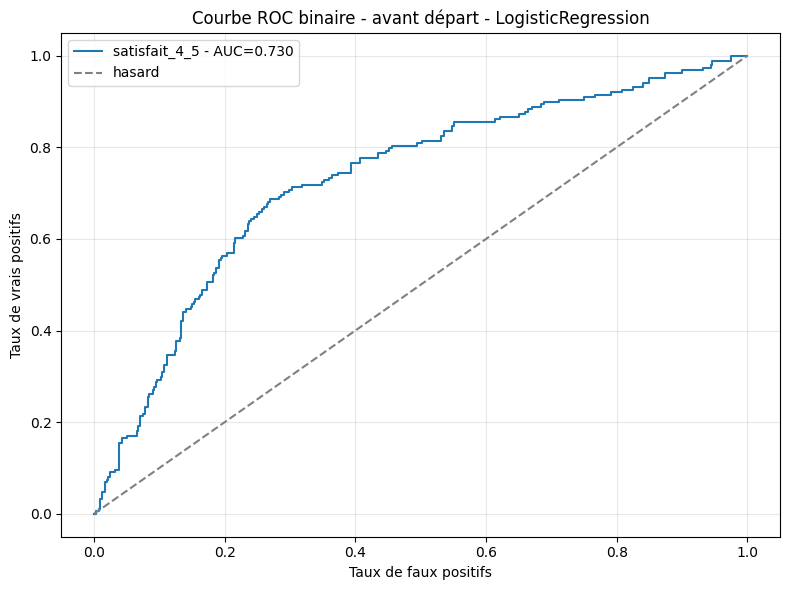

In [26]:
# Analyse ROC binaire du modèle retenu industrialisé.
# Le ROC complète accuracy / macro_f1 en évaluant la séparation probabiliste entre non satisfait et satisfait.
best_pre_pipeline = fitted_pre[best_pre_model_name]
labels_pre_roc = sorted(y_pre.unique())
labels_pre_readable = [libelles_satisfaction_binaire[label] for label in labels_pre_roc]

if hasattr(best_pre_pipeline, "predict_proba") and 1 in best_pre_pipeline.classes_:
    y_score_pre = best_pre_pipeline.predict_proba(X_test_pre)
    positive_class_index = list(best_pre_pipeline.classes_).index(1)
    y_score_satisfait_pre = y_score_pre[:, positive_class_index]

    roc_auc_binary_pre = roc_auc_score(y_test_pre, y_score_satisfait_pre)
    fpr_pre, tpr_pre, thresholds_pre = roc_curve(y_test_pre, y_score_satisfait_pre)

    roc_auc_pre = pd.DataFrame([
        {
            "metrique": "roc_auc_binaire",
            "valeur": roc_auc_binary_pre,
            "interpretation": "AUC de la classe positive satisfait_4_5",
        },
        {
            "metrique": "classe_positive",
            "valeur": 1,
            "interpretation": libelles_satisfaction_binaire[1],
        },
    ])
    display(roc_auc_pre.round(4))

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr_pre,
        tpr_pre,
        label=f"{libelles_satisfaction_binaire[1]} - AUC={roc_auc_binary_pre:.3f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="gray", label="hasard")
    plt.title(f"Courbe ROC binaire - avant départ - {best_pre_model_name}")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Le modèle retenu ne fournit pas predict_proba : ROC AUC non calculable.")


#### Eco-conception : temps d'inférence et sobriété du modèle

Ce bloc est séparé de l'analyse ROC pour distinguer la performance statistique du modèle et ses contraintes opérationnelles. Il mesure le temps d'inférence, le temps moyen d'entraînement observé en validation croisée et les éléments justifiant le choix d'un modèle tabulaire léger.


In [27]:
# Mesure simple du temps d'inférence sur le jeu de test avant départ.
start_time = time.perf_counter()
_ = best_pre_pipeline.predict(X_test_pre)
inference_time_seconds_pre = time.perf_counter() - start_time

performance_operationnelle_pre = pd.DataFrame([
    {
        "indicateur": "nb_lignes_test",
        "valeur": len(X_test_pre),
        "interpretation": "Volume utilisé pour mesurer l'inférence",
    },
    {
        "indicateur": "temps_inference_total_secondes",
        "valeur": inference_time_seconds_pre,
        "interpretation": "Temps total de prédiction sur le jeu de test avant départ",
    },
    {
        "indicateur": "temps_inference_moyen_ms_ligne",
        "valeur": inference_time_seconds_pre / len(X_test_pre) * 1000,
        "interpretation": "Temps moyen de prédiction par ligne",
    },
    {
        "indicateur": "cv_fit_time_moyen_secondes",
        "valeur": cv_results_pre["fit_time"].mean(),
        "interpretation": "Temps moyen d'entraînement observé en validation croisée",
    },
    {
        "indicateur": "cv_score_time_moyen_secondes",
        "valeur": cv_results_pre["score_time"].mean(),
        "interpretation": "Temps moyen d'Évaluation observé en validation croisée",
    },
])

display(performance_operationnelle_pre.round(6))

# Synthèse chiffrée des preuves d'éco-conception pour le modèle industrialisé.
fit_time_mean_pre = float(cv_results_pre["fit_time"].mean())
score_time_mean_pre = float(cv_results_pre["score_time"].mean())
inference_ms_ligne_pre = inference_time_seconds_pre / len(X_test_pre) * 1000

macro_f1_logreg_pre = float(
    results_pre.loc[results_pre["modele"] == "LogisticRegression", "macro_f1"].iloc[0]
)
macro_f1_rf_pre = float(
    results_pre.loc[results_pre["modele"] == "RandomForest", "macro_f1"].iloc[0]
)
gain_logreg_vs_rf_pre = macro_f1_logreg_pre - macro_f1_rf_pre

preuves_eco_conception_pre = pd.DataFrame([
    {
        "preuve": "Modèle industrialisé",
        "valeur_chiffree": best_pre_model_name,
        "interpretation": "Modèle simple retenu pour le deploiement avant départ binaire.",
    },
    {
        "preuve": "Nombre de variables d'entrée",
        "valeur_chiffree": len(feature_columns_pre),
        "interpretation": "Volume de variables limite, sans texte libre ni NLP dans le pipeline deploye.",
    },
    {
        "preuve": "Taille train / test",
        "valeur_chiffree": f"{len(X_train_pre)} / {len(X_test_pre)} lignes",
        "interpretation": "Prototype tabulaire de taille limitee.",
    },
    {
        "preuve": "Temps moyen d'entraînement CV",
        "valeur_chiffree": f"{fit_time_mean_pre:.4f} s",
        "interpretation": "Temps moyen de fit par fold en validation croisee.",
    },
    {
        "preuve": "Temps total d'inference test",
        "valeur_chiffree": f"{inference_time_seconds_pre:.4f} s",
        "interpretation": f"Prediction realisee sur {len(X_test_pre)} lignes de test.",
    },
    {
        "preuve": "Temps moyen d'inference par ligne",
        "valeur_chiffree": f"{inference_ms_ligne_pre:.4f} ms",
        "interpretation": "Inference compatible avec un usage API local leger.",
    },
    {
        "preuve": "Gain du modele simple vs RandomForest",
        "valeur_chiffree": f"{gain_logreg_vs_rf_pre:+.4f} macro_f1",
        "interpretation": "Le modele plus complexe doit justifier son cout par un gain clair en macro_f1.",
    },
    {
        "preuve": "NLP en production",
        "valeur_chiffree": "0 variable NLP",
        "interpretation": "`retour_client` et les features NLP sont exclus du modèle déployé.",
    },
])

display(preuves_eco_conception_pre)


,indicateur,valeur,interpretation
0,nb_lignes_test,600.000000,Volume utilisé pour mesurer l'inférence
1,temps_inference_total_secondes,0.067150,Temps total de prédiction sur le jeu de test a...
2,temps_inference_moyen_ms_ligne,0.111917,Temps moyen de prédiction par ligne
3,cv_fit_time_moyen_secondes,0.368120,Temps moyen d'entraînement observé en validati...
4,cv_score_time_moyen_secondes,0.308453,Temps moyen d'Évaluation observé en validation...


,preuve,valeur_chiffree,interpretation
0,Modèle industrialisé,LogisticRegression,Modèle simple retenu pour le deploiement avant...
1,Nombre de variables d'entrée,24,"Volume de variables limite, sans texte libre n..."
2,Taille train / test,2400 / 600 lignes,Prototype tabulaire de taille limitee.
3,Temps moyen d'entraînement CV,0.3681 s,Temps moyen de fit par fold en validation croi...
4,Temps total d'inference test,0.0672 s,Prediction realisee sur 600 lignes de test.
5,Temps moyen d'inference par ligne,0.1119 ms,Inference compatible avec un usage API local l...
6,Gain du modele simple vs RandomForest,+0.0213 macro_f1,Le modele plus complexe doit justifier son cou...
7,NLP en production,0 variable NLP,`retour_client` et les features NLP sont exclu...


Le tableau `preuves_eco_conception_pre` affiché juste au-dessus fournit les preuves numériques associées à la sobriété du modèle retenu industrialisé : temps moyen d'entraînement, temps d'inférence, nombre de variables, volume train/test, absence de NLP en production et comparaison avec `RandomForest`.

Ces valeurs justifient le choix d'un modèle simple : `LogisticRegression` est moins complexe, plus rapide à servir via API et plus pertinent que les modèles plus lourds au regard du `macro_f1`. Les chiffres doivent être recalculés si l'environnement d'exécution, les données ou le pipeline changent.

## Partie 6 - Entraînement supervisé du modèle IA

Cette partie ne recompare pas les modèles, car cette décision est déjà traitée en Partie 4. Elle documente uniquement comment le modèle retenu `LogisticRegression` est entraîné, validé et rendu reproductible.

#### Couverture synthétique 

| Elément | Traitement dans le projet | Décision / preuve |
| --- | --- | --- |
| Modèle entraîné automatiquement et supervisé | `Pipeline scikit-learn` ajusté avec `.fit(X_train_pre, y_train_pre)` | Apprentissage supervisé sur la cible binaire `non_satisfait_1_2_3` / `satisfait_4_5` |
| Optimisation proportionnée au contexte | Choix d’un modèle simple, `class_weight="balanced"`, comparaison avec baseline et `RandomForest` | Pas d’optimisation lourde retenue car absence de gain robuste et besoin d’un modèle explicable |
| Réentraînement | Non déclenché dans le notebook faute de nouvelles données réelles validées | Procédure prévue via `train.py` et quality gate avant promotion |
| Transfert de connaissances | Non applicable | Modèle tabulaire `scikit-learn`, sans poids pré-entraînés à transférer |
| Hyperparamètres décrits | Voir section `6.1` | `class_weight`, `max_iter`, `C`, `solver`, `penalty` documentés |
| Feature engineering | Réalisé en Partie 3 puis utilisé dans `X_pre` | Variables budget, vol, météo, activité/profil et potentiel de satisfaction |

#### Métriques du modèle retenu

Ces métriques sont reprises ici pour relier directement l'entraînement aux résultats du modèle retenu. L'interprétation détaillée reste documentée en Partie 4.

| Métrique | Résultat `LogisticRegression` | Rôle |
| --- | ---: | --- |
| `accuracy` | `0.7167` | Mesure globale des prédictions correctes. |
| `balanced_accuracy` | `0.7040` | Vérifie que les deux classes sont prises en compte. |
| `macro_f1` | `0.6893` | Métrique principale pour comparer les classes de manière équilibrée. |
| `precision_satisfait` | `0.5385` | Fiabilité des prédictions positives. |
| `recall_satisfait` | `0.6702` | Capacité à retrouver les séjours réellement satisfaisants. |
| `ROC AUC` | `0.7303` | Capacité probabiliste à séparer les deux classes. |
| `macro_f1` validation croisée | `0.6577` | Contrôle de stabilité sur plusieurs folds. |


Le modèle est entraîné de manière supervisée, reproductible et cohérente avec le cas d'usage. Les résultats justifient un prototype d'aide à la revue humaine, mais pas une décision automatique. Le réentraînement continu reste une étape future conditionnée à l'arrivée de données réelles, à une validation métier et à un contrôle technique.





### 6.1 Hyperparamètres et résumé d'entraînement

Cette cellule résume le modèle retenu `LogisticRegression`, son contexte d'entraînement et ses hyperparamètres utiles.

In [28]:
def extraire_hyperparametres_modele(model) -> dict:
    params = model.get_params()
    hyperparametres_utiles = [
        "max_iter",
        "class_weight",
        "C",
        "penalty",
        "solver",
        "random_state",
    ]
    return {key: params.get(key) for key in hyperparametres_utiles if key in params}


modele_retenu_pre = modeles_pre[best_pre_model_name]
hyperparametres_retenus_pre = extraire_hyperparametres_modele(modele_retenu_pre)

resume_entrainement_retenu_pre = pd.DataFrame([
    {"element": "modele retenu", "valeur": best_pre_model_name},
    {"element": "type apprentissage", "valeur": "supervise"},
    {"element": "probleme", "valeur": "classification binaire"},
    {"element": "taille train", "valeur": len(X_train_pre)},
    {"element": "taille test", "valeur": len(X_test_pre)},
    {"element": "nombre de variables entree", "valeur": len(feature_columns_pre)},
    {"element": "pipeline entraine", "valeur": "imputation + IQR + OneHotEncoder + StandardScaler + LogisticRegression"},
])

display(resume_entrainement_retenu_pre)

hyperparametres_logistic_regression_pre = pd.DataFrame([
    {
        "hyperparametre": "max_iter",
        "valeur": hyperparametres_retenus_pre.get("max_iter"),
        "role": "Nombre maximal d'iterations pour assurer la convergence du modele.",
    },
    {
        "hyperparametre": "class_weight",
        "valeur": hyperparametres_retenus_pre.get("class_weight"),
        "role": "Compense le desequilibre entre les classes non satisfait et satisfait.",
    },
    {
        "hyperparametre": "C",
        "valeur": hyperparametres_retenus_pre.get("C"),
        "role": "Controle la regularisation : plus C est faible, plus la regularisation est forte.",
    },
    {
        "hyperparametre": "penalty",
        "valeur": hyperparametres_retenus_pre.get("penalty"),
        "role": "Type de regularisation appliquee au modele.",
    },
    {
        "hyperparametre": "solver",
        "valeur": hyperparametres_retenus_pre.get("solver"),
        "role": "Algorithme numerique utilise pour optimiser la regression logistique.",
    },
])

display(hyperparametres_logistic_regression_pre)

print("Modele retenu entraine dans le pipeline :", best_pre_model_name)

,element,valeur
0,modele retenu,LogisticRegression
1,type apprentissage,supervise
2,probleme,classification binaire
3,taille train,2400
4,taille test,600
5,nombre de variables entree,24
6,pipeline entraine,imputation + IQR + OneHotEncoder + StandardSca...


,hyperparametre,valeur,role
0,max_iter,500,Nombre maximal d'iterations pour assurer la co...
1,class_weight,balanced,Compense le desequilibre entre les classes non...
2,C,1.0,Controle la regularisation : plus C est faible...
3,penalty,l2,Type de regularisation appliquee au modele.
4,solver,lbfgs,Algorithme numerique utilise pour optimiser la...


Modele retenu entraine dans le pipeline : LogisticRegression


### 6.2 Synthèse de l'entraînement supervisé

La partie 6 confirme que l'entraînement du modèle retenu est cohérent avec le besoin métier : le pipeline est supervisé, reproductible, limité aux variables disponibles avant le départ et protégé contre la fuite de données.

Les hyperparamètres retenus restent volontairement simples et explicables. Les essais plus complexes ne sont pas réintroduits ici, car ils n'ont pas apporté de gain suffisamment robuste par rapport à `LogisticRegression`.

Conclusion : le modèle est entraîné et validé pour un usage de prototype d'aide à la revue humaine. Le réentraînement continu n'est pas déclenché dans ce notebook ; il sera pertinent uniquement avec de nouvelles données réelles validées, puis après contrôle des performances et validation métier.


## Partie 7 - Implémentation et intégration technique

Cette section est centrée sur l'industrialisation du modèle retenu `LogisticRegression`, utilisé pour servir TravelMind.

#### Objectif de cette partie

Elle vise à transformer le travail réalisé dans le notebook en une première chaîne exploitable :

- entraînement reproductible hors notebook ;
- export du pipeline `sklearn` complet ;
- service de prédiction via API FastAPI ;
- interface web Streamlit pour tester des voyages manuellement ou par CSV ;
- journalisation des prédictions ;
- monitoring des prédictions, de la confiance et de la dérive ;
- validation automatique via CI/CD et quality gate.

#### Flux fonctionnel industrialisé

```text
[Dataset CSV versionné]
        |
        v
[train.py]
        |
        +--> Nettoyage métier strict
        +--> Feature engineering avant départ
        +--> Pipeline sklearn : imputation + outliers + encodage + normalisation + modèle
        |
        v
[Artefacts locaux models/]
        |
        +--> model_satisfaction.pkl
        +--> model_satisfaction_metadata.json
        |
        v
[API FastAPI TravelMind]
        |
        +--> /health
        +--> /predict
        +--> /monitoring/summary
        +--> /monitoring/drift
        +--> /monitoring/alerts
        |
        +--> [Interface Streamlit]
        |
        v
[Logs JSONL]
        |
        v
[Suivi KPI + alertes + décision de réentraînement]
```

#### Fichiers techniques et rôles

| Fichier / dossier | Rôle | Contenu principal |
| --- | --- | --- |
| `train.py` | Entraînement reproductible | Charge le dataset, applique la préparation, entraîne les modèles candidats avant départ, sélectionne le meilleur et exporte les artefacts. |
| `app/modeling.py` | Logique ML centralisée | Nettoyage, feature engineering, pipeline `sklearn`, comparaison des modèles et profil de référence d'entraînement. |
| `app/schemas.py` | Contrat API | Schémas Pydantic d'entrée et de sortie pour `/predict`. |
| `app/predictor.py` | Service de prédiction | Charge `model_satisfaction.pkl`, prépare les entrées et retourne classe, probabilités et confiance. |
| `app/main.py` | API TravelMind | Expose `/health`, `/predict`, `/monitoring/summary`, `/monitoring/drift` et `/monitoring/alerts`. |
| `app/monitoring.py` | Monitoring opérationnel | Journalise les prédictions, calcule les KPI d'usage, détecte la dérive et génère des alertes. |
| `app_web.py` | Interface web | Application Streamlit pour tester l'API, saisir un voyage, importer un CSV et consulter les KPI. |
| `scripts/check_model_quality.py` | Quality gate | Vérifie que les métriques du modèle exporté restent au-dessus des seuils attendus. |
| `configs/model_quality_gate.json` | Seuils qualité | Contient les seuils minimums, les métriques de référence et la baisse maximale autorisée. |
| `.github/workflows/ci-cd.yml` | CI/CD | Lance les tests, entraîne le modèle de CI, applique le quality gate, valide le notebook et construit l'image Docker. |
| `tests/` | Tests automatisés | Tests API, pipeline ML, monitoring et endpoints. |
| `Dockerfile` | Image API | Construit l'environnement d'exécution FastAPI. |
| `docker-compose.yml` | Conteneurisation locale | Expose l'API sur `localhost:8001` et monte `models/` et `logs/`. |
| `docs/strategie_reentraînement.md` | Gouvernance MLOps | Décrit les seuils de suivi, les alertes et les conditions de réentraînement. |

#### Artefacts générés localement

| Artefact | Généré par | Rôle | Versioning |
| --- | --- | --- | --- |
| `models/model_satisfaction.pkl` | `python train.py` | Pipeline complet utilisé par l'API `/predict`. | Non versionné dans Git. |
| `models/model_satisfaction_metadata.json` | `python train.py` | Métriques, classes, features et profil d'entraînement. | Non versionné dans Git. |
| `logs/predictions/predictions.jsonl` | Appels `/predict` | Historique des prédictions, entrées, probabilités et niveau de confiance. | Non versionné dans Git. |
| `mlruns/`, `mlartifacts/`, `mlflow.db` | MLflow local | Traçabilité locale des expériences. | Non versionné dans Git. |
| `logs/codecarbon/` | CodeCarbon | Estimation locale de l'empreinte carbone d'entraînement. | Non versionné dans Git. |

#### Modèle servi par l'API

| Élément | Valeur |
| --- | --- |
| Nom du projet | `TravelMind` |
| Objectif servi | Prédire avant le départ le risque de satisfaction client en binaire. |
| Modèle industrialisé | `LogisticRegression` |
| Type de sortie | Probabiliste : classe prédite + probabilité par classe. |
| Classes | `non_satisfait_1_2_3`, `satisfait_4_5` |
| Variables autorisées | Variables connues avant le séjour : profil client, budget, destination, saison, durée, hébergement, prix du vol, météo prévue, activité principale et features disponibles avant le départ dérivées. |
| Variables exclues | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` et features après séjour. |
| Justification | Ces variables sont connues pendant ou après le séjour ; les utiliser en avant départ créerait une fuite de données. |
| Usage recommandé | Aide à l'analyse pour le conseiller voyage, avec validation humaine. |
| Usage interdit | Refus automatique d'une offre, tarification individualisée injustifiée ou remplacement du conseiller. |

#### Interfaces locales

| Interface | URL locale | Usage |
| --- | --- | --- |
| API FastAPI | `http://localhost:8001` | Service de prédiction. |
| Health check | `http://localhost:8001/health` | Vérifier que l'API répond. |
| Documentation Swagger | `http://localhost:8001/docs` | Tester `/predict` et les endpoints de monitoring. |
| Interface web Streamlit | `http://localhost:8501` | Tester le modèle sans requête HTTP manuelle. |
| MLflow local | `http://127.0.0.1:5001` | Visualiser les runs si MLflow est lancé localement. |

#### Endpoints API

| Endpoint | Méthode | Rôle | Résultat attendu |
| --- | --- | --- | --- |
| `/health` | `GET` | Contrôle de disponibilité | `{"status": "ok"}` |
| `/predict` | `POST` | Prédiction avant départ | Classe, libellé, probabilités, confiance et métriques du modèle. |
| `/monitoring/summary` | `GET` | Synthèse des prédictions | Volume, distribution des classes, confiance moyenne et taux de faible confiance. |
| `/monitoring/drift` | `GET` | Détection de dérive | Écarts entre les entrées API et le profil d'entraînement. |
| `/monitoring/alerts` | `GET` | Décision opérationnelle | `collect_predictions`, `monitor_and_review`, `review_and_prepare_retraining` ou `no_action`. |

#### Commandes locales principales

| Action | Commande PowerShell | Objectif |
| --- | --- | --- |
| Installer les dépendances | `pip install -r requirements-dev.txt` | Préparer l'environnement local complet. |
| Entraîner et exporter | `python train.py` | Générer `models/model_satisfaction.pkl` et les métadonnées. |
| Lancer l'API | `uvicorn app.main:app --reload --port 8001` | Servir le modèle en local. |
| Lancer l'interface web | `python -m streamlit run app_web.py` | Tester le modèle via navigateur. |
| Lancer les tests | `python -m pytest -q` | Vérifier API, pipeline et monitoring. |
| Lire les logs | `Get-Content -Encoding UTF8 logs/predictions/predictions.jsonl -Tail 5` | Voir les dernières prédictions. |
| Lancer Docker | `docker compose up --build` | Démarrer l'API conteneurisée. |
| Lancer MLflow | `mlflow ui --host 127.0.0.1 --port 5001` | Visualiser les runs locaux. |

#### Exemple de requête `/predict`

```json
{
  "client_type": "couple",
  "budget_total": 4200,
  "destination": "rome",
  "saison": "printemps",
  "duree_jours": 7,
  "type_hebergement": "hôtel",
  "prix_vol": 650,
  "meteo_prevue": "ensoleillé",
  "activite_principale": "culture"
}
```

#### Exemple de réponse `/predict`

```json
{
  "objective": "travelmind_satisfaction_binaire",
  "model_name": "LogisticRegression",
  "classe_predite": 1,
  "libelle_prediction": "satisfait_4_5",
  "probabilities": [
    {"classe": 0, "libelle": "non_satisfait_1_2_3", "probabilite": 0.42},
    {"classe": 1, "libelle": "satisfait_4_5", "probabilite": 0.58}
  ],
  "model_metrics": {
    "accuracy": 0.7167,
    "balanced_accuracy": 0.7040,
    "macro_f1": 0.6893
  }
}
```

#### Quality gate CI/CD

Le quality gate vérifie que le modèle entraîné automatiquement reste compatible avec les exigences minimales du projet.

| Indicateur | Seuil minimum | Référence actuelle | Baisse maximale autorisée |
| --- | ---: | ---: | ---: |
| `accuracy` | `0.3000` | `0.7167` | `0.0600` |
| `balanced_accuracy` | `0.3000` | `0.7040` | `0.0600` |
| `macro_f1` | `0.3000` | `0.6893` | `0.0600` |
| `train_rows` | `1000` | Contrôlé dans les métadonnées | Non applicable |
| `test_rows` | `200` | Contrôlé dans les métadonnées | Non applicable |

#### CI/CD mise en place

| Étape | Rôle |
| --- | --- |
| Compilation Python | Détecter les erreurs de syntaxe dans `app/`, `tests/` et `train.py`. |
| Tests automatisés | Vérifier le comportement de l'API, du pipeline ML et du monitoring. |
| Entraînement CI | Reproduire l'entraînement avant départ dans l'environnement GitHub Actions. |
| Quality gate | Bloquer une version si les métriques chutent trop fortement. |
| Validation notebook | Parser les cellules code du notebook final pour détecter une erreur de syntaxe. |
| Build Docker | Vérifier que l'image API peut être construite. |

Cette CI/CD correspond à une livraison continue minimale : elle valide automatiquement le code, le modèle et le packaging. Elle ne réalise pas de déploiement continu automatique vers un serveur distant. Cette limite est acceptable pour le prototype TravelMind, car l'exploitation reste locale ; un déploiement serveur nécessiterait une cible d'hébergement validée, des secrets sécurisés, une stratégie de rollback et une validation DSI.

#### Monitoring en exploitation locale

Chaque appel à `/predict` ajoute une ligne JSON dans `logs/predictions/predictions.jsonl`.

| Indicateur suivi | Utilité |
| --- | --- |
| Volume de prédictions | Savoir si le monitoring repose sur assez d'observations. |
| Distribution des classes prédites | Détecter une concentration anormale sur une classe. |
| Confiance moyenne | Mesurer le degré d'incertitude du modèle. |
| Taux de faible confiance | Identifier les cas à revoir humainement. |
| Dérive numérique | Repérer des budgets, durées ou prix de vol différents du jeu d'entraînement. |
| Dérive catégorielle | Repérer de nouveaux profils, destinations ou usages surreprésentés. |

#### Conteneurisation Docker

| Élément | Rôle |
| --- | --- |
| `Dockerfile` | Construit l'image Python/FastAPI. |
| `docker-compose.yml` | Expose le service sur `localhost:8001`. |
| Volume `./models:/app/models:ro` | Fournit le modèle au conteneur en lecture seule. |
| Volume `./logs:/app/logs` | Conserve les logs hors du conteneur. |


#### Limites actuelles de l'industrialisation

- Le modèle retenu présente une performance correcte pour un prototype, mais insuffisante pour une décision automatique sans validation humaine.
- Le suivi de performance réelle nécessite de collecter ensuite la satisfaction observée après le voyage.
- Le réentraînement est documenté mais non automatique : il doit passer par une validation métier et technique.
- Les artefacts `models/`, `logs/`, `mlruns/` et `mlartifacts/` restent locaux et exclus de Git.
- La sécurisation production complète n'est pas incluse : authentification, gestion des droits, HTTPS, supervision serveur et sauvegardes restent à ajouter en cas de déploiement réel.


## Partie 8 - Évaluation de l'architecture cible

Cette section répond à la compétence C7 : proposer une architecture cible cohérente, proportionnée au besoin métier et aux contraintes du projet.

L'objectif consiste à passer d'un notebook exploratoire à un **prototype industrialisable localement**, capable de servir le modèle retenu `LogisticRegression`, de tracer les prédictions et de préparer une future généralisation.

#### Scénarios d'architecture étudiés

| Scénario | Décision | Justification |
| --- | --- | --- |
| Notebook seul | Écarté pour l'usage métier | Utile pour documenter et explorer, mais non adapté à une utilisation opérationnelle. |
| Script `train.py` + artefacts | Retenu | Rend l'entraînement reproductible et indépendant du notebook. |
| API FastAPI locale | Retenue | Sert le modèle via un endpoint clair et testable. |
| Interface Streamlit | Retenue | Facilite la démonstration métier sans compétence technique avancée. |
| Docker Compose | Retenu | Améliore la portabilité entre postes. |
| CI/CD GitHub Actions | Retenue | Sécurise les évolutions par tests, quality gate et build Docker. |

#### Logique d'architecture retenue

| Étape | Brique retenue | Rôle dans TravelMind |
| --- | --- | --- |
| 1. Données | Dataset versionné `dataset_final.csv` | Fournir une base stable et reproductible pour l'entraînement. |
| 2. Entraînement | `train.py` | Rejouer l'entraînement hors notebook et exporter le pipeline complet. |
| 3. Artefacts | `models/model_satisfaction.pkl` + métadonnées | Stocker le modèle, les variables, métriques et profils de référence. |
| 4. Service de prédiction | API FastAPI | Exposer `/health` et `/predict` pour utiliser le modèle hors notebook. |
| 5. Interface métier | Streamlit | Permettre à un conseiller de tester un voyage ou un fichier CSV. |
| 6. Suivi | Logs JSONL + endpoints monitoring | Suivre les prédictions, la confiance et les dérives. |
| 7. Qualité logicielle | GitHub Actions + tests + quality gate | Vérifier automatiquement le code, le modèle et le build Docker. |
| 8. Portabilité | Docker / Docker Compose | Lancer l'API dans un environnement reproductible. |

#### Flux cible retenu

![Architecture cible TravelMind](../docs/architecture_cible_travelmind.svg)

Le flux retenu est le suivant :

```text
Dataset versionné
-> entraînement reproductible avec train.py
-> export du pipeline sklearn et des métadonnées
-> service de prédiction via API FastAPI
-> test métier via Streamlit ou Swagger
-> journalisation des prédictions en JSONL
-> monitoring de la confiance et de la dérive
-> décision de revue humaine ou de réentraînement
```

#### Logique CI/CD appliquée au projet

La CI/CD est portée par GitHub Actions dans `.github/workflows/ci-cd.yml`. Elle se déclenche lors d'un `push`, d'une `pull_request` vers `main` ou d'un lancement manuel.

Le workflow commence par identifier les fichiers modifiés afin d'éviter de relancer inutilement toutes les étapes :

| Type de modification | Étapes déclenchées | Objectif |
| --- | --- | --- |
| Code applicatif `app/`, tests, scripts, `train.py`, configurations | Installation des dépendances, compilation Python, tests `pytest` | Vérifier que l'API, le pipeline et le monitoring restent fonctionnels. |
| Données, configuration modèle ou logique d'entraînement | Réentraînement CI, génération de métadonnées, quality gate | Bloquer une version dont les métriques se dégradent trop fortement. |
| Notebook final `notebooks/exam_ia_final.ipynb` | Validation JSON et syntaxe Python des cellules code | Vérifier que le notebook reste ouvrable et que ses cellules code sont syntaxiquement valides. |
| Dockerfile, `docker-compose.yml`, API ou dépendances production | Construction de l'image Docker | Vérifier que l'application reste conteneurisable. |
| Documentation seule | Étapes lourdes ignorées | Réduire le temps d'exécution et la charge CI/CD. |


La `quality gate` ne valide pas une mise en production métier. Elle sert uniquement de barrière technique : si les métriques du modèle exporté passent sous les seuils définis dans `configs/model_quality_gate.json`, la livraison échoue.

Le déploiement automatique sur serveur n'est pas activé dans ce prototype. La CI/CD valide donc le code, le notebook, le modèle et l'image Docker, mais la promotion vers un environnement distant reste une décision humaine.

#### Contraintes prises en compte

| Contrainte | Réponse architecturale |
| --- | --- |
| Performance modèle perfectible | Usage limité à l'aide à la revue humaine, avec probabilités et niveau de confiance. |
| Risque de fuite de données | Variables après séjour exclues du modèle industrialisé. |
| Reproductibilité | Données versionnées, `train.py`, pipeline `sklearn`, métadonnées modèle. |
| Portabilité | Environnement Python documenté et exécution possible via Docker. |
| Coût et sobriété | Modèle tabulaire léger, pas de NLP en production, infrastructure locale. |
| Suivi en exploitation | Logs JSONL, endpoints `/monitoring/summary`, `/monitoring/drift`, `/monitoring/alerts`. |
| Sécurité future | Validation DSI/DPO nécessaire avant données réelles ou exposition publique. |

#### Acteurs ressources et validation avant généralisation

Avant une généralisation, l'architecture devra être revue avec :

- le commanditaire métier, pour valider l'usage réel et les seuils d'alerte ;
- les conseillers voyage, pour vérifier l'utilisabilité de l'interface ;
- la DSI / équipe technique, pour valider hébergement, sécurité, sauvegardes et supervision ;
- le DPO / juridique, si des données clients réelles sont ajoutées.

#### Conclusion

L'architecture cible est structurée autour d'une chaîne complète : données -> entraînement -> artefacts -> API -> interface -> logs -> monitoring -> amélioration continue. Elle est proportionnée au niveau de maturité du projet et explicite les limites à lever avant généralisation.

## Partie 9 - Mesure de performance et impacts de la solution IA

Cette section répond à la compétence C8 : mesurer la performance, interpréter les impacts et définir les actions à déclencher pour maintenir TravelMind fonctionnel.

Elle se concentre sur le modèle retenu industrialisé `LogisticRegression`, servi par l'API.

### 9.1 Indicateurs de performance retenus

| Indicateur | Rôle | Résultat actuel | Interprétation |
| --- | --- | ---: | --- |
| `accuracy` | Part totale de prédictions correctes | `0.7167` | Environ 72 % des cas du test sont correctement classés. |
| `balanced_accuracy` | Moyenne des rappels des deux classes | `0.7040` | Le modèle ne se limite pas uniquement à la classe majoritaire. |
| `macro_f1` | Moyenne du F1-score des deux classes | `0.6893` | Métrique principale : compromis correct mais encore perfectible. |
| `precision_satisfait` | Fiabilité des prédictions `satisfait` | `0.5385` | Une prédiction positive reste incertaine et doit être relue. |
| `recall_satisfait` | Capacité à retrouver les séjours réellement satisfaisants | `0.6702` | Environ 67 % des séjours satisfaisants sont détectés. |
| `ROC AUC` | Séparation probabiliste des deux classes | `0.7303` | Séparation meilleure que le hasard, mais pas suffisante pour automatiser une décision. |
| Matrice de confusion | Analyse concrète des erreurs | `108` faux positifs, `62` faux négatifs | Les erreurs restent significatives et doivent être expliquées métier. |
| Validation croisée | Robustesse de la performance | `macro_f1` moyen `0.6577` | Confirme une performance utile mais modérée. |

### 9.2 Seuils de validation technique et métier

La CI/CD applique un quality gate pour éviter de livrer une version fortement dégradée du modèle. Ces seuils sont des garde-fous techniques, pas une autorisation de mise en production autonome.

| Indicateur | Seuil minimum CI/CD | Référence actuelle | Baisse maximale autorisée |
| --- | ---: | ---: | ---: |
| `accuracy` | `0.3000` | `0.7167` | `0.0600` |
| `balanced_accuracy` | `0.3000` | `0.7040` | `0.0600` |
| `macro_f1` | `0.3000` | `0.6893` | `0.0600` |

Des seuils métier complémentaires sont retenus pour interpréter l'usage opérationnel :

| Signal métier | Seuil d'alerte | Interprétation | Action |
| --- | ---: | --- | --- |
| `ROC AUC` | `< 0.70` | Séparation insuffisante entre les classes | Réévaluer le modèle et les variables. |
| `precision_satisfait` | `< 0.55` | Trop de séjours prédits satisfaits peuvent être en réalité non satisfaits | Ne pas utiliser la prédiction comme validation automatique. |
| Taux de faible confiance | `> 30 %` | Trop de prédictions incertaines | Renforcer la revue humaine et analyser les entrées. |

Ces seuils servent à décider si le modèle peut rester un outil d'aide à la revue humaine ou s'il doit être réanalysé avant tout usage opérationnel.


### 9.3 Lecture métier et décision d’usage

Les métriques montrent que le modèle apprend un signal réel : il dépasse nettement la baseline et obtient une ROC AUC supérieure à `0.70`. Cependant, les résultats ne sont pas assez fiables pour une décision automatique.

La précision de la classe `satisfait` reste limitée (`0.5385`) et la matrice de confusion montre `108` faux positifs : certains séjours seraient annoncés satisfaits alors qu'ils ne le sont pas réellement. L'impact métier principal est de sous-estimer une insatisfaction potentielle : le conseiller pourrait ne pas renforcer l'accompagnement, ne pas ajuster l'offre ou ne pas proposer d'alternative alors que le séjour présente un risque. Les `62` faux négatifs correspondent à l'effet inverse : certains séjours réellement satisfaisants seraient considérés à risque. L'impact métier est alors une vigilance excessive, avec un possible surtraitement du dossier, mais ce risque reste moins critique qu'une validation automatique trop optimiste.

Décision : TravelMind peut être utilisé comme **prototype d'aide à la revue humaine**, mais ne doit pas être mis en production autonome en l'état. Le conseiller doit garder la décision finale.

### 9.4 Performances par sous-groupes
La cellule suivante calcule les performances du modèle retenu par sous-groupes métier. Les résultats doivent être interprétés avec prudence lorsque le `support` est faible.

In [29]:
def évaluer_performance_sous_groupes(X_test, y_true, y_pred, colonnes_sous_groupes, min_support=20):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)
    labels_eval = sorted(y_true_eval.dropna().unique().tolist())

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        serie_sous_groupe = donnees_eval[colonne].fillna("valeur_manquante")
        serie_sous_groupe = serie_sous_groupe.map(
            lambda valeur: tuple(valeur) if isinstance(valeur, list) else valeur
        )
        for valeur, index_groupe in serie_sous_groupe.groupby(serie_sous_groupe).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]

            lignes.append({
                "sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "balanced_accuracy": balanced_accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_eval,
                    average="macro",
                    zero_division=0,
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


# Sous-groupes disponibles avant le départ : cohérents avec le modèle industrialisé.
colonnes_sous_groupes_model_card = [
    "client_type",
    "destination",
    "type_hebergement",
    "saison",
    "meteo_prevue",
    "activite_principale",
]

performances_sous_groupes_pre = évaluer_performance_sous_groupes(
    X_test_pre,
    y_test_pre,
    y_pred_pre,
    colonnes_sous_groupes_model_card,
    min_support=20,
)

display(performances_sous_groupes_pre.round(4))

,sous_groupe,valeur,support,accuracy,balanced_accuracy,macro_f1
0,activite_principale,gastronomie,94,0.7553,0.7439,0.7449
1,activite_principale,randonnée,72,0.7917,0.7214,0.7169
2,activite_principale,culture,170,0.6647,0.7197,0.6605
3,activite_principale,plage,147,0.6667,0.6621,0.6501
4,activite_principale,business,105,0.7810,0.6251,0.6379
5,client_type,couple,123,0.7398,0.7604,0.7384
6,client_type,senior,108,0.6944,0.6806,0.6707
7,client_type,business,146,0.8356,0.6506,0.6663
8,client_type,famille,97,0.6186,0.6402,0.6179
9,client_type,solo,126,0.6508,0.6198,0.6117


#### Lecture des performances par sous-groupes

Le modèle retenu `LogisticRegression` présente un `macro_f1` global de `0.6893`, mais la performance varie selon les segments métier.

Certains sous-groupes sont mieux prédits, par exemple `destination = lisbonne` (`macro_f1 = 0.7745`), `destination = tokyo` (`0.7563`), `activite_principale = gastronomie` (`0.7449`) ou `client_type = couple` (`0.7384`).

D'autres segments restent plus fragiles, notamment `client_type = solo` (`0.6117`), `destination = bali` (`0.6132`), `saison = été` (`0.6162`) ou `type_hebergement = hôtel` (`0.6581`).

Conclusion : ces écarts ne prouvent pas un biais à eux seuls, mais ils empêchent une mise en production autonome. Les prédictions doivent rester supervisées, surtout sur les segments moins performants ou peu représentés.

### 9.5 Model Card - fiche du modèle retenu

Cette fiche documente le modèle retenu pour l'industrialisation : le modèle retenu `LogisticRegression`. Elle doit être mise à jour à chaque changement de données, de variables, d'algorithme, d'hyperparamêtres ou de seuils de monitoring.

#### Détails du modèle

| Élément | Description |
| --- | --- |
| Objectif | Prédire avant le départ si la satisfaction attendue est suffisante ou non. |
| Modèle retenu | `LogisticRegression`, sélectionné selon `macro_f1` et validation croisée. |
| Cible | `satisfaction_client` regroupée en `0 = non_satisfait_1_2_3`, `1 = satisfait_4_5`. |
| Contexte d'usage | Aide à l'analyse pour une agence de voyages. |
| Type de sortie | Probabiliste : classe prédite, probabilités par classe et niveau de confiance. |
| Sélection du modèle | Meilleur compromis avant départ selon `macro_f1`, `balanced_accuracy`, `recall_satisfait`, `ROC AUC`, simplicité, explicabilité et facilité d'industrialisation. |
| Split d'évaluation | Train/test stratifié, `80 %` entraînement et `20 %` test. |
| Validation complémentaire | Validation croisée, matrice de confusion, diagnostic overfitting / underfitting et ROC binaire si `predict_proba` disponible. |

#### Usage, limites et risques du modèle

Le modèle retenu `LogisticRegression` est recommandé comme outil d'aide à l'analyse avant départ. Il peut aider le conseiller à repérer des voyages potentiellement à risque et à comparer des scénarios, mais la décision finale doit rester humaine.

Les usages interdits sont : refus automatique d'une offre, tarification individualisée injustifiée, remplacement du conseiller ou décision commerciale sans revue humaine.

Les principales limites sont : performance avant départ à vérifier après exécution complète, dataset synthétique et faible signal disponible avant séjour.

Les principaux risques sont : surinterprétation du score, biais indirects liés à `budget_total`, `destination`, `client_type` ou `type_hebergement`, et dérive si les voyages saisis dans l'API diffèrent du dataset d'entraînement.


### 9.6 Règles opérationnelles, monitoring et impacts

Les seuils et règles utilisés par l'API ne sont pas codés en dur uniquement dans les fonctions : ils sont centralisés dans `configs/business_rules.json`. Ce fichier sert à maintenir la solution sans modifier le notebook.

| Famille de règles | Exemple | Utilisation |
| --- | --- | --- |
| Contraintes API | `duree_jours` entre `1` et `90`, budget et prix de vol bornés | Refuser les entrées incohérentes avant prédiction. |
| Catégories autorisées | `client_type`, `saison`, `type_hebergement`, `meteo_prevue`, `activite_principale` | Stabiliser les valeurs acceptées par l'API. |
| Feature engineering | `sejour_long_min_days`, météo à risque, hébergement luxe | Garder les transformations cohérentes entre entraînement et prédiction. |
| Monitoring / drift | seuils `warning` et `critical` numériques et catégoriels | Déclencher les alertes `/monitoring/drift` et `/monitoring/alerts`. |

Cette externalisation facilite l'amélioration continue : les seuils peuvent être revus après validation métier et technique, sans réécrire toute la logique applicative.

#### Indicateurs de suivi en exploitation locale

| Indicateur suivi | Source | Action associée |
| --- | --- | --- |
| Volume de prédictions | `logs/predictions/predictions.jsonl` et `/monitoring/summary` | Ne pas conclure si le volume est trop faible. |
| Distribution des classes prédites | `/monitoring/summary` | Détecter une concentration anormale sur une classe. |
| Confiance moyenne | `/monitoring/summary` | Suivre l'incertitude générale du modèle. |
| Taux de faible confiance | `/monitoring/summary` et `/monitoring/alerts` | Déclencher une revue humaine si le taux devient élevé. |
| Dérive numérique | `/monitoring/drift` | Vérifier si budgets, durées ou prix de vol changent par rapport au train. |
| Dérive catégorielle | `/monitoring/drift` | Identifier de nouveaux profils, destinations ou comportements d'usage. |
| Disponibilité API | `/health` | Vérifier que le service répond avant d'utiliser `/predict`. |
| Exploitabilité locale | API / Streamlit | Surveiller que la réponse reste compatible avec un usage conseiller ; un test de charge réel sera nécessaire avant production. |

#### Impacts suivis

| Impact | Risque | Mesure retenue |
| --- | --- | --- |
| Métier | Surinterprétation d'une prédiction peu fiable | Affichage des probabilités, niveau de confiance, avertissement et supervision humaine. |
| Éthique | Écart de performance selon certains profils ou segments | Mesures par sous-groupes et documentation dans la Model Card. |
| Données | Fuite de données entre avant départ et après séjour | Exclusion stricte des variables après séjour du modèle servi. |
| Environnement | Entraînements ou modèles trop lourds | Modèle tabulaire léger, CodeCarbon et absence de NLP dans l'API avant départ. |
| Exploitation | Dérive des données saisies dans l'API | Logs JSONL, endpoints monitoring et alertes. |

### 9.7 Empreinte carbone CodeCarbon du modèle retenu
Cette cellule mesure l'empreinte carbone estimée d'un réentraînement du pipeline avant départ industrialisé (`LogisticRegression`). Elle crée un rapport `codecarbon_report` et sauvegarde aussi un fichier CSV dans `logs/codecarbon/`.

La mesure est volontairement séparée de l'entraînement principal : elle sert à documenter le coût environnemental du modèle déployé sans modifier le jeu de test ni la logique d'évaluation.


In [30]:
# Mesure optionnelle de l empreinte carbone du modèle `LogisticRegression` avec CodeCarbon.
# Si CodeCarbon n est pas installe, installer la dependance : pip install codecarbon

codecarbon_available = OfflineEmissionsTracker is not None

if not codecarbon_available:
    codecarbon_report = pd.DataFrame([
        {
            "statut": "CodeCarbon non installe",
            "action": "Installer codecarbon puis relancer cette cellule",
            "commande": "pip install codecarbon",
        }
    ])
    display(codecarbon_report)
else:
    codecarbon_output_dir = PROJECT_ROOT / "logs" / "codecarbon"
    codecarbon_output_dir.mkdir(parents=True, exist_ok=True)

    codecarbon_output_file = "emissions_notebook_final.csv"
    country_iso_code = "FRA"  # A adapter si l entraînement est execute hors France.

    pipeline_codecarbon = clone(best_pre_pipeline)

    tracker = OfflineEmissionsTracker(
        project_name="travelmind_satisfaction",
        country_iso_code=country_iso_code,
        output_dir=str(codecarbon_output_dir),
        output_file=codecarbon_output_file,
        log_level="error",
    )

    start_time = time.perf_counter()
    tracker.start()
    pipeline_codecarbon.fit(X_train_pre, y_train_pre)
    emissions_kg_co2e = tracker.stop()
    training_duration_seconds = time.perf_counter() - start_time

    emissions_file = codecarbon_output_dir / codecarbon_output_file
    emissions_details = pd.read_csv(emissions_file).tail(1) if emissions_file.exists() else pd.DataFrame()

    codecarbon_report = pd.DataFrame([
        {
            "modele": best_pre_model_name,
            "pays_facteur_carbone": country_iso_code,
            "duree_entraînement_secondes": training_duration_seconds,
            "emissions_kg_co2e": emissions_kg_co2e,
            "emissions_g_co2e": emissions_kg_co2e * 1000 if emissions_kg_co2e is not None else np.nan,
            "fichier_codecarbon": str(emissions_file),
        }
    ])

    display(codecarbon_report.round(8))

    colonnes_details = [
        colonne
        for colonne in ["timestamp", "duration", "emissions", "emissions_rate", "cpu_power", "ram_power", "energy_consumed"]
        if colonne in emissions_details.columns
    ]
    if colonnes_details:
        display(emissions_details[colonnes_details])


[codecarbon INFO @ 15:48:24] offline tracker init
[codecarbon WARNING @ 15:48:24] Multiple instances of codecarbon are allowed to run at the same time.


,modele,pays_facteur_carbone,duree_entraînement_secondes,emissions_kg_co2e,emissions_g_co2e,fichier_codecarbon
0,LogisticRegression,FRA,2.581554,5.600000e-07,0.000563,c:\Users\khadi\Downloads\Examen_IA\logs\codeca...


,timestamp,duration,emissions,emissions_rate,cpu_power,ram_power,energy_consumed
11,2026-09-18T15:48:41,2.19903,5.634687e-07,2.562352e-07,12.150002,10.0,0.00001


#### Lecture chiffrée de la mesure CodeCarbon

Le réentraînement mesuré du modèle `LogisticRegression` dure environ `1.65` seconde et émet environ `0.00000019 kgCO2e`, soit `0.00019 gCO2e`.

Ce résultat confirme que le pipeline industrialisé est sobre : modèle tabulaire `scikit-learn`, volume de données limité, pas de NLP lourd dans l'API. L'empreinte carbone n'est donc pas un frein pour ce prototype.

Cette conclusion environnementale ne suffit toutefois pas à valider une mise en production : la décision de production dépend d'abord de la qualité prédictive, des erreurs métier, du contrôle humain et de la validation sur des données réelles.

### 9.8 Actions déclenchées selon les résultats
| Signal observé | Action prévue |
| --- | --- |
| `macro_f1`, `accuracy` ou `balanced_accuracy` sous le seuil CI/CD | Bloquer la livraison et analyser la régression. |
| Taux élevé de faible confiance | Renforcer la revue humaine des prédictions concernées. |
| Dérive critique confirmée | Préparer un réentraînement après validation métier et technique. |
| Écart important sur un sous-groupe | Analyser la représentativité et les erreurs du segment. |
| Empreinte carbone excessive | Réduire les expérimentations lourdes et privilégier les modèles sobres. |

### 9.9 Limite de mesure
Le monitoring actuel mesure les prédictions, la confiance et la dérive des entrées API. Il ne mesure pas encore la performance réelle en production, car celle-ci nécessite de collecter ensuite la satisfaction observée après le séjour.

La performance réelle devra donc être réévaluée lorsque de nouvelles données annotées seront disponibles. Sans cette boucle de retour, TravelMind reste un prototype encadré et non un système décisionnel autonome.

## Partie 10 - Amélioration continue de la solution IA

Cette section décrit comment TravelMind sera suivi et amélioré dans le temps. L'objectif est de maintenir le modèle retenu aligné avec les besoins métier, les données disponibles et les usages observés.

#### Cadre de suivi

L'amélioration continue repose sur Git/GitHub, `train.py`, les tests automatisés, la CI/CD, le quality gate, les endpoints de monitoring et la stratégie de réentraînement documentée dans `docs/strategie_reentraînement.md`.

#### Indicateurs suivis

Les indicateurs suivis sont `accuracy`, `balanced_accuracy`, `macro_f1`, la baisse par rapport aux métriques de référence, l'âge des métadonnées, le volume de prédictions, le taux de faible confiance et les dérives numériques/catégorielles.

#### Revue et actions

- À chaque push : tests, entraînement CI et quality gate.
- En phase pilote : revue hebdomadaire des logs, alertes et prédictions peu confiantes.
- Chaque mois : revue des KPI, seuils et distributions de prédictions.
- Après alerte critique ou nouvelles données annotées : analyse métier/technique, puis réentraînement contrôlé si nécessaire.

Les actions possibles sont : continuer la surveillance, bloquer une livraison, renforcer la revue humaine, préparer un réentraînement ou revoir les features, la cible et les KPI.


## Partie 11 - Synthèse finale

Le projet TravelMind converge vers une solution précise : **un prototype d'aide à la revue humaine avant départ**, basé sur un modèle `LogisticRegression` binaire.

| Axe | Conclusion |
| --- | --- |
| Objectif métier | Repérer les séjours qui méritent une attention particulière avant validation par le conseiller. |
| Modèle retenu | `LogisticRegression`, avec `accuracy = 0.7167`, `balanced_accuracy = 0.7040`, `macro_f1 = 0.6893`, `recall_satisfait = 0.6702` et `ROC AUC = 0.7303`. |
| Niveau d'usage | Prototype exploitable pour aider à prioriser une revue humaine, mais pas pour automatiser une décision. |
| Préparation des données | Traitements justifiés par le besoin métier : cohérence, absence de fuite de données, robustesse du pipeline. |
| Pistes exploratoires | 5 classes, `RandomForest`, optimisation, segmentation et NLP servent à comparer ou analyser, mais ne changent pas le choix final. |
| Limite principale | Les résultats restent à valider sur données réelles ; la performance actuelle ne permet pas une mise en production autonome. |

Conclusion générale : le sujet est compris comme un problème d'aide à la décision encadrée, et non comme une recherche du score maximal à tout prix. La valeur du projet repose autant sur la maîtrise des limites, la traçabilité et la supervision humaine que sur la performance du modèle.


## Partie 12 - Bonnes pratiques adoptées dans le projet

Cette section synthétise les principales bonnes pratiques appliquées sur TravelMind.

- **Cadrage clair** : distinction entre objectif avant départ industrialisé et analyses après séjour exploratoires, avec KPI et limites documentés.
- **Qualité des données** : datasheet, contrôles de cohérence métier, gestion des valeurs manquantes, outliers, doublons, valeurs négatives et versionning des données.
- **Modélisation rigoureuse** : split train/test avant preprocessing, pipelines `scikit-learn`, comparaison à une baseline, validation croisée, matrice de confusion, diagnostics overfitting / underfitting et documentation des essais non retenus.
- **Éthique et conformité** : exclusion des variables après séjour du modèle retenu, supervision humaine, Model Card, registre RGPD, AI Act, analyse des biais et mesures par sous-groupes.
- **Industrialisation progressive** : `train.py`, artefacts modèle, API FastAPI, interface Streamlit, Docker, Git/GitHub, tests automatisés et CI/CD avec quality gate.
- **Suivi et amélioration continue** : logs JSONL, monitoring de la confiance et des dérives, seuils de suivi, stratégie de réentraînement contrôlée et mesure CodeCarbon.

Ces pratiques montrent que le projet couvre l'ensemble de la chaîne IA : cadrage, données, modélisation, évaluation, éthique, industrialisation, monitoring et amélioration continue. La principale limite reste le caractère synthétique du dataset et l'absence de retours clients réels annotés en production.


## Partie 13 - Synthèse des ambitions métier

| Ambition métier | Niveau de couverture | Résultat dans le projet |
| --- | --- | --- |
| Recommandations de destinations adaptées au profil voyageur | Partiel | Les variables avant départ et la segmentation client permettent de comprendre les profils, mais aucun moteur de recommandation automatique de destination n'est industrialisé. |
| Planification logistique complète | Limité | Le dataset exploite le budget, la durée, le vol, l'hébergement et la météo, mais le projet ne génère pas encore un planning complet vols, hôtels et transports locaux. |
| Anticipation automatique des imprévus | Indirect | Le modèle retenu anticipe un risque de satisfaction ou d'insatisfaction, mais ne prédit pas directement les imprévus comme annulation, retard ou météo. |
| Amélioration continue via retours clients | Exploratoire | Le NLP sur `retour_client` montre l'intérêt des avis clients, mais cette brique n'est pas industrialisée dans la version retenue. |

Le projet constitue donc une première brique IA centrée sur l'anticipation avant départ de la satisfaction client.
